<a href="https://colab.research.google.com/github/CharlesSnt/PFE/blob/main/MLP_discovery_ASNR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Données

extraire .7z

In [6]:
# 1. On crée un dossier pour accueillir les fichiers extraits
!mkdir -p /content/donnees_projet

# 2. On extrait l'archive dans ce dossier (remplacez le chemin si le fichier est sur votre Drive)
!7z x /content/ProjetIA.7z -o/content/donnees_projet/


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.00GHz (50653),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/                   1 file, 6659358 bytes (6504 KiB)

Extracting archive: /content/ProjetIA.7z
--
Path = /content/ProjetIA.7z
Type = 7z
Physical Size = 6659358
Headers Size = 1934
Method = LZMA2:25
Solid = +
Blocks = 1

  0%     21% 44 - Data_139.txt                       47% 96 - Data_186.txt                       78% 157 - Data_60.txt                      Everything is Ok

Files: 200
Size:       96219800
Compressed: 6659358


Voyons les premières lignes

In [7]:
import os
import glob

# On pointe vers le dossier où vous avez extrait l'archive
dossier_fichiers = '/content/donnees_projet/'

# On récupère tous les fichiers (peu importe l'extension .csv, .txt, .dat...)
liste_fichiers = sorted(glob.glob(os.path.join(dossier_fichiers, '*.*')))

if liste_fichiers:
    premier_fichier = liste_fichiers[0]
    print(f"--- Aperçu des 10 premières lignes du fichier : {premier_fichier} ---\n")

    # On ouvre le fichier en mode lecture et on affiche les 10 premières lignes
    with open(premier_fichier, 'r') as f:
        for i in range(10):
            ligne = f.readline()
            # On s'arrête si le fichier est plus court que 10 lignes
            if not ligne:
                break
            print(ligne.strip())
else:
    print("Aucun fichier n'a été trouvé. Vérifiez que l'extraction s'est bien passée !")

--- Aperçu des 10 premières lignes du fichier : /content/donnees_projet/Data_1.txt ---


[Name]
Velocity

[Data]
X [ m ], Y [ m ], Z [ m ], Velocity u [ m s^-1 ], Velocity v [ m s^-1 ], Velocity w [ m s^-1 ]
2.50000000e-01, 0.00000000e+00, 4.75000000e+00, 1.65407528e-05, 1.08359265e-04, 2.65731424e-01
2.50000000e-01, 0.00000000e+00, 4.73484850e+00, 1.67262442e-05, 1.08077737e-04, 2.67556667e-01
2.50000000e-01, 0.00000000e+00, 4.71969700e+00, 1.69112427e-05, 1.07232656e-04, 2.69381374e-01
2.50000000e-01, 0.00000000e+00, 4.70454550e+00, 1.70962539e-05, 1.06387568e-04, 2.71206111e-01


In [50]:
import pandas as pd
import numpy as np
import torch
import os
import glob

dossier_fichiers = '/content/donnees_projet/'
dt = 0.01 # Remplacez par votre vrai pas de temps si vous le trouvez

print("1. Lecture des fichiers en cours...")
toutes_les_donnees = []
liste_fichiers = sorted(glob.glob(os.path.join(dossier_fichiers, 'Data_*.txt')))

# Define the correct column names based on the file content (observed from previous cell output)
correct_column_names = [
    'X [ m ]', 'Y [ m ]', 'Z [ m ]',
    'Velocity u [ m s^-1 ]', 'Velocity v [ m s^-1 ]', 'Velocity w [ m s^-1 ]'
]

for i, chemin in enumerate(liste_fichiers):
    # Skip the first 5 lines (0-4), and do not use any line as header initially
    df = pd.read_csv(chemin, skiprows=5, header=None)
    # Assign the correct column names
    df.columns = correct_column_names

    # Convert all data columns to numeric, coercing errors
    for col in correct_column_names:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # On ajoute la colonne du temps physique
    df['t'] = i * dt
    toutes_les_donnees.append(df)

df_complet = pd.concat(toutes_les_donnees, ignore_index=True)

# Remove rows with NaN values in the relevant columns before creating tensors
# This is crucial to avoid NaN propagation in the dataset
df_complet.dropna(subset=['t', 'Y [ m ]', 'Z [ m ]', 'Velocity v [ m s^-1 ]', 'Velocity w [ m s^-1 ]'], inplace=True)

print("2. Extraction des variables utiles...")
# On ne garde que le Temps (t), la hauteur (Y) et la longueur (Z)
inputs = df_complet[['t', 'Y [ m ]', 'Z [ m ]']].values

# On ne garde que la vitesse verticale (v) et longitudinale (w, appelée 'z' dans vos fichiers)
outputs = df_complet[['Velocity v [ m s^-1 ]', 'Velocity w [ m s^-1 ]']].values

# Conversion au format tenseur PyTorch
inputs_tensor = torch.tensor(inputs, dtype=torch.float32)
outputs_tensor = torch.tensor(outputs, dtype=torch.float32)

# Sauvegarde sur le disque Colab
torch.save({'inputs': inputs_tensor, 'outputs': outputs_tensor}, '/content/dataset_pinn.pt')
print(f"3. Terminé ! {len(df_complet)} points sauvegardés dans dataset_pinn.pt")

1. Lecture des fichiers en cours...
2. Extraction des variables utiles...
3. Terminé ! 1000000 points sauvegardés dans dataset_pinn.pt


# MLP

In [20]:
import torch.nn as nn

class PINN_NavierStokes_Normalise(nn.Module):
    # On ajoute lb (lower bound) et ub (upper bound) en paramètres
    def __init__(self, layers, lb, ub, device):
        super(PINN_NavierStokes_Normalise, self).__init__()

        # Stockage des bornes sous forme de tenseurs sur le GPU
        self.lb = torch.tensor(lb, dtype=torch.float32).to(device)
        self.ub = torch.tensor(ub, dtype=torch.float32).to(device)

        self.linears = nn.ModuleList()
        for i in range(len(layers) - 1):
            self.linears.append(nn.Linear(layers[i], layers[i+1]))
            nn.init.xavier_normal_(self.linears[-1].weight)
            nn.init.zeros_(self.linears[-1].bias)

        self.activation = nn.Tanh()

        self.lambda_1 = nn.Parameter(torch.tensor([0.0], requires_grad=True))

        # ASTUCE POUR LA VISCOSITÉ :
        # Au lieu de chercher directement 0.000015, on cherche un multiplicateur l2_scaled.
        # Le réseau optimise un chiffre autour de 1.0, et on le multiplie par 10^-5 dans la physique.
        self.lambda_2_scaled = nn.Parameter(torch.tensor([1.0], requires_grad=True))

    def forward(self, t, y, z):
        inputs = torch.cat([t, y, z], dim=1)

        # --- LA CORRECTION EST ICI ---
        # Normalisation stricte entre -1 et 1
        H = 2.0 * (inputs - self.lb) / (self.ub - self.lb) - 1.0

        for i in range(len(self.linears) - 1):
            H = self.activation(self.linears[i](H))
        outputs = self.linears[-1](H)

        psi = outputs[:, 0:1]
        p = outputs[:, 1:2]
        return psi, p

    def net_NS(self, t, y, z):
        t.requires_grad_(True)
        y.requires_grad_(True)
        z.requires_grad_(True)

        psi, p = self.forward(t, y, z)

        def grad(outputs, inputs):
            return torch.autograd.grad(outputs, inputs,
                                       grad_outputs=torch.ones_like(outputs),
                                       create_graph=True)[0]

        v = grad(psi, z)
        w = -grad(psi, y)

        v_t = grad(v, t); v_y = grad(v, y); v_z = grad(v, z)
        w_t = grad(w, t); w_y = grad(w, y); w_z = grad(w, z)
        p_y = grad(p, y); p_z = grad(p, z)

        v_yy = grad(v_y, y); v_zz = grad(v_z, z)
        w_yy = grad(w_y, y); w_zz = grad(w_z, z)

        # On reconstitue la vraie viscosité (lambda_2_scaled * 10^-5)
        vrai_lambda_2 = self.lambda_2_scaled * 1e-5

        # Résidus avec les paramètres normalisés
        f_v = v_t + self.lambda_1 * (v * v_y + w * v_z) + p_y - vrai_lambda_2 * (v_yy + v_zz)
        f_w = w_t + self.lambda_1 * (v * w_y + w * w_z) + p_z - vrai_lambda_2 * (w_yy + w_zz)

        return v, w, p, f_v, f_w

## Ce qui est nécessaire pour l'entraînement (les cdt limites)

our que le réseau comprenne bien qu'il ne doit pas y avoir de vitesse sur les bords, la méthode classique des PINNs consiste à "bombarder" ces parois de points d'évaluation aléatoires à chaque itération.

In [21]:
def generer_points_parois(N_bc, t_min, t_max, z_min, z_max, device):
    N_bas = N_bc // 2
    N_haut = N_bc - N_bas

    # Mur du bas (Y=0)
    t_bas = t_min + (t_max - t_min) * torch.rand((N_bas, 1))
    z_bas = z_min + (z_max - z_min) * torch.rand((N_bas, 1))
    y_bas = torch.zeros((N_bas, 1))

    # Mur du haut (Y=0.5)
    t_haut = t_min + (t_max - t_min) * torch.rand((N_haut, 1))
    z_haut = z_min + (z_max - z_min) * torch.rand((N_haut, 1))
    y_haut = torch.full((N_haut, 1), 0.5)

    t_mur = torch.cat([t_bas, t_haut], dim=0).to(device)
    y_mur = torch.cat([y_bas, y_haut], dim=0).to(device)
    z_mur = torch.cat([z_bas, z_haut], dim=0).to(device)

    return t_mur, y_mur, z_mur

def generer_points_physique(N_f, t_min, t_max, y_min, y_max, z_min, z_max, device):
    t_f = t_min + (t_max - t_min) * torch.rand((N_f, 1), device=device)
    y_f = y_min + (y_max - y_min) * torch.rand((N_f, 1), device=device)
    z_f = z_min + (z_max - z_min) * torch.rand((N_f, 1), device=device)
    return t_f, y_f, z_f

## Entraînement qu'avec Adam

In [22]:
from torch.utils.data import TensorDataset, DataLoader
import time
import numpy as np

# --- 1. Configuration initiale ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entraînement sur : {device}")

t_min, t_max = 0.0, 200 * dt
y_min, y_max = 0.0, 0.5
z_min, z_max = 3.25, 4.75

# --- 2. Chargement ET SÉLECTION des données ---
data = torch.load('/content/dataset_pinn.pt')
inputs_complets = data['inputs']
outputs_complets = data['outputs']

N_train = 5000
N_total = inputs_complets.shape[0]
indices_aleatoires = np.random.choice(N_total, N_train, replace=False)

inputs_train = inputs_complets[indices_aleatoires]
outputs_train = outputs_complets[indices_aleatoires]

dataset = TensorDataset(inputs_train, outputs_train)
dataloader = DataLoader(dataset, batch_size=N_train, shuffle=True)

# --- 3. INITIALISATION DU NOUVEAU MODÈLE NORMALISÉ ---
layers = [3, 20, 20, 20, 20, 20, 20, 20, 20, 2]

# On définit les bornes (lower bound et upper bound) pour la normalisation
lb = [t_min, y_min, z_min]
ub = [t_max, y_max, z_max]

# ATTENTION : On appelle bien la nouvelle classe !
model = PINN_NavierStokes_Normalise(layers, lb, ub, device).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# --- 4. Boucle d'entraînement Adam ---
epochs = 2000

for epoch in range(epochs):
    start_time = time.time()

    for batch_inputs, batch_outputs in dataloader:
        t_data = batch_inputs[:, 0:1].to(device)
        y_data = batch_inputs[:, 1:2].to(device)
        z_data = batch_inputs[:, 2:3].to(device)
        v_data = batch_outputs[:, 0:1].to(device)
        w_data = batch_outputs[:, 1:2].to(device)

        optimizer.zero_grad()

        # A. Perte sur les données
        v_pred, w_pred, _, f_v_pred, f_w_pred = model.net_NS(t_data, y_data, z_data)
        loss_data = torch.mean((v_pred - v_data)**2) + torch.mean((w_pred - w_data)**2)

        # B. Perte sur la physique
        t_f, y_f, z_f = generer_points_physique(5000, t_min, t_max, y_min, y_max, z_min, z_max, device)
        _, _, _, f_v_f, f_w_f = model.net_NS(t_f, y_f, z_f)
        loss_phys = torch.mean(f_v_f**2) + torch.mean(f_w_f**2)

        # C. Perte sur les murs
        t_mur, y_mur, z_mur = generer_points_parois(1000, t_min, t_max, z_min, z_max, device)
        v_mur_pred, w_mur_pred, _, _, _ = model.net_NS(t_mur, y_mur, z_mur)
        loss_bc = torch.mean((v_mur_pred - 0)**2) + torch.mean((w_mur_pred - 0)**2)

        loss = loss_data + loss_phys + loss_bc
        loss.backward()
        optimizer.step()

    if (epoch+1) % 100 == 0:
        l1 = model.lambda_1.item()
        l2 = model.lambda_2_scaled.item() * 1e-5 # On affiche la vraie viscosité
        print(f'Epoch: {epoch+1}, Loss: {loss.item():.4e}, l1: {l1:.4f}, l2: {l2:.2e}')

Entraînement sur : cuda
Epoch: 100, Loss: 1.8723e-01, l1: 0.0221, l2: 1.02e-05
Epoch: 200, Loss: 1.6589e-01, l1: 0.0336, l2: 1.01e-05
Epoch: 300, Loss: 1.4735e-01, l1: 0.0388, l2: 9.41e-06
Epoch: 400, Loss: 1.3116e-01, l1: 0.0418, l2: 9.26e-06
Epoch: 500, Loss: 1.0534e-01, l1: 0.0440, l2: 1.01e-05
Epoch: 600, Loss: 3.7670e-02, l1: 0.0453, l2: 1.21e-05
Epoch: 700, Loss: 3.0522e-02, l1: 0.0452, l2: 1.31e-05
Epoch: 800, Loss: 2.7189e-02, l1: 0.0466, l2: 1.25e-05
Epoch: 900, Loss: 2.4550e-02, l1: 0.0476, l2: 1.16e-05
Epoch: 1000, Loss: 2.1278e-02, l1: 0.0476, l2: 1.09e-05
Epoch: 1100, Loss: 1.8004e-02, l1: 0.0474, l2: 1.05e-05
Epoch: 1200, Loss: 1.6540e-02, l1: 0.0476, l2: 1.05e-05
Epoch: 1300, Loss: 2.4336e-02, l1: 0.0491, l2: 1.05e-05
Epoch: 1400, Loss: 1.3066e-02, l1: 0.0515, l2: 1.06e-05
Epoch: 1500, Loss: 1.3894e-02, l1: 0.0540, l2: 1.06e-05
Epoch: 1600, Loss: 1.2469e-02, l1: 0.0559, l2: 1.06e-05
Epoch: 1700, Loss: 1.7537e-02, l1: 0.0571, l2: 1.04e-05
Epoch: 1800, Loss: 1.3596e-02, l1

### Résultat

In [23]:
from torch.utils.data import TensorDataset, DataLoader
import time
import numpy as np

# --- 1. Configuration initiale ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entraînement sur : {device}")

t_min, t_max = 0.0, 200 * dt
y_min, y_max = 0.0, 0.5
z_min, z_max = 3.25, 4.75

# --- 2. Chargement ET SÉLECTION des données ---
data = torch.load('/content/dataset_pinn.pt')
inputs_complets = data['inputs']
outputs_complets = data['outputs']

N_train = 5000
N_total = inputs_complets.shape[0]
indices_aleatoires = np.random.choice(N_total, N_train, replace=False)

inputs_train = inputs_complets[indices_aleatoires]
outputs_train = outputs_complets[indices_aleatoires]

dataset = TensorDataset(inputs_train, outputs_train)
dataloader = DataLoader(dataset, batch_size=N_train, shuffle=True)

# --- 3. INITIALISATION DU NOUVEAU MODÈLE NORMALISÉ ---
layers = [3, 20, 20, 20, 20, 20, 20, 20, 20, 2]

# On définit les bornes (lower bound et upper bound) pour la normalisation
lb = [t_min, y_min, z_min]
ub = [t_max, y_max, z_max]

# ATTENTION : On appelle bien la nouvelle classe !
model = PINN_NavierStokes_Normalise(layers, lb, ub, device).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# --- 4. Boucle d'entraînement Adam ---
epochs = 2000

for epoch in range(epochs):
    start_time = time.time()

    for batch_inputs, batch_outputs in dataloader:
        t_data = batch_inputs[:, 0:1].to(device)
        y_data = batch_inputs[:, 1:2].to(device)
        z_data = batch_inputs[:, 2:3].to(device)
        v_data = batch_outputs[:, 0:1].to(device)
        w_data = batch_outputs[:, 1:2].to(device)

        optimizer.zero_grad()

        # A. Perte sur les données
        v_pred, w_pred, _, f_v_pred, f_w_pred = model.net_NS(t_data, y_data, z_data)
        loss_data = torch.mean((v_pred - v_data)**2) + torch.mean((w_pred - w_data)**2)

        # B. Perte sur la physique
        t_f, y_f, z_f = generer_points_physique(5000, t_min, t_max, y_min, y_max, z_min, z_max, device)
        _, _, _, f_v_f, f_w_f = model.net_NS(t_f, y_f, z_f)
        loss_phys = torch.mean(f_v_f**2) + torch.mean(f_w_f**2)

        # C. Perte sur les murs
        t_mur, y_mur, z_mur = generer_points_parois(1000, t_min, t_max, z_min, z_max, device)
        v_mur_pred, w_mur_pred, _, _, _ = model.net_NS(t_mur, y_mur, z_mur)
        loss_bc = torch.mean((v_mur_pred - 0)**2) + torch.mean((w_mur_pred - 0)**2)

        loss = loss_data + loss_phys + loss_bc
        loss.backward()
        optimizer.step()

    if (epoch+1) % 100 == 0:
        l1 = model.lambda_1.item()
        l2 = model.lambda_2_scaled.item() * 1e-5 # On affiche la vraie viscosité
        print(f'Epoch: {epoch+1}, Loss: {loss.item():.4e}, l1: {l1:.4f}, l2: {l2:.2e}')

Entraînement sur : cuda
Epoch: 100, Loss: 1.9093e-01, l1: -0.0454, l2: 9.85e-06
Epoch: 200, Loss: 1.6424e-01, l1: -0.0889, l2: 9.73e-06
Epoch: 300, Loss: 1.3607e-01, l1: -0.1012, l2: 9.81e-06
Epoch: 400, Loss: 6.2654e-02, l1: -0.0891, l2: 9.47e-06
Epoch: 500, Loss: 2.7476e-02, l1: -0.0756, l2: 9.83e-06
Epoch: 600, Loss: 2.3001e-02, l1: -0.0693, l2: 9.56e-06
Epoch: 700, Loss: 1.7404e-02, l1: -0.0589, l2: 9.60e-06
Epoch: 800, Loss: 1.7401e-02, l1: -0.0476, l2: 9.54e-06
Epoch: 900, Loss: 1.4658e-02, l1: -0.0375, l2: 8.97e-06
Epoch: 1000, Loss: 1.3381e-02, l1: -0.0306, l2: 8.05e-06
Epoch: 1100, Loss: 1.4173e-02, l1: -0.0247, l2: 7.04e-06
Epoch: 1200, Loss: 1.1518e-02, l1: -0.0205, l2: 6.09e-06
Epoch: 1300, Loss: 1.4933e-02, l1: -0.0166, l2: 5.21e-06
Epoch: 1400, Loss: 1.4070e-02, l1: -0.0136, l2: 4.38e-06
Epoch: 1500, Loss: 1.5441e-02, l1: -0.0114, l2: 3.76e-06
Epoch: 1600, Loss: 1.5306e-02, l1: -0.0092, l2: 3.10e-06
Epoch: 1700, Loss: 9.7873e-03, l1: -0.0068, l2: 2.62e-06
Epoch: 1800, Los

## Puis L-BFGS

In [13]:
import torch.optim as optim
import numpy as np

# --- 1. Préparation des données complètes sur le GPU ---
# L-BFGS a besoin de TOUTES les 5000 données d'entraînement simultanément.
t_data_full = inputs_train[:, 0:1].to(device)
y_data_full = inputs_train[:, 1:2].to(device)
z_data_full = inputs_train[:, 2:3].to(device)
v_data_full = outputs_train[:, 0:1].to(device)
w_data_full = outputs_train[:, 1:2].to(device)

# --- 2. Figer les points de collocation (physique) et de bord (mur) ---
# Pour que L-BFGS converge de manière stable, on génère ces points une seule fois.
t_f, y_f, z_f = generer_points_physique(5000, t_min, t_max, y_min, y_max, z_min, z_max, device)
t_mur, y_mur, z_mur = generer_points_parois(1000, t_min, t_max, z_min, z_max, device)

# --- 3. Configuration de l'optimiseur L-BFGS ---
optimizer_lbfgs = optim.LBFGS(
    model.parameters(),
    lr=1.0, # Le taux d'apprentissage est grand car L-BFGS gère la taille des pas
    max_iter=5000, # Nombre maximum d'itérations
    max_eval=50000,
    history_size=50,
    tolerance_grad=1e-5,
    tolerance_change=1.0 * np.finfo(float).eps,
    line_search_fn="strong_wolfe" # Option cruciale pour éviter que les gradients n'explosent
)

print("Début de l'optimisation fine avec L-BFGS (cela peut prendre quelques minutes)...")
iteration_lbfgs = 0

# --- 4. La fonction "closure" requise par PyTorch ---
def closure():
    global iteration_lbfgs
    optimizer_lbfgs.zero_grad()

    # Prédictions sur les données
    v_pred, w_pred, _, f_v_pred, f_w_pred = model.net_NS(t_data_full, y_data_full, z_data_full)
    loss_data = torch.mean((v_pred - v_data_full)**2) + torch.mean((w_pred - w_data_full)**2)

    # Prédictions sur la physique
    _, _, _, f_v_f, f_w_f = model.net_NS(t_f, y_f, z_f)
    loss_phys = torch.mean(f_v_f**2) + torch.mean(f_w_f**2)

    # Prédictions sur les murs
    v_mur_pred, w_mur_pred, _, _, _ = model.net_NS(t_mur, y_mur, z_mur)
    loss_bc = torch.mean((v_mur_pred - 0)**2) + torch.mean((w_mur_pred - 0)**2)

    # Perte totale
    loss = loss_data + loss_phys + loss_bc
    loss.backward()

    iteration_lbfgs += 1
    # Affichage régulier
    if iteration_lbfgs % 100 == 0:
        l1 = model.lambda_1.item()
        l2 = model.lambda_2.item()
        print(f'L-BFGS Iter: {iteration_lbfgs}, Loss: {loss.item():.4e}, l1: {l1:.4f}, l2 (visco): {l2:.6f}')

    return loss

# --- 5. Lancement de l'optimisation ---
# C'est cette ligne qui fait tout le travail. Elle va appeler "closure" des milliers de fois.
optimizer_lbfgs.step(closure)
print("Entraînement L-BFGS terminé !")

Début de l'optimisation fine avec L-BFGS (cela peut prendre quelques minutes)...
L-BFGS Iter: 100, Loss: 2.1597e-02, l1: 0.8338, l2 (visco): -0.000204
L-BFGS Iter: 200, Loss: 1.2492e-02, l1: 0.8135, l2 (visco): 0.000175
L-BFGS Iter: 300, Loss: 8.2825e-03, l1: 0.8122, l2 (visco): 0.000005
L-BFGS Iter: 400, Loss: 6.3059e-03, l1: 0.7951, l2 (visco): 0.000001
L-BFGS Iter: 500, Loss: 5.8103e-03, l1: 0.7906, l2 (visco): -0.000007
L-BFGS Iter: 600, Loss: 5.5847e-03, l1: 0.7876, l2 (visco): -0.000008
L-BFGS Iter: 700, Loss: 5.3684e-03, l1: 0.7850, l2 (visco): -0.000013
L-BFGS Iter: 800, Loss: 5.3140e-03, l1: 0.7850, l2 (visco): -0.000019
L-BFGS Iter: 900, Loss: 5.1540e-03, l1: 0.7728, l2 (visco): -0.000004
L-BFGS Iter: 1000, Loss: 4.9503e-03, l1: 0.7674, l2 (visco): -0.000002
L-BFGS Iter: 1100, Loss: 4.8988e-03, l1: 0.7685, l2 (visco): 0.000000
L-BFGS Iter: 1200, Loss: 4.8538e-03, l1: 0.7659, l2 (visco): 0.000005
L-BFGS Iter: 1300, Loss: 4.8148e-03, l1: 0.7644, l2 (visco): 0.000006
L-BFGS Iter

## Validation sur les données non vues

In [28]:
import numpy as np

print("--- 1. PARAMÈTRES PHYSIQUES DÉCOUVERTS ---")
l1_final = model.lambda_1.item()
l2_final = model.lambda_2_scaled.item()

# lambda_1 correspond au terme convectif (qui vaut 1 dans les vraies équations de Navier-Stokes)
print(f"lambda_1 (Convection) = {l1_final:.4f} (Valeur théorique attendue : ~1.0)")

# lambda_2 correspond à la viscosité cinématique de votre fluide (l'air)
print(f"lambda_2_scaled (Viscosité cinématique) = {l2_final:.7f} m²/s")
print("Rappel : La viscosité cinématique de l'air à 20°C est d'environ 1.5e-5 m²/s")
print("-" * 50)

print("--- 2. ÉVALUATION SUR LES DONNÉES DE TEST ---")
# On récupère tous les indices de notre dataset complet
tous_les_indices = np.arange(N_total)

# On retire les 5000 indices qui ont servi à l'entraînement
indices_test_complets = np.setdiff1d(tous_les_indices, indices_aleatoires)

# Le calcul des gradients (autograd) prend beaucoup de mémoire sur le GPU.
# Pour ne pas faire planter Colab, on évalue sur un gros batch de 50 000 points non vus.
indices_test = np.random.choice(indices_test_complets, 50000, replace=False)

# Chargement de ces 50 000 points de test sur le GPU
t_test = inputs_complets[indices_test, 0:1].clone().to(device).requires_grad_(True)
y_test = inputs_complets[indices_test, 1:2].clone().to(device).requires_grad_(True)
z_test = inputs_complets[indices_test, 2:3].clone().to(device).requires_grad_(True)

# Les vraies valeurs de la CFD (Ground Truth)
v_true = outputs_complets[indices_test, 0:1].numpy()
w_true = outputs_complets[indices_test, 1:2].numpy()

# Prédiction par le modèle PINN (Inférence)
model.eval()
v_pred_test, w_pred_test, _, _, _ = model.net_NS(t_test, y_test, z_test)

# Détachement du GPU pour le calcul d'erreur
v_pred_test = v_pred_test.detach().cpu().numpy()
w_pred_test = w_pred_test.detach().cpu().numpy()

# Convert to float64 for numerical stability in norm calculation
v_true_f64 = v_true.astype(np.float64)
w_true_f64 = w_true.astype(np.float64)
v_pred_test_f64 = v_pred_test.astype(np.float64)
w_pred_test_f64 = w_pred_test.astype(np.float64)

# --- 3. CALCUL DE L'ERREUR L2 RELATIVE (Comme dans l'article) ---
# Formule : Norme2(Vrai - Predit) / Norme2(Vrai)

# Calculate Euclidean norms directly to avoid SVD non-convergence
numerator_v = np.sqrt(np.sum((v_true_f64 - v_pred_test_f64)**2))
denominator_v = np.sqrt(np.sum(v_true_f64**2))
error_v = numerator_v / denominator_v if denominator_v != 0 else 0.0 # Handle division by zero

numerator_w = np.sqrt(np.sum((w_true_f64 - w_pred_test_f64)**2))
denominator_w = np.sqrt(np.sum(w_true_f64**2))
error_w = numerator_w / denominator_w if denominator_w != 0 else 0.0 # Handle division by zero

print(f"Erreur L2 relative sur v : {error_v * 100:.2f} %")
print(f"Erreur L2 relative sur w : {error_w * 100:.2f} %")

--- 1. PARAMÈTRES PHYSIQUES DÉCOUVERTS ---
lambda_1 (Convection) = -0.0016 (Valeur théorique attendue : ~1.0)
lambda_2_scaled (Viscosité cinématique) = 0.1647998 m²/s
Rappel : La viscosité cinématique de l'air à 20°C est d'environ 1.5e-5 m²/s
--------------------------------------------------
--- 2. ÉVALUATION SUR LES DONNÉES DE TEST ---
Erreur L2 relative sur v : 312.70 %
Erreur L2 relative sur w : 8.05 %


Bon il y a un pbb, mais tout de même visualisons

Extracting templates from packages: 100%
Valeur de lambda_1 identifiée : -0.0016
Valeur de la viscosité identifiée : 1.6479984e-06 m²/s


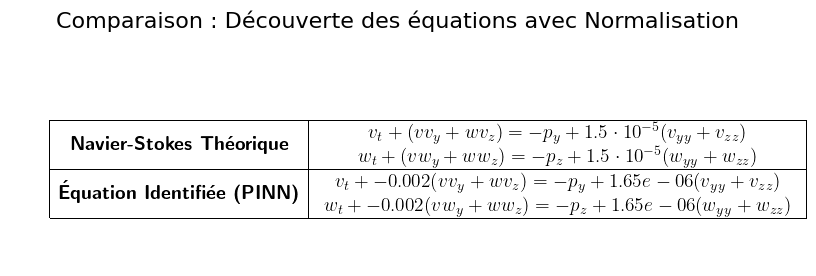

In [32]:
# Install LaTeX components required for Matplotlib's usetex
!apt-get install texlive-latex-extra -qq > /dev/null
!apt-get install dvipng cm-super -qq > /dev/null

import matplotlib.pyplot as plt

# --- 1. EXTRACTION DES NOUVEAUX PARAMÈTRES ---
l1_final = model.lambda_1.item()

# On reconstitue la vraie viscosité à partir du paramètre "mis à l'échelle"
l2_final = model.lambda_2_scaled.item() * 1e-5

print(f"Valeur de lambda_1 identifiée : {l1_final:.4f}")
print(f"Valeur de la viscosité identifiée : {l2_final:.7e} m²/s")

# --- 2. CRÉATION DU TABLEAU DE COMPARAISON ---
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')

# Construction du texte en LaTeX pour Matplotlib
s = r'$\begin{tabular}{|c|c|}'
s += r' \hline'
s += r' \textbf{Navier-Stokes Théorique} & $\begin{array}{c}'
s += r' v_t + (v v_y + w v_z) = -p_y + 1.5 \cdot 10^{-5} (v_{yy} + v_{zz})' + r'\\'
s += r' w_t + (v w_y + w w_z) = -p_z + 1.5 \cdot 10^{-5} (w_{yy} + w_{zz})'
s += r' \end{array}$ \\ '
s += r' \hline'
s += r' \textbf{Équation Identifiée (PINN)} & $\begin{array}{c}'
# On utilise le formatage scientifique %.2e pour bien afficher les 10^-5
s += r' v_t + %.3f (v v_y + w v_z) = -p_y + %.2e (v_{yy} + v_{zz})' % (l1_final, l2_final) + r'\\'
s += r' w_t + %.3f (v w_y + w w_z) = -p_z + %.2e (w_{yy} + w_{zz})' % (l1_final, l2_final)
s += r' \end{array}$ \\ '
s += r' \hline'
s += r' \end{tabular}$'

ax.text(0.05, 0.4, s, fontsize=14, usetex=True)
plt.title("Comparaison : Découverte des équations avec Normalisation", fontsize=16)
plt.show()

In [33]:
import numpy as np
import torch

print("--- ÉVALUATION SUR LES DONNÉES DE TEST (MODÈLE NORMALISÉ) ---")

# On s'assure de ne tester que sur des données que le modèle n'a JAMAIS vues
tous_les_indices = np.arange(N_total)
indices_test_complets = np.setdiff1d(tous_les_indices, indices_aleatoires)

# On prend un gros échantillon de 50 000 points au hasard
indices_test = np.random.choice(indices_test_complets, 50000, replace=False)

# Chargement sur le GPU
t_test = inputs_complets[indices_test, 0:1].clone().to(device).requires_grad_(True)
y_test = inputs_complets[indices_test, 1:2].clone().to(device).requires_grad_(True)
z_test = inputs_complets[indices_test, 2:3].clone().to(device).requires_grad_(True)

# Les vraies valeurs de votre simulation CFD
v_true = outputs_complets[indices_test, 0:1].numpy()
w_true = outputs_complets[indices_test, 1:2].numpy()

# Prédiction avec notre nouveau modèle
model.eval()
v_pred_test, w_pred_test, _, _, _ = model.net_NS(t_test, y_test, z_test)

# Détachement pour le calcul Numpy
v_pred_test = v_pred_test.detach().cpu().numpy()
w_pred_test = w_pred_test.detach().cpu().numpy()

# Calcul de l'erreur L2 relative
error_v = np.linalg.norm(v_true - v_pred_test, 2) / np.linalg.norm(v_true, 2)
error_w = np.linalg.norm(w_true - w_pred_test, 2) / np.linalg.norm(w_true, 2)

print(f"Erreur L2 relative sur v : {error_v * 100:.2f} %")
print(f"Erreur L2 relative sur w : {error_w * 100:.2f} %")

--- ÉVALUATION SUR LES DONNÉES DE TEST (MODÈLE NORMALISÉ) ---
Erreur L2 relative sur v : 313.02 %
Erreur L2 relative sur w : 8.01 %


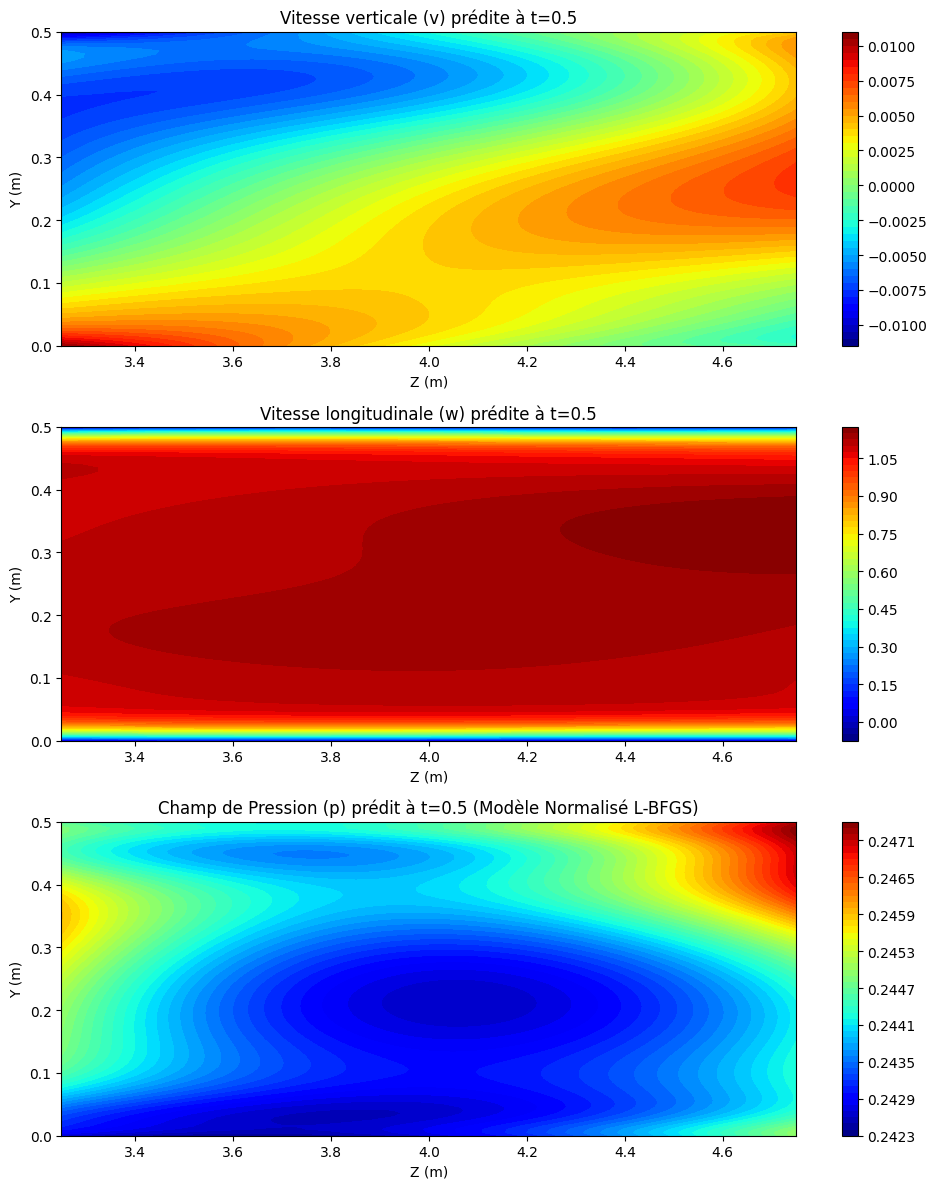

In [34]:
import matplotlib.pyplot as plt

# Création d'une grille fine pour de belles images
y_grid = np.linspace(0.0, 0.5, 100)
z_grid = np.linspace(3.25, 4.75, 200)
Y_mesh, Z_mesh = np.meshgrid(y_grid, z_grid)

# On se place à t = 0.5 (vous pouvez changer cette valeur)
t_fixe = 0.5
T_flat = np.ones_like(Y_mesh.flatten()) * t_fixe
Y_flat = Y_mesh.flatten()
Z_flat = Z_mesh.flatten()

# Conversion pour le modèle
t_pred = torch.tensor(T_flat[:, None], dtype=torch.float32, requires_grad=True).to(device)
y_pred = torch.tensor(Y_flat[:, None], dtype=torch.float32, requires_grad=True).to(device)
z_pred = torch.tensor(Z_flat[:, None], dtype=torch.float32, requires_grad=True).to(device)

# Inférence
model.eval()
v_pred, w_pred, p_pred, _, _ = model.net_NS(t_pred, y_pred, z_pred)

V_plot = v_pred.detach().cpu().numpy().reshape(Y_mesh.shape)
W_plot = w_pred.detach().cpu().numpy().reshape(Y_mesh.shape)
P_plot = p_pred.detach().cpu().numpy().reshape(Y_mesh.shape)

# Tracé des 3 graphiques
fig, axs = plt.subplots(3, 1, figsize=(10, 12))

c0 = axs[0].contourf(Z_mesh, Y_mesh, V_plot, 50, cmap='jet')
axs[0].set_title(f'Vitesse verticale (v) prédite à t={t_fixe}')
axs[0].set_xlabel('Z (m)')
axs[0].set_ylabel('Y (m)')
fig.colorbar(c0, ax=axs[0])

c1 = axs[1].contourf(Z_mesh, Y_mesh, W_plot, 50, cmap='jet')
axs[1].set_title(f'Vitesse longitudinale (w) prédite à t={t_fixe}')
axs[1].set_xlabel('Z (m)')
axs[1].set_ylabel('Y (m)')
fig.colorbar(c1, ax=axs[1])

c2 = axs[2].contourf(Z_mesh, Y_mesh, P_plot, 50, cmap='jet')
axs[2].set_title(f'Champ de Pression (p) prédit à t={t_fixe} (Modèle Normalisé L-BFGS)')
axs[2].set_xlabel('Z (m)')
axs[2].set_ylabel('Y (m)')
fig.colorbar(c2, ax=axs[2])

plt.tight_layout()
plt.show()

# Essai en reprenant mon code MLP_discovery

## Chargement des données

In [ ]:
# 1. On crée un dossier pour accueillir les fichiers extraits
!mkdir -p /content/donnees_projet

# 2. On extrait l'archive dans ce dossier (remplacez le chemin si le fichier est sur votre Drive)
!7z x /content/ProjetIA.7z -o/content/donnees_projet/

In [55]:
import pandas as pd
import numpy as np
import torch
import os
import glob

# -----------------------------------------------------------------------------
# Paramètres
# -----------------------------------------------------------------------------
DOSSIER   = '/content/donnees_projet/'
SAVE_PATH = '/content/dataset_pinn.pt'

# Chaque fichier Data_i.txt correspond à un instant t_i = i * DT
# Si vos données sont stationnaires (pas de temps physique), mettez DT=0
# et le temps sera ignoré dans le PINN (entrées = x,y,z uniquement).
DT = 0.01   # pas de temps [s] — à ajuster selon votre simulation

# Noms de colonnes tels qu'ils apparaissent après skiprows=5
COL_X  = 'X [ m ]'
COL_Y  = 'Y [ m ]'
COL_Z  = 'Z [ m ]'
COL_U  = 'Velocity u [ m s^-1 ]'
COL_V  = 'Velocity v [ m s^-1 ]'
COL_W  = 'Velocity w [ m s^-1 ]'
ALL_COLS = [COL_X, COL_Y, COL_Z, COL_U, COL_V, COL_W]

# -----------------------------------------------------------------------------
# Lecture des fichiers
# -----------------------------------------------------------------------------
print("1. Lecture des fichiers en cours...")

liste_fichiers = sorted(
    glob.glob(os.path.join(DOSSIER, 'Data_*.txt')),
    key=lambda p: int(os.path.basename(p).replace('Data_', '').replace('.txt', ''))
)
print(f"   {len(liste_fichiers)} fichiers trouvés.")

toutes_les_donnees = []
erreurs = []

for i, chemin in enumerate(liste_fichiers):
    try:
        df = pd.read_csv(chemin, skiprows=5, header=None, names=ALL_COLS)

        # Conversion numérique (gère les éventuels artefacts texte)
        for col in ALL_COLS:
            df[col] = pd.to_numeric(df[col], errors='coerce')

        # Ajout du temps physique
        df['t'] = i * DT

        toutes_les_donnees.append(df)

    except Exception as e:
        erreurs.append((chemin, str(e)))
        print(f"   ⚠ Erreur sur {os.path.basename(chemin)} : {e}")

if erreurs:
    print(f"\n   {len(erreurs)} fichier(s) ignoré(s) sur {len(liste_fichiers)}.")

df_complet = pd.concat(toutes_les_donnees, ignore_index=True)
print(f"   {len(df_complet):,} lignes brutes chargées.")

# -----------------------------------------------------------------------------
# Nettoyage
# -----------------------------------------------------------------------------
print("\n2. Nettoyage des données...")
avant = len(df_complet)
df_complet.dropna(subset=ALL_COLS, inplace=True)
apres = len(df_complet)
print(f"   {avant - apres:,} lignes supprimées (NaN) → {apres:,} lignes conservées.")

# Vérification rapide du domaine
print(f"\n   Domaine détecté :")
print(f"   X ∈ [{df_complet[COL_X].min():.4f}, {df_complet[COL_X].max():.4f}] m")
print(f"   Y ∈ [{df_complet[COL_Y].min():.4f}, {df_complet[COL_Y].max():.4f}] m")
print(f"   Z ∈ [{df_complet[COL_Z].min():.4f}, {df_complet[COL_Z].max():.4f}] m")
print(f"   u ∈ [{df_complet[COL_U].min():.4f}, {df_complet[COL_U].max():.4f}] m/s")
print(f"   v ∈ [{df_complet[COL_V].min():.4f}, {df_complet[COL_V].max():.4f}] m/s")
print(f"   w ∈ [{df_complet[COL_W].min():.4f}, {df_complet[COL_W].max():.4f}] m/s")
print(f"   t ∈ [{df_complet['t'].min():.4f}, {df_complet['t'].max():.4f}] s")

# -----------------------------------------------------------------------------
# Conversion en tenseurs PyTorch
# -----------------------------------------------------------------------------
print("\n3. Conversion en tenseurs PyTorch...")

# Entrées spatiales 3D (le PINN stationnaire n'utilise que x,y,z)
x_np = df_complet[COL_X].values[:, None].astype(np.float32)
y_np = df_complet[COL_Y].values[:, None].astype(np.float32)
z_np = df_complet[COL_Z].values[:, None].astype(np.float32)
u_np = df_complet[COL_U].values[:, None].astype(np.float32)
v_np = df_complet[COL_V].values[:, None].astype(np.float32)
w_np = df_complet[COL_W].values[:, None].astype(np.float32)
t_np = df_complet['t'].values[:, None].astype(np.float32)

# Sauvegarde complète
torch.save({
    'x': torch.from_numpy(x_np),
    'y': torch.from_numpy(y_np),
    'z': torch.from_numpy(z_np),
    'u': torch.from_numpy(u_np),
    'v': torch.from_numpy(v_np),
    'w': torch.from_numpy(w_np),
    't': torch.from_numpy(t_np),
    'z_out': float(z_np.max()),
    'meta': {
        'n_fichiers': len(liste_fichiers),
        'n_points':   apres,
        'DT':         DT,
    }
}, SAVE_PATH)

print(f"\n4. Sauvegardé dans {SAVE_PATH}")
print(f"   {apres:,} points  |  x,y,z,u,v,w,t")
print(f"\n   Pour recharger dans le MAIN :")
print(f"   data = torch.load('{SAVE_PATH}')")
print(f"   x_data = data['x'].numpy()  # etc.")

1. Lecture des fichiers en cours...
   200 fichiers trouvés.
   1,000,200 lignes brutes chargées.

2. Nettoyage des données...
   200 lignes supprimées (NaN) → 1,000,000 lignes conservées.

   Domaine détecté :
   X ∈ [0.2500, 0.2500] m
   Y ∈ [0.0000, 0.5000] m
   Z ∈ [3.2500, 4.7500] m
   u ∈ [-0.0000, 0.0001] m/s
   v ∈ [-0.0020, 0.0020] m/s
   w ∈ [0.2657, 1.1502] m/s
   t ∈ [0.0000, 1.9900] s

3. Conversion en tenseurs PyTorch...

4. Sauvegardé dans /content/dataset_pinn.pt
   1,000,000 points  |  x,y,z,u,v,w,t

   Pour recharger dans le MAIN :
   data = torch.load('/content/dataset_pinn.pt')
   x_data = data['x'].numpy()  # etc.


In [56]:
# =============================================================================
# MAIN —
# =============================================================================

np.random.seed(1234)
torch.manual_seed(1234)

# ------------------------------------------------------------------
# 1. CHARGEMENT DEPUIS LE FICHIER .pt (créé par chargement_donnees_pinn.py)
# ------------------------------------------------------------------
SAVE_PATH = '/content/dataset_pinn.pt'
print(f"Chargement des données depuis : {SAVE_PATH}")

data   = torch.load(SAVE_PATH)
x_data = data['x'].numpy()   # (N,1)
y_data = data['y'].numpy()
z_data = data['z'].numpy()
u_data = data['u'].numpy()
v_data = data['v'].numpy()
w_data = data['w'].numpy()
z_out  = data['z_out']        # float : valeur max de Z

print(f"Points chargés : {x_data.shape[0]:,}")
print(f"z_out = {z_out:.4f} m")

# --- Le reste du MAIN est identique à partir d'ici ---
# (N_train, N_colloc, layers, train_tensors, bc_tensors, train(), visualize_results())

Chargement des données depuis : /content/dataset_pinn.pt
Points chargés : 1,000,000
z_out = 4.7500 m


##  1er essai

In [47]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.autograd as autograd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import time
import os
import py7zr
import io

# -----------------------------
# Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# =============================================================================
# LECTURE DES DONNÉES (.7z avec format [Name]/[Data])
# =============================================================================

def parse_data_block(text_content):
    """
    Parse un fichier texte au format :
        [Name]
        Velocity
        [Data]
        X [ m ], Y [ m ], Z [ m ], Velocity u [ m s^-1 ], ...
        2.5e-01, 0.0e+00, ...
    Retourne un dict {nom_colonne: array}.
    """
    lines = text_content.splitlines()

    # Trouver la section [Data]
    data_start = None
    header_line = None
    for i, line in enumerate(lines):
        stripped = line.strip()
        if stripped == "[Data]":
            data_start = i + 1  # la ligne suivante est l'en-tête
            break

    if data_start is None:
        raise ValueError("Section [Data] introuvable dans le fichier.")

    header_line = lines[data_start].strip()
    # Extraire les noms de colonnes (avant le crochet d'unité ou tout simplement
    # en prenant le premier mot significatif de chaque champ)
    raw_cols = [c.strip() for c in header_line.split(",")]
    # Noms courts : "X [ m ]" -> "X", "Velocity u [ m s^-1 ]" -> "Velocity_u"
    col_names = []
    for col in raw_cols:
        name = col.split("[")[0].strip()
        name = name.replace(" ", "_")
        col_names.append(name)

    # Lire les données numériques
    numeric_lines = []
    for line in lines[data_start + 1:]:
        line = line.strip()
        if line == "" or line.startswith("["):
            continue
        numeric_lines.append(line)

    if len(numeric_lines) == 0:
        raise ValueError("Aucune donnée numérique trouvée après [Data].")

    data_array = np.loadtxt(io.StringIO("\n".join(numeric_lines)), delimiter=",")

    result = {}
    for j, name in enumerate(col_names):
        result[name] = data_array[:, j]

    return result

def load_7z_data(path_7z):
    """
    Ouvre une archive .7z, lit tous les fichiers .txt à l'intérieur
    et concatène les données de tous les fichiers.
    Retourne arrays (x, y, z, u, v, w).
    Compatible avec les versions récentes de py7zr.
    """
    all_x, all_y, all_z = [], [], []
    all_u, all_v, all_w = [], [], []

    with py7zr.SevenZipFile(path_7z, mode='r') as archive:
        all_names = archive.getnames()
        txt_names = [n for n in all_names
                     if n.endswith(".txt") or n.endswith(".dat") or n.endswith(".csv")]
        print(f"Fichiers dans l'archive : {len(all_names)} total, {len(txt_names)} fichiers texte")

        # read() accepte une liste de noms et retourne un dict {nom: BytesIO}
        file_map = archive.read(txt_names)

    for fname, bio in file_map.items():
        print(f"  -> Lecture de : {fname}")
        text = bio.read().decode("utf-8", errors="replace")
        parsed = parse_data_block(text)

        x_col = _find_col(parsed, ["X"])
        y_col = _find_col(parsed, ["Y"])
        z_col = _find_col(parsed, ["Z"])
        u_col = _find_col(parsed, ["Velocity_u", "u"])
        v_col = _find_col(parsed, ["Velocity_v", "v"])
        w_col = _find_col(parsed, ["Velocity_w", "w"])

        all_x.append(parsed[x_col])
        all_y.append(parsed[y_col])
        all_z.append(parsed[z_col])
        all_u.append(parsed[u_col])
        all_v.append(parsed[v_col])
        all_w.append(parsed[w_col])

    x = np.concatenate(all_x)[:, None]
    y = np.concatenate(all_y)[:, None]
    z = np.concatenate(all_z)[:, None]
    u = np.concatenate(all_u)[:, None]
    v = np.concatenate(all_v)[:, None]
    w = np.concatenate(all_w)[:, None]

    print(f"\nTotal points chargés : {x.shape[0]:,}")
    return x, y, z, u, v, w


def _find_col(d, candidates):
    """Retourne la première clé trouvée dans le dict parmi les candidats."""
    for c in candidates:
        if c in d:
            return c
    raise KeyError(f"Aucune colonne parmi {candidates} trouvée. Colonnes disponibles : {list(d.keys())}")


# =============================================================================
# CONDITIONS AUX LIMITES
# =============================================================================
# Géométrie : conduite parallélépipédique 0.5 x 0.5 m (section XY)
# Axe principal : Z,  Z_in=0, Z_out=Z_sortie
# Parois : X=0, X=0.5, Y=0, Y=0.5
# Entrée  (Z=0)    : vitesse w_mean = 1 m/s (profil de Poiseuille ou uniforme)
# Sortie  (Z=Z_out): pression relative p = 0
# Parois           : u=v=w=0 (no-slip)

LX = 0.5          # largeur conduite [m]
LY = 0.5          # hauteur conduite [m]
U_MEAN = 1.0      # vitesse débitante en entrée [m/s]
P_OUT  = 0.0      # pression relative en sortie [Pa]
TOLERANCE_WALL  = 1e-4   # tolérance pour détecter un point sur la paroi
TOLERANCE_INLET = 1e-4   # tolérance pour détecter entrée/sortie


def generate_bc_points(z_out, n_wall=500, n_inlet=300, n_outlet=300):
    """
    Génère des points de conditions aux limites pour la conduite.

    Retourne plusieurs tenseurs :
      - wall   : (x,y,z) sur les 4 parois,             cible u=v=w=0
      - inlet  : (x,y,z=0) sur la section d'entrée,    cible w=w_inlet(x,y)
      - outlet : (x,y,z=z_out) sur la section de sortie, cible p=0
    """
    # --- Parois (no-slip) : X=0, X=0.5, Y=0, Y=0.5 ---
    n_each = n_wall // 4

    # X = 0
    y_w1 = np.random.uniform(0, LY, n_each)
    z_w1 = np.random.uniform(0, z_out, n_each)
    x_w1 = np.zeros(n_each)

    # X = LX
    y_w2 = np.random.uniform(0, LY, n_each)
    z_w2 = np.random.uniform(0, z_out, n_each)
    x_w2 = np.full(n_each, LX)

    # Y = 0
    x_w3 = np.random.uniform(0, LX, n_each)
    z_w3 = np.random.uniform(0, z_out, n_each)
    y_w3 = np.zeros(n_each)

    # Y = LY
    x_w4 = np.random.uniform(0, LX, n_each)
    z_w4 = np.random.uniform(0, z_out, n_each)
    y_w4 = np.full(n_each, LY)

    x_wall = np.concatenate([x_w1, x_w2, x_w3, x_w4])
    y_wall = np.concatenate([y_w1, y_w2, y_w3, y_w4])
    z_wall = np.concatenate([z_w1, z_w2, z_w3, z_w4])

    # --- Entrée Z = 0 ---
    x_in = np.random.uniform(0, LX, n_inlet)
    y_in = np.random.uniform(0, LY, n_inlet)
    z_in = np.zeros(n_inlet)
    # Profil de Poiseuille 3D pour conduite carrée (approx. produit de sin)
    # w_inlet(x,y) = w0 * sin(pi*x/LX) * sin(pi*y/LY)
    # On calibre w0 pour que la moyenne vaille U_MEAN :
    # <sin(pi*x/LX)*sin(pi*y/LY)> = (2/pi)^2  => w0 = U_MEAN * (pi/2)^2
    w0 = U_MEAN * (np.pi / 2) ** 2
    w_in = w0 * np.sin(np.pi * x_in / LX) * np.sin(np.pi * y_in / LY)

    # --- Sortie Z = z_out ---
    x_out = np.random.uniform(0, LX, n_outlet)
    y_out = np.random.uniform(0, LY, n_outlet)
    z_out_pts = np.full(n_outlet, z_out)

    bc = {
        "wall": (x_wall[:, None], y_wall[:, None], z_wall[:, None]),
        "inlet": (x_in[:, None], y_in[:, None], z_in[:, None], w_in[:, None]),
        "outlet": (x_out[:, None], y_out[:, None], z_out_pts[:, None]),
    }
    return bc


def to_tensor(arr, grad=False):
    return torch.tensor(arr, dtype=torch.float32, requires_grad=grad).to(device)


# =============================================================================
# PHYSICS-INFORMED NEURAL NETWORK  (3D, stationnaire)
# =============================================================================

class PhysicsInformedNN(nn.Module):
    """
    Entrées  : (x, y, z)  — coordonnées spatiales 3D
    Sorties  : (u, v, w, p)  — composantes de vitesse + pression

    On n'utilise plus la fonction de courant psi (valable uniquement en 2D).
    Le réseau prédit directement (u, v, w, p).

    Équations de Navier-Stokes 3D stationnaires incompressibles :
      ∂u/∂x + ∂v/∂y + ∂w/∂z = 0                          (continuité)
      u ∂u/∂x + v ∂u/∂y + w ∂u/∂z = -∂p/∂x + ν ∇²u      (NS-x)
      u ∂v/∂x + v ∂v/∂y + w ∂v/∂z = -∂p/∂y + ν ∇²v      (NS-y)
      u ∂w/∂x + v ∂w/∂y + w ∂w/∂z = -∂p/∂z + ν ∇²w      (NS-z)

    λ1 = 1 (terme convectif, doit être identifié ≈ 1)
    λ2 = ν (viscosité cinématique, à identifier)
    """

    def __init__(self, layers):
        super().__init__()
        self.network = self._build_network(layers)
        self._initialize_weights()

        # Paramètres à identifier
        self.lambda_1 = nn.Parameter(torch.tensor([0.0], dtype=torch.float32))
        self.lambda_2 = nn.Parameter(torch.tensor([0.0], dtype=torch.float32))

    def _build_network(self, layers):
        modules = []
        for i in range(len(layers) - 2):
            modules.append(nn.Linear(layers[i], layers[i + 1]))
            modules.append(nn.Tanh())
        modules.append(nn.Linear(layers[-2], layers[-1]))
        return nn.Sequential(*modules)

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x, y, z):
        inputs = torch.cat([x, y, z], dim=1)
        output = self.network(inputs)   # (N, 4)
        u = output[:, 0:1]
        v = output[:, 1:2]
        w = output[:, 2:3]
        p = output[:, 3:4]
        return u, v, w, p


# =============================================================================
# RÉSIDUS PDE  (Navier-Stokes 3D stationnaire)
# =============================================================================

def grad(f, var):
    return autograd.grad(f.sum(), var, create_graph=True)[0]


def compute_pde_residuals(model, x, y, z):
    u, v, w, p = model(x, y, z)

    l1 = model.lambda_1
    l2 = model.lambda_2

    # --- Dérivées premières ---
    u_x = grad(u, x);  u_y = grad(u, y);  u_z = grad(u, z)
    v_x = grad(v, x);  v_y = grad(v, y);  v_z = grad(v, z)
    w_x = grad(w, x);  w_y = grad(w, y);  w_z = grad(w, z)
    p_x = grad(p, x);  p_y = grad(p, y);  p_z = grad(p, z)

    # --- Dérivées secondes ---
    u_xx = grad(u_x, x);  u_yy = grad(u_y, y);  u_zz = grad(u_z, z)
    v_xx = grad(v_x, x);  v_yy = grad(v_y, y);  v_zz = grad(v_z, z)
    w_xx = grad(w_x, x);  w_yy = grad(w_y, y);  w_zz = grad(w_z, z)

    # --- Résidus ---
    # Continuité
    f_cont = u_x + v_y + w_z

    # Navier-Stokes
    f_u = l1 * (u * u_x + v * u_y + w * u_z) + p_x - l2 * (u_xx + u_yy + u_zz)
    f_v = l1 * (u * v_x + v * v_y + w * v_z) + p_y - l2 * (v_xx + v_yy + v_zz)
    f_w = l1 * (u * w_x + v * w_y + w * w_z) + p_z - l2 * (w_xx + w_yy + w_zz)

    return f_cont, f_u, f_v, f_w, u, v, w, p


# =============================================================================
# LOSS TOTALE
# =============================================================================

def compute_loss(model,
                 # Points de collocation (intérieur)
                 xc, yc, zc,
                 # Points de données mesurées
                 xd, yd, zd, ud, vd, wd,
                 # Conditions aux limites
                 x_wall, y_wall, z_wall,
                 x_in,   y_in,   z_in,   w_in_target,
                 x_out,  y_out,  z_out,
                 # Pondérations
                 w_data=1.0, w_pde=1.0, w_bc=10.0):
    """
    Loss = w_data * MSE(données)
         + w_pde  * MSE(résidus NS)
         + w_bc   * MSE(conditions aux limites)
    """

    # ---- 1. Résidus PDE sur points de collocation ----
    f_cont, f_u, f_v, f_w, _, _, _, _ = compute_pde_residuals(model, xc, yc, zc)
    loss_pde = (torch.mean(f_cont**2) + torch.mean(f_u**2)
                + torch.mean(f_v**2) + torch.mean(f_w**2))

    # ---- 2. Données mesurées ----
    u_pred, v_pred, w_pred, _ = model(xd, yd, zd)
    loss_data = (torch.mean((ud - u_pred)**2)
                 + torch.mean((vd - v_pred)**2)
                 + torch.mean((wd - w_pred)**2))

    # ---- 3. Conditions aux limites ----
    # Parois : u=v=w=0
    u_w, v_w, w_w, _ = model(x_wall, y_wall, z_wall)
    loss_wall = torch.mean(u_w**2) + torch.mean(v_w**2) + torch.mean(w_w**2)

    # Entrée : w = w_inlet(x,y), u=v=0
    u_i, v_i, w_i, _ = model(x_in, y_in, z_in)
    loss_inlet = (torch.mean((w_i - w_in_target)**2)
                  + torch.mean(u_i**2) + torch.mean(v_i**2))

    # Sortie : p = 0
    _, _, _, p_o = model(x_out, y_out, z_out)
    loss_outlet = torch.mean(p_o**2)

    loss_bc = loss_wall + loss_inlet + loss_outlet

    total = w_data * loss_data + w_pde * loss_pde + w_bc * loss_bc
    return total, loss_data, loss_pde, loss_bc


# =============================================================================
# ENTRAÎNEMENT
# =============================================================================

def train(model, train_tensors, bc_tensors,
          adam_iters=2000, lbfgs_maxiter=50000):

    model.to(device)

    def unpack():
        return (
            train_tensors["xc"], train_tensors["yc"], train_tensors["zc"],
            train_tensors["xd"], train_tensors["yd"], train_tensors["zd"],
            train_tensors["ud"], train_tensors["vd"], train_tensors["wd"],
            bc_tensors["x_wall"], bc_tensors["y_wall"], bc_tensors["z_wall"],
            bc_tensors["x_in"],   bc_tensors["y_in"],   bc_tensors["z_in"],
            bc_tensors["w_in"],
            bc_tensors["x_out"],  bc_tensors["y_out"],  bc_tensors["z_out"],
        )

    # ---- Phase 1 : Adam ----
    print("\n=== Phase 1 : Adam ===")
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    t0 = time.time()

    for it in range(adam_iters):
        optimizer.zero_grad()
        total, ld, lp, lb = compute_loss(model, *unpack())
        total.backward()
        optimizer.step()

        if it % 100 == 0:
            print(f"  It {it:5d} | Loss {total.item():.3e} | "
                  f"data {ld.item():.3e} | pde {lp.item():.3e} | bc {lb.item():.3e} | "
                  f"λ1={model.lambda_1.item():.4f}  λ2={model.lambda_2.item():.6f} | "
                  f"{time.time()-t0:.1f}s")
            t0 = time.time()

    # ---- Phase 2 : L-BFGS ----
    print("\n=== Phase 2 : L-BFGS ===")
    optimizer_lb = optim.LBFGS(
        model.parameters(),
        max_iter=lbfgs_maxiter,
        tolerance_grad=1e-9,
        tolerance_change=1e-9,
        history_size=50,
        line_search_fn="strong_wolfe",
    )

    def closure():
        optimizer_lb.zero_grad()
        total, ld, lp, lb = compute_loss(model, *unpack())
        total.backward()
        print(f"  Loss {total.item():.3e} | data {ld.item():.3e} | "
              f"pde {lp.item():.3e} | bc {lb.item():.3e} | "
              f"λ1={model.lambda_1.item():.4f}  λ2={model.lambda_2.item():.6f}")
        return total

    optimizer_lb.step(closure)
    print("\n=== Entraînement terminé ===")


# =============================================================================
# VISUALISATION
# =============================================================================

def visualize_results(model, x, y, z, z_out, slice_z=None):
    """
    Trace des coupes XY à z=slice_z (ou z_out/2 par défaut).
    Affiche u, v, w, p prédits.
    """
    if slice_z is None:
        slice_z = z_out / 2.0

    nn = 80
    xi = np.linspace(0, LX, nn)
    yi = np.linspace(0, LY, nn)
    Xi, Yi = np.meshgrid(xi, yi)
    Zi = np.full_like(Xi, slice_z)

    X_flat = to_tensor(Xi.flatten()[:, None], grad=True)
    Y_flat = to_tensor(Yi.flatten()[:, None], grad=True)
    Z_flat = to_tensor(Zi.flatten()[:, None], grad=True)

    model.eval()
    with torch.no_grad():
        u_p, v_p, w_p, p_p = model(X_flat, Y_flat, Z_flat)

    def to_np(t): return t.cpu().numpy().reshape(nn, nn)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    titles = ["u [m/s]", "v [m/s]", "w [m/s]", "p [Pa]"]
    fields = [to_np(u_p), to_np(v_p), to_np(w_p), to_np(p_p)]

    for ax, field, title in zip(axes.flat, fields, titles):
        im = ax.contourf(Xi, Yi, field, levels=50, cmap="RdBu_r")
        plt.colorbar(im, ax=ax)
        ax.set_title(f"{title}  (coupe z={slice_z:.2f} m)")
        ax.set_xlabel("x [m]")
        ax.set_ylabel("y [m]")
        ax.set_aspect("equal")

    plt.tight_layout()
    plt.savefig("resultats_conduite_3d.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure sauvegardée : resultats_conduite_3d.png")

    # Profil axial de w en centre de section (x=0.25, y=0.25)
    zi_axis = np.linspace(0, z_out, 200)
    xc_ax = np.full_like(zi_axis, 0.25)
    yc_ax = np.full_like(zi_axis, 0.25)

    Xax = to_tensor(xc_ax[:, None], grad=True)
    Yax = to_tensor(yc_ax[:, None], grad=True)
    Zax = to_tensor(zi_axis[:, None], grad=True)

    with torch.no_grad():
        _, _, w_ax, p_ax = model(Xax, Yax, Zax)

    fig2, ax2 = plt.subplots(1, 2, figsize=(12, 4))
    ax2[0].plot(zi_axis, w_ax.cpu().numpy(), "b-")
    ax2[0].set_xlabel("z [m]"); ax2[0].set_ylabel("w [m/s]")
    ax2[0].set_title("Profil axial de w (x=y=0.25 m)")
    ax2[0].grid(True)

    ax2[1].plot(zi_axis, p_ax.cpu().numpy(), "r-")
    ax2[1].set_xlabel("z [m]"); ax2[1].set_ylabel("p [Pa]")
    ax2[1].set_title("Profil de pression axial (x=y=0.25 m)")
    ax2[1].grid(True)

    plt.tight_layout()
    plt.savefig("profils_axiaux.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure sauvegardée : profils_axiaux.png")


Using device: cuda


In [57]:

# =============================================================================
# MAIN
# =============================================================================

if __name__ == "__main__":
    np.random.seed(1234)
    torch.manual_seed(1234)
    # Déterminer z_out à partir des données
    z_out = float(z_data.max())
    print(f"Domaine détecté : X∈[{x_data.min():.3f}, {x_data.max():.3f}]  "
          f"Y∈[{y_data.min():.3f}, {y_data.max():.3f}]  "
          f"Z∈[0, {z_out:.3f}]")
    print(f"Nombre de points de données : {x_data.shape[0]}")

    # ------------------------------------------------------------------
    # 2. NORMALISATION (facultative mais recommandée)
    # ------------------------------------------------------------------
    # On travaille en coordonnées physiques (pas de normalisation ici).
    # Si le domaine est très allongé, envisager de normaliser Z.

    # ------------------------------------------------------------------
    # 3. ÉCHANTILLONNAGE POUR L'ENTRAÎNEMENT
    # ------------------------------------------------------------------
    N_train = 2000          # points de données mesurées
    N_colloc = 5000         # points de collocation (PDE)
    layers = [3, 64, 64, 64, 64, 64, 64, 4]   # entrée 3D, sortie (u,v,w,p)

    total = x_data.shape[0]
    idx = np.random.choice(total, min(N_train, total), replace=False)

    # Tenseurs de données
    train_tensors = {
        "xd": to_tensor(x_data[idx], grad=True),
        "yd": to_tensor(y_data[idx], grad=True),
        "zd": to_tensor(z_data[idx], grad=True),
        "ud": to_tensor(u_data[idx]),
        "vd": to_tensor(v_data[idx]),
        "wd": to_tensor(w_data[idx]),
    }

    # Points de collocation (intérieur du domaine)
    xc = np.random.uniform(0,    LX,    N_colloc)[:, None]
    yc = np.random.uniform(0,    LY,    N_colloc)[:, None]
    zc = np.random.uniform(0,    z_out, N_colloc)[:, None]
    train_tensors["xc"] = to_tensor(xc, grad=True)
    train_tensors["yc"] = to_tensor(yc, grad=True)
    train_tensors["zc"] = to_tensor(zc, grad=True)

    # ------------------------------------------------------------------
    # 4. CONDITIONS AUX LIMITES
    # ------------------------------------------------------------------
    bc = generate_bc_points(z_out, n_wall=600, n_inlet=300, n_outlet=300)

    bc_tensors = {
        "x_wall": to_tensor(bc["wall"][0], grad=True),
        "y_wall": to_tensor(bc["wall"][1], grad=True),
        "z_wall": to_tensor(bc["wall"][2], grad=True),
        "x_in":   to_tensor(bc["inlet"][0], grad=True),
        "y_in":   to_tensor(bc["inlet"][1], grad=True),
        "z_in":   to_tensor(bc["inlet"][2], grad=True),
        "w_in":   to_tensor(bc["inlet"][3]),          # pas de grad sur la cible
        "x_out":  to_tensor(bc["outlet"][0], grad=True),
        "y_out":  to_tensor(bc["outlet"][1], grad=True),
        "z_out":  to_tensor(bc["outlet"][2], grad=True),
    }

    # ------------------------------------------------------------------
    # 5. CRÉATION ET ENTRAÎNEMENT DU MODÈLE
    # ------------------------------------------------------------------
    model = PhysicsInformedNN(layers)
    print(f"\nArchitecture : {layers}")
    print(f"Nombre de paramètres : "
          f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    train(model, train_tensors, bc_tensors,
          adam_iters=2000, lbfgs_maxiter=10000)

    # ------------------------------------------------------------------
    # 6. RÉSULTATS
    # ------------------------------------------------------------------
    lambda_1 = model.lambda_1.item()
    lambda_2 = model.lambda_2.item()
    print(f"\n{'='*60}")
    print("PARAMÈTRES IDENTIFIÉS")
    print(f"{'='*60}")
    print(f"  λ1 (terme convectif)  = {lambda_1:.6f}  (valeur attendue : 1.0)")
    print(f"  λ2 (viscosité kin. ν) = {lambda_2:.6f}  [m²/s]")
    print(f"  (eau à 20°C : ν ≈ 1e-6 ;  air à 20°C : ν ≈ 1.5e-5)")

    # ------------------------------------------------------------------
    # 7. VISUALISATION
    # ------------------------------------------------------------------
    visualize_results(model, x_data, y_data, z_data, z_out,
                      slice_z=z_out / 2.0)

    # ------------------------------------------------------------------
    # 8. SAUVEGARDE DU MODÈLE
    # ------------------------------------------------------------------
    torch.save(model.state_dict(), "pinn_conduite_3d.pt")
    print("\nModèle sauvegardé : pinn_conduite_3d.pt")
    print("Pour recharger : model.load_state_dict(torch.load('pinn_conduite_3d.pt'))")

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
  Loss 1.509e-02 | data 8.323e-03 | pde 1.738e-03 | bc 5.032e-04 | λ1=0.0013  λ2=0.000004
  Loss 1.505e-02 | data 8.310e-03 | pde 1.731e-03 | bc 5.012e-04 | λ1=0.0012  λ2=0.000002
  Loss 1.501e-02 | data 8.239e-03 | pde 1.725e-03 | bc 5.047e-04 | λ1=0.0009  λ2=-0.000001
  Loss 1.498e-02 | data 8.244e-03 | pde 1.695e-03 | bc 5.043e-04 | λ1=0.0009  λ2=-0.000002
  Loss 1.496e-02 | data 8.184e-03 | pde 1.696e-03 | bc 5.080e-04 | λ1=0.0008  λ2=0.000000
  Loss 1.495e-02 | data 8.185e-03 | pde 1.706e-03 | bc 5.057e-04 | λ1=0.0007  λ2=-0.000003
  Loss 1.495e-02 | data 8.142e-03 | pde 1.727e-03 | bc 5.080e-04 | λ1=0.0006  λ2=0.000013
  Loss 1.494e-02 | data 8.164e-03 | pde 1.708e-03 | bc 5.063e-04 | λ1=0.0007  λ2=0.000005
  Loss 1.493e-02 | data 8.174e-03 | pde 1.715e-03 | bc 5.036e-04 | λ1=0.0006  λ2=0.000005
  Loss 1.489e-02 | data 8.218e-03 | pde 1.737e-03 | bc 4.936e-04 | λ1=0.0005  λ2=0.000003
  Loss 1.487e-02 | 

KeyboardInterrupt: 

## 2e essai

Using device: cuda

Chargement des données depuis : /content/dataset_pinn.pt
Points totaux  : 1,000,000
Domaine Z      : [0, 4.7500] m
Domaine t      : [0, 1.9900] s  (200 pas de temps)

Échantillonnage : 5000 points de données, 10000 points de collocation
Architecture : [4, 64, 64, 64, 64, 64, 64, 4]
Paramètres   : 21,382

PHASE 1 — Adam
  It     0 | total 2.209e+01 | dat 1.117e+00 | pde 8.936e-02 | bc 2.088e+00 | λ1=0.9990 λ2=1.10e-03 | 0.1s
  It   100 | total 5.805e-01 | dat 2.418e-01 | pde 1.178e-01 | bc 2.209e-02 | λ1=0.9052 λ2=3.49e-02 | 9.1s
  It   200 | total 3.423e-01 | dat 1.597e-01 | pde 7.863e-02 | bc 1.040e-02 | λ1=0.8368 λ2=3.51e-02 | 9.1s
  It   300 | total 2.087e-01 | dat 9.863e-02 | pde 5.364e-02 | bc 5.645e-03 | λ1=0.7784 λ2=4.55e-02 | 8.7s
  It   400 | total 1.663e-01 | dat 7.544e-02 | pde 4.662e-02 | bc 4.423e-03 | λ1=0.7195 λ2=4.03e-02 | 9.2s
  It   500 | total 1.427e-01 | dat 6.284e-02 | pde 4.294e-02 | bc 3.694e-03 | λ1=0.6469 λ2=3.16e-02 | 9.2s
  It   600 | tota

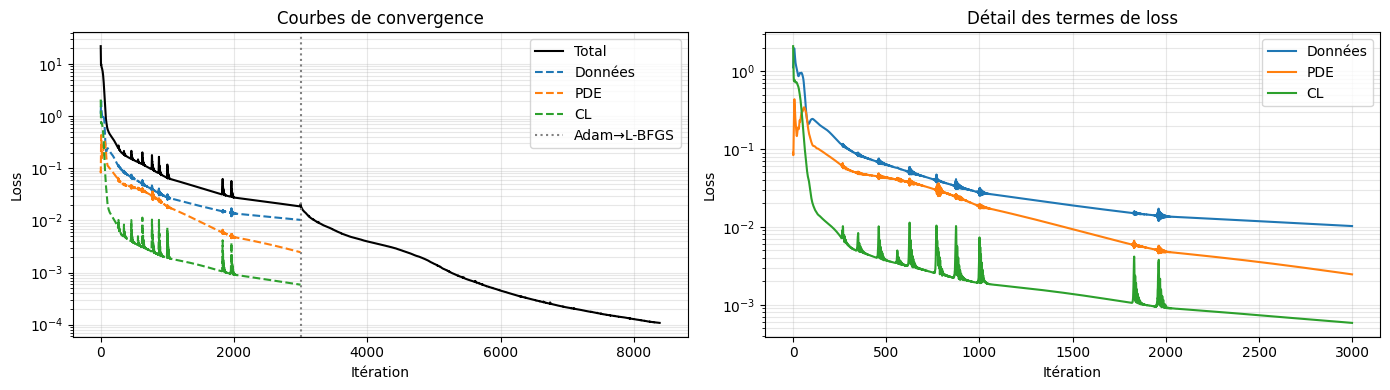


PARAMÈTRES IDENTIFIÉS
  λ1 (terme convectif) = 0.002048   (attendu ≈ 1.0)
  λ2 (viscosité ν)     = 2.67e-06 m²/s
     → eau à 20°C : ν ≈ 1.00e-6 m²/s
     → air à 20°C : ν ≈ 1.50e-5 m²/s


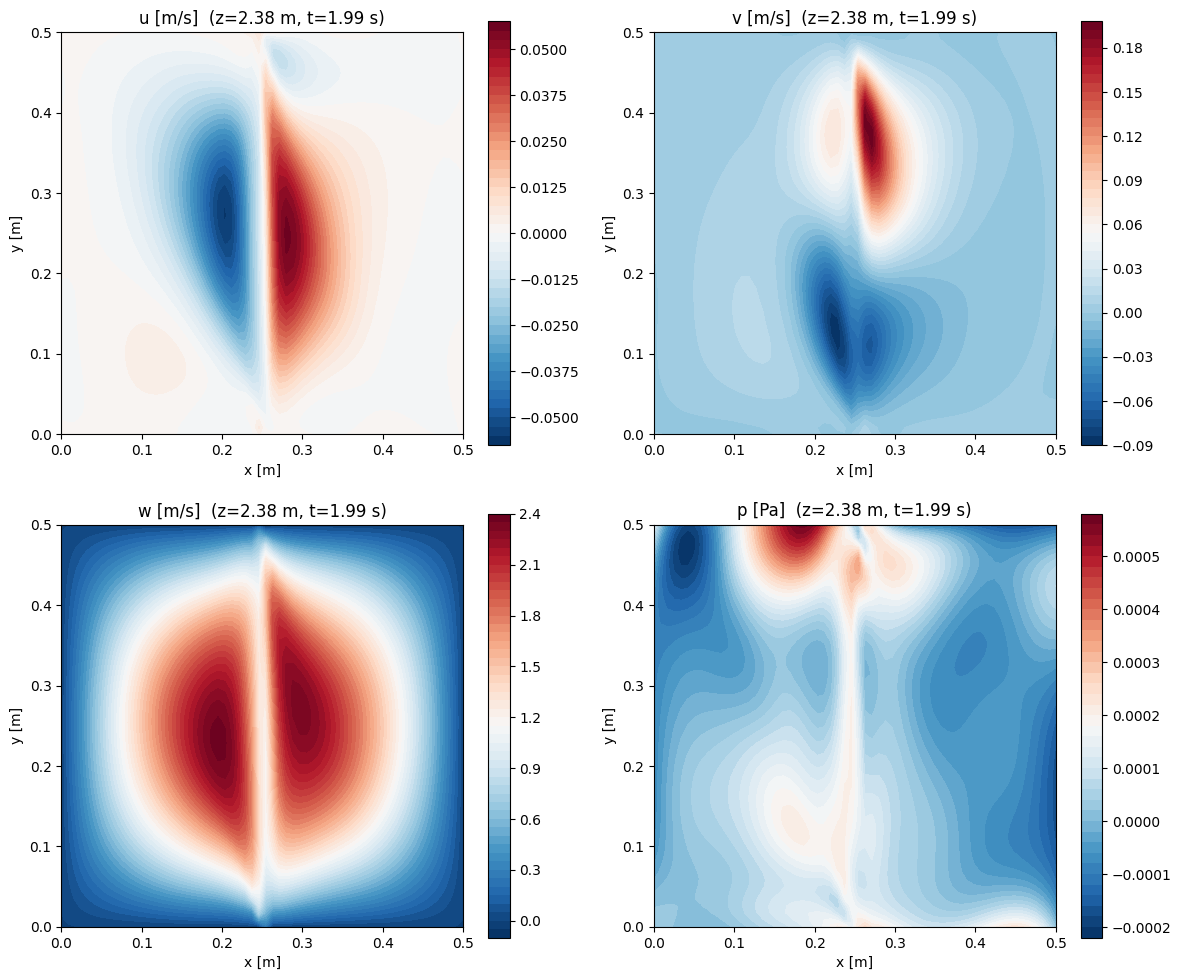

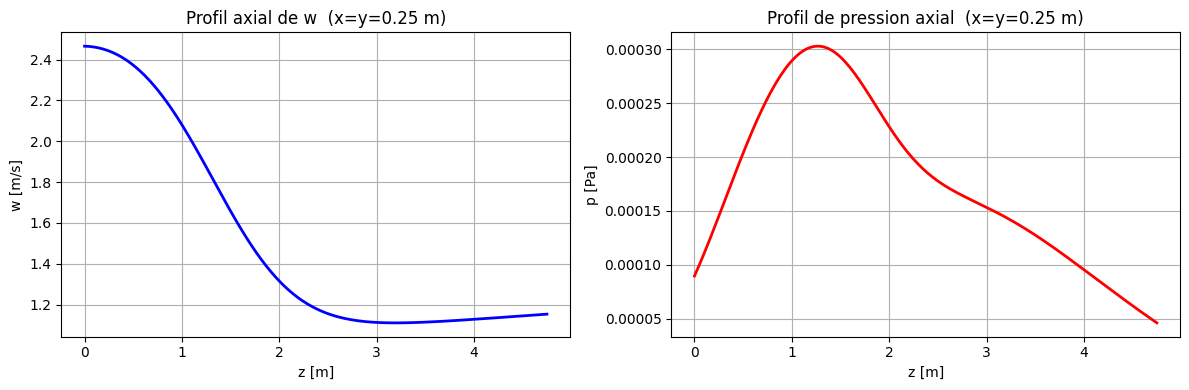


Figures sauvegardées : convergence.png, coupe_XY.png, profils_axiaux.png


In [58]:
# =============================================================================
# MAIN — PINN 3D INSTATIONNAIRE  (x, y, z, t)  →  (u, v, w, p)
# Conduite parallélépipédique 0.5 × 0.5 m
# À exécuter APRÈS chargement_donnees_pinn.py
# =============================================================================

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.autograd as autograd
import matplotlib.pyplot as plt
import time
import os

# -----------------------------------------------------------------------------
# Device
# -----------------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# -----------------------------------------------------------------------------
# Constantes géométriques et physiques
# -----------------------------------------------------------------------------
LX     = 0.5    # largeur conduite [m]
LY     = 0.5    # hauteur conduite [m]
U_MEAN = 1.0    # vitesse débitante en entrée [m/s]

# =============================================================================
# 1. CHARGEMENT DES DONNÉES
# =============================================================================
SAVE_PATH = '/content/dataset_pinn.pt'
print(f"\nChargement des données depuis : {SAVE_PATH}")

data   = torch.load(SAVE_PATH)
x_data = data['x'].numpy()   # (N,1)  float32
y_data = data['y'].numpy()
z_data = data['z'].numpy()
u_data = data['u'].numpy()
v_data = data['v'].numpy()
w_data = data['w'].numpy()
t_data = data['t'].numpy()
z_out  = float(data['z_out'])
t_max  = float(t_data.max())

print(f"Points totaux  : {x_data.shape[0]:,}")
print(f"Domaine Z      : [0, {z_out:.4f}] m")
print(f"Domaine t      : [0, {t_max:.4f}] s  ({data['meta']['n_fichiers']} pas de temps)")

# =============================================================================
# 2. NORMALISATION  →  toutes les entrées ramenées dans [-1, 1]
# =============================================================================
# On stocke les bornes pour dénormaliser si besoin
bounds = {
    'x': (0.0,   LX),
    'y': (0.0,   LY),
    'z': (0.0,   z_out),
    't': (0.0,   t_max),
}

def normalize(arr, lb, ub):
    return 2.0 * (arr - lb) / (ub - lb) - 1.0

x_n = normalize(x_data, *bounds['x'])
y_n = normalize(y_data, *bounds['y'])
z_n = normalize(z_data, *bounds['z'])
t_n = normalize(t_data, *bounds['t'])

# =============================================================================
# 3. ARCHITECTURE DU RÉSEAU
# =============================================================================
# Entrée : (x, y, z, t) normalisés  →  4 neurones
# Sortie : (u, v, w, p)             →  4 neurones
# Couches cachées : 6 × 64 neurones (bon compromis précision/vitesse sur GPU)

layers = [4, 64, 64, 64, 64, 64, 64, 4]

class PINN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.net = self._build(layers)
        self._init_weights()
        # Paramètres physiques à identifier
        self.lambda_1 = nn.Parameter(torch.tensor([1.0]))   # terme convectif (≈1)
        self.lambda_2 = nn.Parameter(torch.tensor([1e-4]))  # viscosité ν [m²/s]
                                                             # eau≈1e-6, air≈1.5e-5

    def _build(self, layers):
        mods = []
        for i in range(len(layers) - 2):
            mods += [nn.Linear(layers[i], layers[i+1]), nn.Tanh()]
        mods.append(nn.Linear(layers[-2], layers[-1]))
        return nn.Sequential(*mods)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x, y, z, t):
        inp = torch.cat([x, y, z, t], dim=1)
        out = self.net(inp)
        return out[:, 0:1], out[:, 1:2], out[:, 2:3], out[:, 3:4]  # u,v,w,p


# =============================================================================
# 4. RÉSIDUS NAVIER-STOKES 3D INSTATIONNAIRE
# =============================================================================

def grad(f, var):
    return autograd.grad(f.sum(), var, create_graph=True)[0]

def pde_residuals(model, x, y, z, t):
    """
    NS 3D instationnaire incompressible :
      ∂u/∂t + λ1(u·∇u) = -∂p/∂x + λ2·∇²u
      ∂v/∂t + λ1(u·∇v) = -∂p/∂y + λ2·∇²v
      ∂w/∂t + λ1(u·∇w) = -∂p/∂z + λ2·∇²w
      ∇·u = 0
    """
    u, v, w, p = model(x, y, z, t)
    l1, l2 = model.lambda_1, model.lambda_2

    # Dérivées premières
    u_t = grad(u, t);  u_x = grad(u, x);  u_y = grad(u, y);  u_z = grad(u, z)
    v_t = grad(v, t);  v_x = grad(v, x);  v_y = grad(v, y);  v_z = grad(v, z)
    w_t = grad(w, t);  w_x = grad(w, x);  w_y = grad(w, y);  w_z = grad(w, z)
    p_x = grad(p, x);  p_y = grad(p, y);  p_z = grad(p, z)

    # Dérivées secondes (laplacien)
    u_xx = grad(u_x, x);  u_yy = grad(u_y, y);  u_zz = grad(u_z, z)
    v_xx = grad(v_x, x);  v_yy = grad(v_y, y);  v_zz = grad(v_z, z)
    w_xx = grad(w_x, x);  w_yy = grad(w_y, y);  w_zz = grad(w_z, z)

    # Résidus
    f_cont = u_x + v_y + w_z
    f_u = u_t + l1*(u*u_x + v*u_y + w*u_z) + p_x - l2*(u_xx + u_yy + u_zz)
    f_v = v_t + l1*(u*v_x + v*v_y + w*v_z) + p_y - l2*(v_xx + v_yy + v_zz)
    f_w = w_t + l1*(u*w_x + v*w_y + w*w_z) + p_z - l2*(w_xx + w_yy + w_zz)

    return f_cont, f_u, f_v, f_w, u, v, w, p


# =============================================================================
# 5. CONDITIONS AUX LIMITES
# =============================================================================

def profil_entree(x_np, y_np):
    """Poiseuille 3D approx. → vitesse moyenne = U_MEAN."""
    w0 = U_MEAN * (np.pi / 2)**2
    return w0 * np.sin(np.pi * x_np / LX) * np.sin(np.pi * y_np / LY)

def make_bc_tensors(z_out, t_max, n_wall=800, n_inlet=400, n_outlet=400):
    """Génère les points de CL pour TOUS les instants (t aléatoire dans [0, t_max])."""

    def rnd(lo, hi, n): return np.random.uniform(lo, hi, n)

    # --- Parois (4 faces latérales) ---
    n4 = n_wall // 4
    def wall_face(x_fixed=None, y_fixed=None):
        if x_fixed is not None:
            return (np.full(n4, x_fixed),
                    rnd(0, LY, n4),
                    rnd(0, z_out, n4),
                    rnd(0, t_max, n4))
        else:
            return (rnd(0, LX, n4),
                    np.full(n4, y_fixed),
                    rnd(0, z_out, n4),
                    rnd(0, t_max, n4))

    faces = [wall_face(x_fixed=0.0), wall_face(x_fixed=LX),
             wall_face(y_fixed=0.0), wall_face(y_fixed=LY)]
    xw = np.concatenate([f[0] for f in faces])
    yw = np.concatenate([f[1] for f in faces])
    zw = np.concatenate([f[2] for f in faces])
    tw = np.concatenate([f[3] for f in faces])

    # --- Entrée (Z = 0) ---
    xi = rnd(0, LX, n_inlet);  yi = rnd(0, LY, n_inlet)
    zi = np.zeros(n_inlet);    ti = rnd(0, t_max, n_inlet)
    wi_target = profil_entree(xi, yi)

    # --- Sortie (Z = z_out) ---
    xo = rnd(0, LX, n_outlet);  yo = rnd(0, LY, n_outlet)
    zo = np.full(n_outlet, z_out);  to = rnd(0, t_max, n_outlet)

    def T(arr, g=False):
        """numpy → tenseur float32 normalisé sur GPU."""
        return torch.tensor(arr[:, None], dtype=torch.float32,
                            requires_grad=g).to(device)

    # Normalisation des CL
    return {
        # Parois
        'xw': T(normalize(xw, *bounds['x']), True),
        'yw': T(normalize(yw, *bounds['y']), True),
        'zw': T(normalize(zw, *bounds['z']), True),
        'tw': T(normalize(tw, *bounds['t']), True),
        # Entrée
        'xi': T(normalize(xi, *bounds['x']), True),
        'yi': T(normalize(yi, *bounds['y']), True),
        'zi': T(normalize(zi, *bounds['z']), True),
        'ti': T(normalize(ti, *bounds['t']), True),
        'wi': torch.tensor(wi_target[:, None], dtype=torch.float32).to(device),
        # Sortie
        'xo': T(normalize(xo, *bounds['x']), True),
        'yo': T(normalize(yo, *bounds['y']), True),
        'zo': T(normalize(zo, *bounds['z']), True),
        'to': T(normalize(to, *bounds['t']), True),
    }


# =============================================================================
# 6. FONCTION DE LOSS
# =============================================================================

def compute_loss(model, col, dat, bc,
                 w_data=1.0, w_pde=1.0, w_bc=10.0):
    """
    col  : dict de tenseurs de collocation (intérieur)
    dat  : dict de tenseurs de données mesurées
    bc   : dict de tenseurs de conditions aux limites
    """
    # ── PDE (collocation) ──────────────────────────────────────────────────
    fc, fu, fv, fw, _, _, _, _ = pde_residuals(
        model, col['x'], col['y'], col['z'], col['t'])
    loss_pde = (fc.pow(2).mean() + fu.pow(2).mean()
                + fv.pow(2).mean() + fw.pow(2).mean())

    # ── Données mesurées ──────────────────────────────────────────────────
    up, vp, wp, _ = model(dat['x'], dat['y'], dat['z'], dat['t'])
    loss_dat = ((dat['u'] - up).pow(2).mean()
                + (dat['v'] - vp).pow(2).mean()
                + (dat['w'] - wp).pow(2).mean())

    # ── CL parois (no-slip) ───────────────────────────────────────────────
    uw, vw, ww, _ = model(bc['xw'], bc['yw'], bc['zw'], bc['tw'])
    loss_wall = uw.pow(2).mean() + vw.pow(2).mean() + ww.pow(2).mean()

    # ── CL entrée ─────────────────────────────────────────────────────────
    ui, vi, wi_pred, _ = model(bc['xi'], bc['yi'], bc['zi'], bc['ti'])
    loss_inlet = ((wi_pred - bc['wi']).pow(2).mean()
                  + ui.pow(2).mean() + vi.pow(2).mean())

    # ── CL sortie (p = 0) ─────────────────────────────────────────────────
    _, _, _, po = model(bc['xo'], bc['yo'], bc['zo'], bc['to'])
    loss_outlet = po.pow(2).mean()

    loss_bc = loss_wall + loss_inlet + loss_outlet
    total    = w_data*loss_dat + w_pde*loss_pde + w_bc*loss_bc

    return total, loss_dat, loss_pde, loss_bc


# =============================================================================
# 7. PRÉPARATION DES TENSEURS D'ENTRAÎNEMENT
# =============================================================================
N_train  = 5000    # points de données mesurées (sur ~200×N_points_par_fichier)
N_colloc = 10000   # points de collocation intérieur

print(f"\nÉchantillonnage : {N_train} points de données, {N_colloc} points de collocation")

# Points de données
total_pts = x_n.shape[0]
idx = np.random.choice(total_pts, min(N_train, total_pts), replace=False)

def T(arr, g=False):
    return torch.tensor(arr, dtype=torch.float32,
                        requires_grad=g).to(device)

dat = {
    'x': T(x_n[idx], True), 'y': T(y_n[idx], True),
    'z': T(z_n[idx], True), 't': T(t_n[idx], True),
    'u': T(u_data[idx]),    'v': T(v_data[idx]),
    'w': T(w_data[idx]),
}

# Points de collocation (intérieur + tout le domaine temporel)
col = {
    'x': T(normalize(np.random.uniform(0,    LX,    (N_colloc,1)), *bounds['x']), True),
    'y': T(normalize(np.random.uniform(0,    LY,    (N_colloc,1)), *bounds['y']), True),
    'z': T(normalize(np.random.uniform(0,    z_out, (N_colloc,1)), *bounds['z']), True),
    't': T(normalize(np.random.uniform(0,    t_max, (N_colloc,1)), *bounds['t']), True),
}

# Conditions aux limites
bc = make_bc_tensors(z_out, t_max)

# =============================================================================
# 8. ENTRAÎNEMENT
# =============================================================================
model = PINN(layers).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Architecture : {layers}")
print(f"Paramètres   : {n_params:,}")

ADAM_ITERS   = 3000
LBFGS_ITERS  = 5000
LOG_EVERY    = 100

history = {'loss': [], 'loss_dat': [], 'loss_pde': [], 'loss_bc': []}

# ── Phase 1 : Adam ──────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print("PHASE 1 — Adam")
print(f"{'='*65}")

optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1000, gamma=0.5)
t0 = time.time()

for it in range(ADAM_ITERS):
    optimizer.zero_grad()
    total, ld, lp, lb = compute_loss(model, col, dat, bc)
    total.backward()
    optimizer.step()
    scheduler.step()

    history['loss'].append(total.item())
    history['loss_dat'].append(ld.item())
    history['loss_pde'].append(lp.item())
    history['loss_bc'].append(lb.item())

    if it % LOG_EVERY == 0:
        print(f"  It {it:5d} | total {total.item():.3e} | "
              f"dat {ld.item():.3e} | pde {lp.item():.3e} | bc {lb.item():.3e} | "
              f"λ1={model.lambda_1.item():.4f} λ2={model.lambda_2.item():.2e} | "
              f"{time.time()-t0:.1f}s")
        t0 = time.time()

# Sauvegarde intermédiaire (utile si la session Colab tombe)
torch.save(model.state_dict(), '/content/pinn_adam.pt')
print("  → Checkpoint Adam sauvegardé : /content/pinn_adam.pt")

# ── Phase 2 : L-BFGS ────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print("PHASE 2 — L-BFGS")
print(f"{'='*65}")

optimizer_lb = optim.LBFGS(
    model.parameters(),
    max_iter=LBFGS_ITERS,
    tolerance_grad=1e-9,
    tolerance_change=1e-9,
    history_size=50,
    line_search_fn="strong_wolfe",
)

lbfgs_counter = [0]

def closure():
    optimizer_lb.zero_grad()
    total, ld, lp, lb = compute_loss(model, col, dat, bc)
    total.backward()
    lbfgs_counter[0] += 1
    if lbfgs_counter[0] % 50 == 0:
        print(f"  It {lbfgs_counter[0]:5d} | total {total.item():.3e} | "
              f"dat {ld.item():.3e} | pde {lp.item():.3e} | bc {lb.item():.3e} | "
              f"λ1={model.lambda_1.item():.4f} λ2={model.lambda_2.item():.2e}")
    history['loss'].append(total.item())
    return total

optimizer_lb.step(closure)

# Sauvegarde finale
torch.save(model.state_dict(), '/content/pinn_final.pt')
print("\n  → Modèle final sauvegardé : /content/pinn_final.pt")

# =============================================================================
# 9. COURBES D'APPRENTISSAGE
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].semilogy(history['loss'], label='Total', color='k')
axes[0].semilogy(history['loss_dat'], label='Données', linestyle='--')
axes[0].semilogy(history['loss_pde'], label='PDE', linestyle='--')
axes[0].semilogy(history['loss_bc'],  label='CL',  linestyle='--')
axes[0].axvline(ADAM_ITERS, color='gray', linestyle=':', label='Adam→L-BFGS')
axes[0].set_xlabel('Itération'); axes[0].set_ylabel('Loss')
axes[0].set_title('Courbes de convergence'); axes[0].legend()
axes[0].grid(True, which='both', alpha=0.3)

axes[1].semilogy(history['loss_dat'], label='Données')
axes[1].semilogy(history['loss_pde'], label='PDE')
axes[1].semilogy(history['loss_bc'],  label='CL')
axes[1].set_xlabel('Itération'); axes[1].set_ylabel('Loss')
axes[1].set_title('Détail des termes de loss'); axes[1].legend()
axes[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/convergence.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# 10. RÉSULTATS FINAUX
# =============================================================================
print(f"\n{'='*65}")
print("PARAMÈTRES IDENTIFIÉS")
print(f"{'='*65}")
l1 = model.lambda_1.item()
l2 = model.lambda_2.item()
print(f"  λ1 (terme convectif) = {l1:.6f}   (attendu ≈ 1.0)")
print(f"  λ2 (viscosité ν)     = {l2:.2e} m²/s")
print(f"     → eau à 20°C : ν ≈ 1.00e-6 m²/s")
print(f"     → air à 20°C : ν ≈ 1.50e-5 m²/s")

# =============================================================================
# 11. VISUALISATION — coupe XY à t donné et z donné
# =============================================================================
model.eval()

def predict_slice(z_phys, t_phys, n_grid=60):
    """Prédit u,v,w,p sur une grille XY à z et t fixés."""
    xi = np.linspace(0, LX, n_grid)
    yi = np.linspace(0, LY, n_grid)
    Xi, Yi = np.meshgrid(xi, yi)
    xf = normalize(Xi.flatten()[:, None], *bounds['x'])
    yf = normalize(Yi.flatten()[:, None], *bounds['y'])
    zf = normalize(np.full((n_grid**2, 1), z_phys), *bounds['z'])
    tf = normalize(np.full((n_grid**2, 1), t_phys), *bounds['t'])

    with torch.no_grad():
        up, vp, wp, pp = model(T(xf, True), T(yf, True), T(zf, True), T(tf, True))

    def R(t): return t.cpu().numpy().reshape(n_grid, n_grid)
    return Xi, Yi, R(up), R(vp), R(wp), R(pp)

# Coupe à mi-longueur, dernier instant
z_slice = z_out / 2.0
t_slice = t_max

Xi, Yi, Up, Vp, Wp, Pp = predict_slice(z_slice, t_slice)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fields  = [Up, Vp, Wp, Pp]
titles  = [f'u [m/s]', f'v [m/s]', f'w [m/s]', f'p [Pa]']

for ax, field, title in zip(axes.flat, fields, titles):
    cf = ax.contourf(Xi, Yi, field, levels=50, cmap='RdBu_r')
    plt.colorbar(cf, ax=ax)
    ax.set_title(f'{title}  (z={z_slice:.2f} m, t={t_slice:.2f} s)')
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('/content/coupe_XY.png', dpi=150, bbox_inches='tight')
plt.show()

# Profil axial à x=y=0.25 m, dernier instant
z_axis = np.linspace(0, z_out, 200)
xax = normalize(np.full((200, 1), 0.25), *bounds['x'])
yax = normalize(np.full((200, 1), 0.25), *bounds['y'])
zax = normalize(z_axis[:, None], *bounds['z'])
tax = normalize(np.full((200, 1), t_max), *bounds['t'])

with torch.no_grad():
    _, _, w_ax, p_ax = model(T(xax, True), T(yax, True), T(zax, True), T(tax, True))

fig2, ax2 = plt.subplots(1, 2, figsize=(12, 4))
ax2[0].plot(z_axis, w_ax.cpu().numpy(), 'b-', lw=2)
ax2[0].set_xlabel('z [m]'); ax2[0].set_ylabel('w [m/s]')
ax2[0].set_title('Profil axial de w  (x=y=0.25 m)'); ax2[0].grid(True)

ax2[1].plot(z_axis, p_ax.cpu().numpy(), 'r-', lw=2)
ax2[1].set_xlabel('z [m]'); ax2[1].set_ylabel('p [Pa]')
ax2[1].set_title('Profil de pression axial  (x=y=0.25 m)'); ax2[1].grid(True)

plt.tight_layout()
plt.savefig('/content/profils_axiaux.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigures sauvegardées : convergence.png, coupe_XY.png, profils_axiaux.png")

## 3e essai : Avec les données mises dans leur domaine du pb

Using device: cuda

Chargement : /content/dataset_pinn.pt
Points       : 1,000,000
Y ∈ [0.000, 0.500] m   (attendu [0, 0.5])
Z ∈ [3.250, 4.750] m   (attendu [3.25, 4.75])
t ∈ [0.0000, 1.9900] s   (200 pas de temps)
v ∈ [-0.0020, 0.0020] m/s
w ∈ [0.2657, 1.1502] m/s

Échantillonnage : 5000 données + 10000 collocation
Architecture : [3, 20, 20, 20, 20, 20, 20, 20, 20, 3]  →  3,085 paramètres

PHASE 1 — Adam
  It     0 | total 2.112e+00 | dat 1.527e+00 | pde 5.849e-01 | λ1=-0.0010  λ2=1.000e-03 | 0.1s
  It   500 | total 1.713e-02 | dat 1.620e-02 | pde 9.357e-04 | λ1=-0.0249  λ2=9.255e-04 | 22.8s
  It  1000 | total 1.498e-02 | dat 1.460e-02 | pde 3.805e-04 | λ1=-0.0219  λ2=-7.159e-04 | 22.9s
  It  1500 | total 1.015e-02 | dat 9.719e-03 | pde 4.360e-04 | λ1=-0.0227  λ2=3.982e-03 | 22.9s
  It  2000 | total 1.318e-03 | dat 1.216e-03 | pde 1.020e-04 | λ1=-0.0318  λ2=-1.417e-04 | 24.1s
  It  2500 | total 6.333e-04 | dat 5.879e-04 | pde 4.545e-05 | λ1=-0.0321  λ2=2.955e-05 | 23.1s
  It  3000 | t

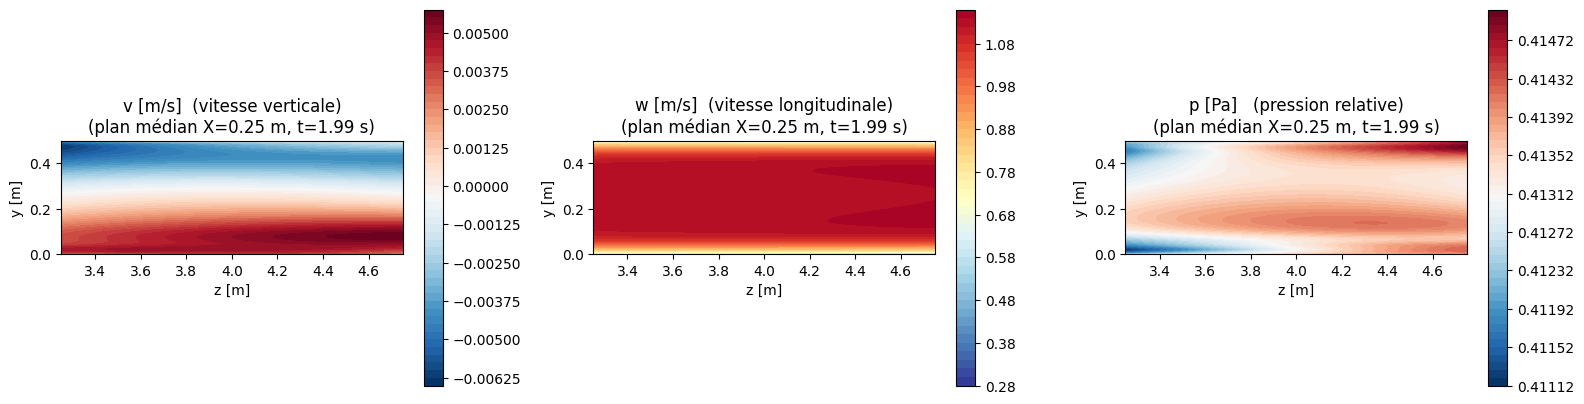

Sauvegardé : /content/champs_plan_median.png


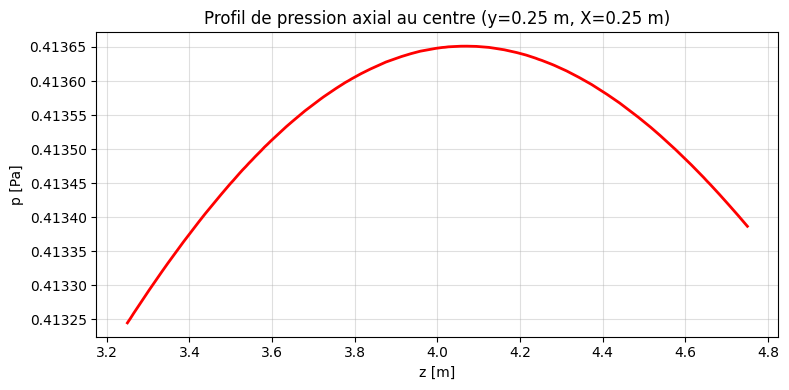

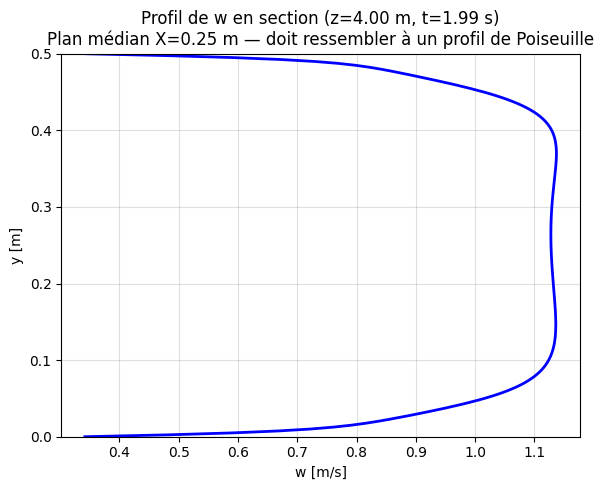

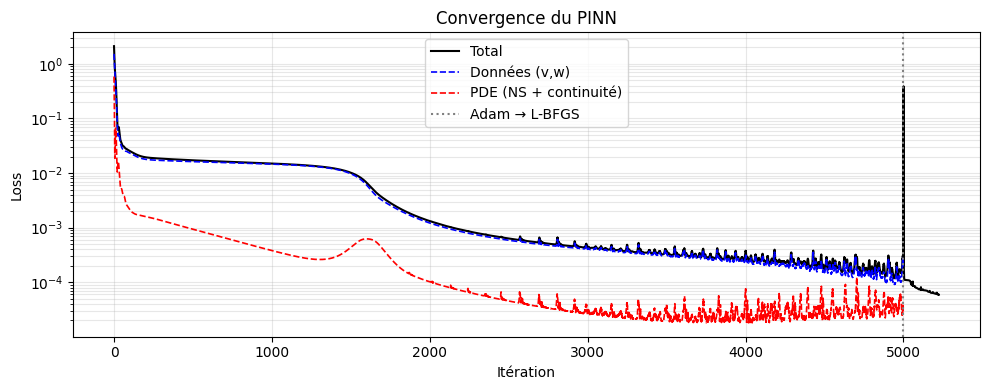


RÉCAPITULATIF FINAL
  Fluide simulé        : air isotherme
  λ1 identifié         : 0.03691  (attendu 1.0)
  ν  identifié         : 1.5626e-06 m²/s
  ν  air à 20°C        : 1.516e-05 m²/s
  Plan médian          : X = 0.25 m
  Zone d'étude         : Z ∈ [3.25, 4.75] m,  Y ∈ [0, 0.5] m
  Figures sauvegardées : champs_plan_median.png,
                         profil_pression_axial.png,
                         profil_w_section.png,
                         convergence.png


In [59]:
# =============================================================================
# PINN — Plan médian conduite  (Y, Z, t)  →  (v, w, p)
# Reproduit l'approche de Raissi et al. appliquée à une conduite
#
# Données : X = 0.25 m (fixe), Y ∈ [0, 0.5] m, Z ∈ [3.25, 4.75] m
# Objectif : identifier p(y,z,t) et ν (viscosité cinématique de l'air)
# Entraînement : sur v et w uniquement (comme l'article)
# =============================================================================

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.autograd as autograd
import matplotlib.pyplot as plt
import time

# -----------------------------------------------------------------------------
# Device
# -----------------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# -----------------------------------------------------------------------------
# Domaine physique (lu dans le mail)
# -----------------------------------------------------------------------------
Y_MIN, Y_MAX = 0.0,  0.5    # hauteur conduite [m]
Z_MIN, Z_MAX = 3.25, 4.75   # portion longitudinale mesurée [m]
# Le temps sera déduit des données (t_min=0, t_max à calculer)

# =============================================================================
# 1. CHARGEMENT DES DONNÉES
# =============================================================================
SAVE_PATH = '/content/dataset_pinn.pt'
print(f"\nChargement : {SAVE_PATH}")

data   = torch.load(SAVE_PATH)

# On ne garde que Y, Z, t, v, w  (X est constant = 0.25 m → inutile)
y_data = data['y'].numpy()   # (N,1)
z_data = data['z'].numpy()
t_data = data['t'].numpy()
v_data = data['v'].numpy()
w_data = data['w'].numpy()

t_min = float(t_data.min())
t_max = float(t_data.max())

print(f"Points       : {y_data.shape[0]:,}")
print(f"Y ∈ [{y_data.min():.3f}, {y_data.max():.3f}] m   (attendu [0, 0.5])")
print(f"Z ∈ [{z_data.min():.3f}, {z_data.max():.3f}] m   (attendu [3.25, 4.75])")
print(f"t ∈ [{t_min:.4f}, {t_max:.4f}] s   (200 pas de temps)")
print(f"v ∈ [{v_data.min():.4f}, {v_data.max():.4f}] m/s")
print(f"w ∈ [{w_data.min():.4f}, {w_data.max():.4f}] m/s")

# =============================================================================
# 2. NORMALISATION dans [-1, 1]
# =============================================================================
bounds = {
    'y': (Y_MIN, Y_MAX),
    'z': (Z_MIN, Z_MAX),
    't': (t_min, t_max),
}

def norm(arr, lo, hi):
    return 2.0 * (arr - lo) / (hi - lo) - 1.0

y_n = norm(y_data, *bounds['y'])
z_n = norm(z_data, *bounds['z'])
t_n = norm(t_data, *bounds['t'])

# =============================================================================
# 3. ARCHITECTURE  —  (y, z, t) → (v, w, p)
# =============================================================================
# Entrée  : 3 neurones  (y, z, t normalisés)
# Sortie  : 3 neurones  (v, w, p)
# Comme l'article Raissi : 8 couches cachées × 20 neurones
# (On peut augmenter à 64 si GPU disponible)

layers = [3, 20, 20, 20, 20, 20, 20, 20, 20, 3]

class PINN(nn.Module):
    """
    Réseau qui prédit (v, w, p) en fonction de (y, z, t).

    Paramètres à identifier :
      lambda_1  ≈ 1     (terme convectif, = 1/ρ en formulation pression)
      lambda_2  ≈ ν     viscosité cinématique de l'air [m²/s]
                        valeur attendue ≈ 1.5e-5 m²/s à 20°C
    """
    def __init__(self, layers):
        super().__init__()
        self.net = self._build(layers)
        self._init_weights()
        # Initialisations proches des valeurs physiques attendues
        self.lambda_1 = nn.Parameter(torch.tensor([0.0]))
        self.lambda_2 = nn.Parameter(torch.tensor([0.0]))

    def _build(self, layers):
        mods = []
        for i in range(len(layers) - 2):
            mods += [nn.Linear(layers[i], layers[i+1]), nn.Tanh()]
        mods.append(nn.Linear(layers[-2], layers[-1]))
        return nn.Sequential(*mods)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, y, z, t):
        inp = torch.cat([y, z, t], dim=1)
        out = self.net(inp)
        v = out[:, 0:1]
        w = out[:, 1:2]
        p = out[:, 2:3]
        return v, w, p


# =============================================================================
# 4. RÉSIDUS NAVIER-STOKES 2D dans le plan médian
# =============================================================================
# Dans le plan X=0.25 m (symétrie), u≈0 et ∂/∂x ≈ 0.
# Les équations NS se réduisent à :
#
#   Continuité :  ∂v/∂y + ∂w/∂z = 0
#
#   NS-y :  ∂v/∂t + λ1·(v·∂v/∂y + w·∂v/∂z) = −∂p/∂y + λ2·(∂²v/∂y² + ∂²v/∂z²)
#   NS-z :  ∂w/∂t + λ1·(v·∂w/∂y + w·∂w/∂z) = −∂p/∂z + λ2·(∂²w/∂y² + ∂²w/∂z²)

def G(f, x):
    """Dérivée automatique avec graphe de calcul."""
    return autograd.grad(f.sum(), x, create_graph=True)[0]

def pde_residuals(model, y, z, t):
    v, w, p = model(y, z, t)
    l1, l2 = model.lambda_1, model.lambda_2

    # Dérivées premières
    v_t = G(v,t);  v_y = G(v,y);  v_z = G(v,z)
    w_t = G(w,t);  w_y = G(w,y);  w_z = G(w,z)
    p_y = G(p,y);  p_z = G(p,z)

    # Dérivées secondes
    v_yy = G(v_y,y);  v_zz = G(v_z,z)
    w_yy = G(w_y,y);  w_zz = G(w_z,z)

    # Résidus
    f_cont = v_y + w_z
    f_v    = v_t + l1*(v*v_y + w*v_z) + p_y - l2*(v_yy + v_zz)
    f_w    = w_t + l1*(v*w_y + w*w_z) + p_z - l2*(w_yy + w_zz)

    return f_cont, f_v, f_w, v, w, p


# =============================================================================
# 5. LOSS
# =============================================================================
def compute_loss(model, col, dat, w_data=1.0, w_pde=1.0):
    """
    Pas de CL explicites ici : les données couvrent tout le plan médian
    et les CL de paroi (v=w=0 en y=0 et y=0.5) sont contenues dans les
    données elles-mêmes (maillage régulier qui inclut les parois).
    La CL de sortie p=0 est imposée via un point de référence.
    """
    # ── Résidus PDE ──────────────────────────────────────────────────────────
    fc, fv, fw, _, _, _ = pde_residuals(model, col['y'], col['z'], col['t'])
    loss_pde = fc.pow(2).mean() + fv.pow(2).mean() + fw.pow(2).mean()

    # ── Données mesurées (v et w) ─────────────────────────────────────────
    vp, wp, _ = model(dat['y'], dat['z'], dat['t'])
    loss_dat  = (dat['v'] - vp).pow(2).mean() + (dat['w'] - wp).pow(2).mean()

    total = w_data * loss_dat + w_pde * loss_pde
    return total, loss_dat, loss_pde


# =============================================================================
# 6. TENSEURS D'ENTRAÎNEMENT
# =============================================================================
N_train  = 5000    # points de données
N_colloc = 10000   # points de collocation (intérieur du domaine)

print(f"\nÉchantillonnage : {N_train} données + {N_colloc} collocation")

total_pts = y_n.shape[0]
idx = np.random.choice(total_pts, min(N_train, total_pts), replace=False)

def T(arr, g=False):
    return torch.tensor(arr, dtype=torch.float32,
                        requires_grad=g).to(device)

dat = {
    'y': T(y_n[idx], True),
    'z': T(z_n[idx], True),
    't': T(t_n[idx], True),
    'v': T(v_data[idx]),
    'w': T(w_data[idx]),
}

# Points de collocation : distribution uniforme dans [Y_MIN,Y_MAX]×[Z_MIN,Z_MAX]×[t_min,t_max]
col = {
    'y': T(norm(np.random.uniform(Y_MIN, Y_MAX, (N_colloc,1)), *bounds['y']), True),
    'z': T(norm(np.random.uniform(Z_MIN, Z_MAX, (N_colloc,1)), *bounds['z']), True),
    't': T(norm(np.random.uniform(t_min, t_max, (N_colloc,1)), *bounds['t']), True),
}

# =============================================================================
# 7. ENTRAÎNEMENT
# =============================================================================
model = PINN(layers).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Architecture : {layers}  →  {n_params:,} paramètres")

ADAM_ITERS  = 5000
LBFGS_ITERS = 50000
LOG_EVERY   = 500

history = {'total': [], 'dat': [], 'pde': []}

# ── Phase 1 : Adam ─────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print("PHASE 1 — Adam")
print(f"{'='*65}")
optimizer = optim.Adam(model.parameters(), lr=1e-3)
t0 = time.time()

for it in range(ADAM_ITERS):
    optimizer.zero_grad()
    total, ld, lp = compute_loss(model, col, dat)
    total.backward()
    optimizer.step()

    history['total'].append(total.item())
    history['dat'].append(ld.item())
    history['pde'].append(lp.item())

    if it % LOG_EVERY == 0:
        print(f"  It {it:5d} | total {total.item():.3e} | "
              f"dat {ld.item():.3e} | pde {lp.item():.3e} | "
              f"λ1={model.lambda_1.item():.4f}  "
              f"λ2={model.lambda_2.item():.3e} | "
              f"{time.time()-t0:.1f}s")
        t0 = time.time()

torch.save(model.state_dict(), '/content/pinn_adam.pt')
print("  → Checkpoint Adam sauvegardé")

# ── Phase 2 : L-BFGS ───────────────────────────────────────────────────────
print(f"\n{'='*65}")
print("PHASE 2 — L-BFGS")
print(f"{'='*65}")
optimizer_lb = optim.LBFGS(
    model.parameters(),
    max_iter=LBFGS_ITERS,
    tolerance_grad=1e-9,
    tolerance_change=1e-9,
    history_size=50,
    line_search_fn="strong_wolfe",
)
cpt = [0]

def closure():
    optimizer_lb.zero_grad()
    total, ld, lp = compute_loss(model, col, dat)
    total.backward()
    cpt[0] += 1
    if cpt[0] % 200 == 0:
        print(f"  It {cpt[0]:5d} | total {total.item():.3e} | "
              f"dat {ld.item():.3e} | pde {lp.item():.3e} | "
              f"λ1={model.lambda_1.item():.4f}  λ2={model.lambda_2.item():.3e}")
    history['total'].append(total.item())
    return total

optimizer_lb.step(closure)
torch.save(model.state_dict(), '/content/pinn_final.pt')
print("  → Modèle final sauvegardé : /content/pinn_final.pt")

# =============================================================================
# 8. RÉSULTATS — PARAMÈTRES IDENTIFIÉS
# =============================================================================
l1 = model.lambda_1.item()
l2 = model.lambda_2.item()

print(f"\n{'='*65}")
print("PARAMÈTRES IDENTIFIÉS")
print(f"{'='*65}")
print(f"  λ1 (terme convectif) = {l1:.6f}   (attendu ≈ 1.0)")
print(f"  λ2 (viscosité ν)     = {l2:.4e} m²/s")
print(f"     Référence air à 20°C : ν ≈ 1.516e-5 m²/s")
if l2 > 0:
    print(f"     Erreur relative vs air 20°C : {abs(l2 - 1.516e-5)/1.516e-5*100:.1f}%")

# =============================================================================
# 9. VISUALISATION
# =============================================================================

model.eval()

def make_grid(n=100):
    yi = np.linspace(Y_MIN, Y_MAX, n)
    zi = np.linspace(Z_MIN, Z_MAX, n)
    Yi, Zi = np.meshgrid(yi, zi)  # (n,n)
    return Yi, Zi

def predict_at_t(t_phys, n=100):
    """Prédit v, w, p sur la grille YZ à un instant t_phys."""
    Yi, Zi = make_grid(n)
    yf = norm(Yi.flatten()[:, None], *bounds['y'])
    zf = norm(Zi.flatten()[:, None], *bounds['z'])
    tf = norm(np.full_like(yf, t_phys), *bounds['t'])

    with torch.no_grad():
        vp, wp, pp = model(T(yf, True), T(zf, True), T(tf, True))

    def R(t): return t.cpu().numpy().reshape(n, n)
    return Yi, Zi, R(vp), R(wp), R(pp)

# ── Figure 1 : champs à t = t_max ──────────────────────────────────────────
Yi, Zi, Vp, Wp, Pp = predict_at_t(t_max)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, field, title, cmap in zip(
        axes,
        [Vp, Wp, Pp],
        ['v [m/s]  (vitesse verticale)',
         'w [m/s]  (vitesse longitudinale)',
         'p [Pa]   (pression relative)'],
        ['RdBu_r', 'RdYlBu_r', 'RdBu_r']):
    cf = ax.contourf(Zi, Yi, field, levels=50, cmap=cmap)
    plt.colorbar(cf, ax=ax, shrink=0.8)
    ax.set_xlabel('z [m]')
    ax.set_ylabel('y [m]')
    ax.set_title(f'{title}\n(plan médian X=0.25 m, t={t_max:.2f} s)')
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('/content/champs_plan_median.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sauvegardé : /content/champs_plan_median.png")

# ── Figure 2 : profil de pression axial (centre y=0.25 m) ──────────────────
zi_axis = np.linspace(Z_MIN, Z_MAX, 200)
yc      = np.full((200, 1), 0.25)
zc      = zi_axis[:, None]
tc      = np.full((200, 1), t_max)

with torch.no_grad():
    _, _, p_ax = model(
        T(norm(yc, *bounds['y']), True),
        T(norm(zc, *bounds['z']), True),
        T(norm(tc, *bounds['t']), True)
    )

p_ax_np = p_ax.cpu().numpy().flatten()

fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.plot(zi_axis, p_ax_np, 'r-', lw=2)
ax2.set_xlabel('z [m]');  ax2.set_ylabel('p [Pa]')
ax2.set_title('Profil de pression axial au centre (y=0.25 m, X=0.25 m)')
ax2.grid(True, alpha=0.4)
# La pression doit décroître linéairement de z=3.25 vers z=4.75 (gradient négatif)
# Le signe et la valeur du gradient dp/dz = -λ2 * d²w/dy²|centre
plt.tight_layout()
plt.savefig('/content/profil_pression_axial.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 3 : profil de w en section (z fixé, t = t_max) ─────────────────
z_mid   = (Z_MIN + Z_MAX) / 2.0
yi_sect = np.linspace(Y_MIN, Y_MAX, 200)
yc2     = yi_sect[:, None]
zc2     = np.full((200, 1), z_mid)
tc2     = np.full((200, 1), t_max)

with torch.no_grad():
    _, w_sect, _ = model(
        T(norm(yc2, *bounds['y']), True),
        T(norm(zc2, *bounds['z']), True),
        T(norm(tc2, *bounds['t']), True)
    )

fig3, ax3 = plt.subplots(figsize=(6, 5))
ax3.plot(w_sect.cpu().numpy(), yi_sect, 'b-', lw=2)
ax3.set_xlabel('w [m/s]');  ax3.set_ylabel('y [m]')
ax3.set_title(f'Profil de w en section (z={z_mid:.2f} m, t={t_max:.2f} s)\n'
              f'Plan médian X=0.25 m — doit ressembler à un profil de Poiseuille')
ax3.grid(True, alpha=0.4)
ax3.set_ylim([Y_MIN, Y_MAX])
plt.tight_layout()
plt.savefig('/content/profil_w_section.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 4 : courbes de convergence ─────────────────────────────────────
fig4, ax4 = plt.subplots(figsize=(10, 4))
ax4.semilogy(history['total'], 'k-',  lw=1.5, label='Total')
ax4.semilogy(history['dat'],   'b--', lw=1.2, label='Données (v,w)')
ax4.semilogy(history['pde'],   'r--', lw=1.2, label='PDE (NS + continuité)')
ax4.axvline(ADAM_ITERS, color='gray', linestyle=':', label='Adam → L-BFGS')
ax4.set_xlabel('Itération');  ax4.set_ylabel('Loss')
ax4.set_title('Convergence du PINN');  ax4.legend();  ax4.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/convergence.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*65}")
print("RÉCAPITULATIF FINAL")
print(f"{'='*65}")
print(f"  Fluide simulé        : air isotherme")
print(f"  λ1 identifié         : {l1:.5f}  (attendu 1.0)")
print(f"  ν  identifié         : {l2:.4e} m²/s")
print(f"  ν  air à 20°C        : 1.516e-05 m²/s")
print(f"  Plan médian          : X = 0.25 m")
print(f"  Zone d'étude         : Z ∈ [3.25, 4.75] m,  Y ∈ [0, 0.5] m")
print(f"  Figures sauvegardées : champs_plan_median.png,")
print(f"                         profil_pression_axial.png,")
print(f"                         profil_w_section.png,")
print(f"                         convergence.png")

Il y a eu de conditions limites ...

## 4e essai Tjrs mon code mais en imposant les cdt limites

Using device: cuda
Points : 1,000,000  |  t ∈ [0.000, 1.990] s

Architecture : [3, 20, 20, 20, 20, 20, 20, 20, 20, 3]  →  3,085 paramètres

PHASE 1 — Adam (5000 itérations)
  It     0 | total 7.647e+00 | dat 1.432e+00 | pde 6.498e-01 | bc 2.783e-01 | λ1=-0.0010  λ2=1.000e-03 | 0.1s
  It   500 | total 8.041e-02 | dat 7.533e-02 | pde 1.734e-03 | bc 1.676e-04 | λ1=0.0173  λ2=1.537e-03 | 28.5s
  It  1000 | total 2.759e-02 | dat 2.331e-02 | pde 1.323e-03 | bc 1.474e-04 | λ1=0.0615  λ2=3.281e-04 | 27.6s
  It  1500 | total 1.570e-02 | dat 1.436e-02 | pde 7.275e-04 | bc 3.095e-05 | λ1=0.0799  λ2=2.506e-04 | 25.4s
  It  2000 | total 4.132e-02 | dat 1.051e-02 | pde 4.576e-04 | bc 1.517e-03 | λ1=0.0919  λ2=2.794e-04 | 25.0s
  It  2500 | total 1.172e-02 | dat 1.087e-02 | pde 3.347e-04 | bc 2.550e-05 | λ1=0.0834  λ2=1.119e-04 | 25.0s
  It  3000 | total 1.191e-02 | dat 1.088e-02 | pde 2.841e-04 | bc 3.733e-05 | λ1=0.0595  λ2=7.836e-05 | 24.9s
  It  3500 | total 2.639e-02 | dat 8.577e-03 | pde 2.240e

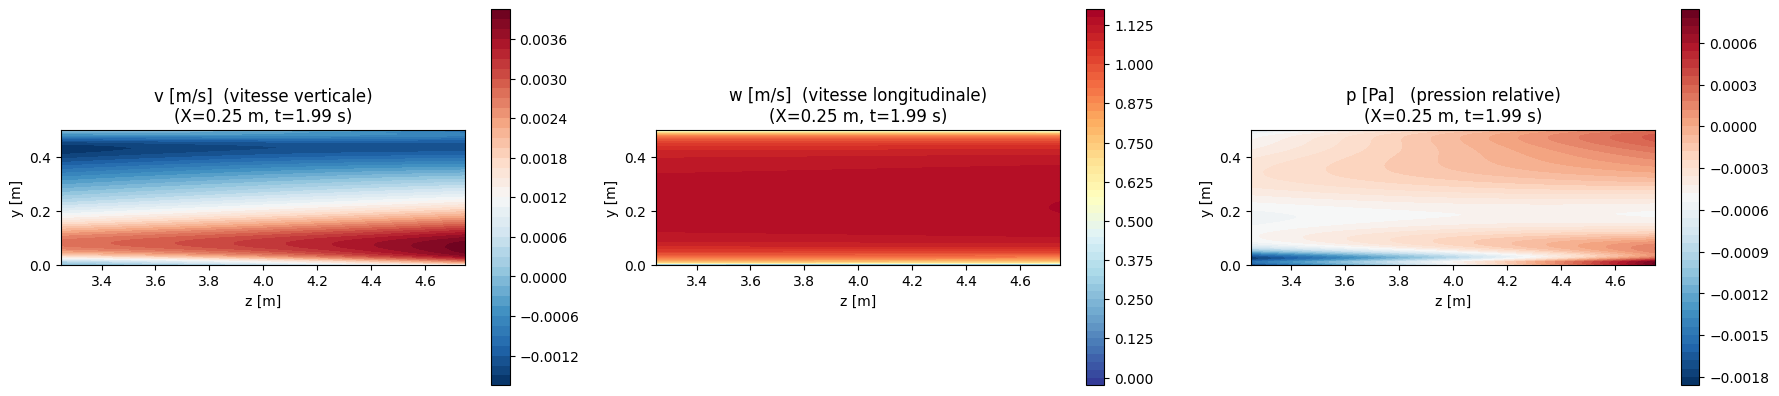

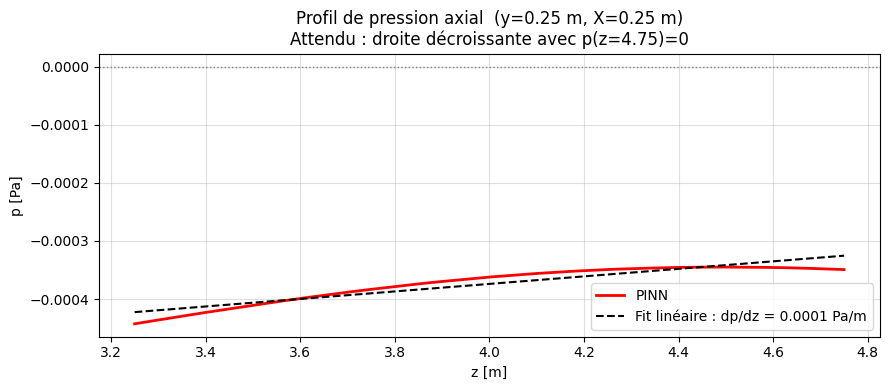

  Gradient de pression identifié : dp/dz = 0.0001 Pa/m
  Pression en entrée (z=3.25 m)  : p = -0.0004 Pa


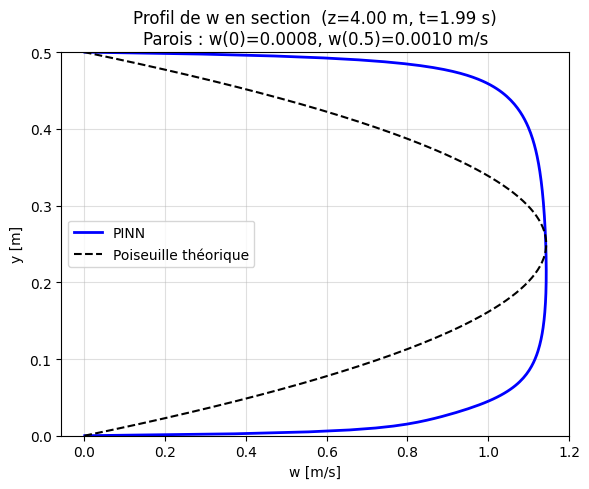

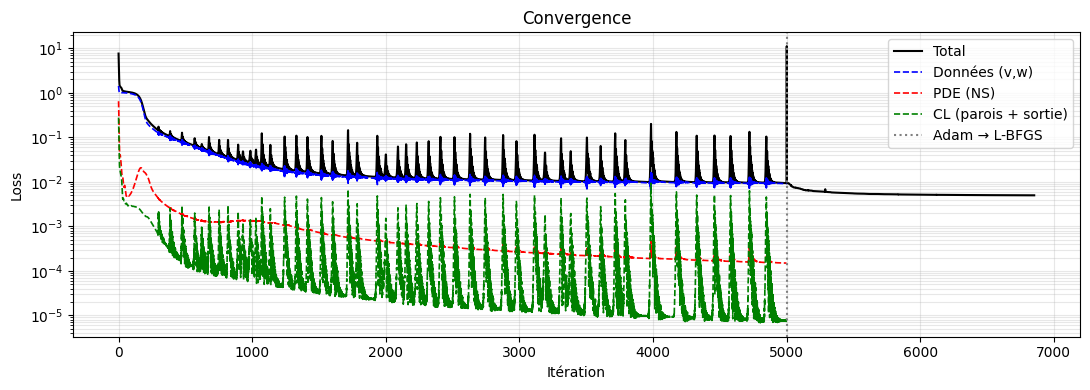


RÉSUMÉ
  λ1                   = -0.05539    (attendu 1.0)
  ν identifié          = -9.3034e-07 m²/s
  ν air 20°C           = 1.516e-05 m²/s
  dp/dz                = 0.0001 Pa/m  (négatif = pression décroissante)
  w(paroi basse)       = 0.00078 m/s  (attendu 0)
  w(paroi haute)       = 0.00100 m/s  (attendu 0)
  p(z=4.75, sortie)    = -0.00035 Pa  (attendu 0)


In [60]:
# =============================================================================
# PINN — Plan médian  (Y, Z, t)  →  (v, w, p)   VERSION CORRIGÉE
# Corrections :
#   1. CL no-slip : v=w=0 en y=0 et y=0.5 (parois haut/bas)
#   2. CL pression : p=0 en z=4.75 (sortie)
#   3. Pondération plus forte sur les CL
# =============================================================================

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.autograd as autograd
import matplotlib.pyplot as plt
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# -----------------------------------------------------------------------------
# Domaine
# -----------------------------------------------------------------------------
Y_MIN, Y_MAX = 0.0,  0.5
Z_MIN, Z_MAX = 3.25, 4.75

# =============================================================================
# 1. CHARGEMENT
# =============================================================================
SAVE_PATH = '/content/dataset_pinn.pt'
data   = torch.load(SAVE_PATH)
y_data = data['y'].numpy()
z_data = data['z'].numpy()
t_data = data['t'].numpy()
v_data = data['v'].numpy()
w_data = data['w'].numpy()
t_min  = float(t_data.min())
t_max  = float(t_data.max())

print(f"Points : {y_data.shape[0]:,}  |  t ∈ [{t_min:.3f}, {t_max:.3f}] s")

# =============================================================================
# 2. NORMALISATION
# =============================================================================
bounds = {'y': (Y_MIN, Y_MAX), 'z': (Z_MIN, Z_MAX), 't': (t_min, t_max)}

def norm(arr, lo, hi):  return 2.0*(arr-lo)/(hi-lo) - 1.0
def denorm(arr, lo, hi): return (arr+1.0)/2.0*(hi-lo) + lo

y_n = norm(y_data, *bounds['y'])
z_n = norm(z_data, *bounds['z'])
t_n = norm(t_data, *bounds['t'])

# =============================================================================
# 3. ARCHITECTURE
# =============================================================================
layers = [3, 20, 20, 20, 20, 20, 20, 20, 20, 3]

class PINN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.net = self._build(layers)
        self._init_weights()
        self.lambda_1 = nn.Parameter(torch.tensor([0.0]))
        self.lambda_2 = nn.Parameter(torch.tensor([0.0]))

    def _build(self, layers):
        mods = []
        for i in range(len(layers)-2):
            mods += [nn.Linear(layers[i], layers[i+1]), nn.Tanh()]
        mods.append(nn.Linear(layers[-2], layers[-1]))
        return nn.Sequential(*mods)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, y, z, t):
        out = self.net(torch.cat([y, z, t], dim=1))
        return out[:,0:1], out[:,1:2], out[:,2:3]  # v, w, p

# =============================================================================
# 4. RÉSIDUS PDE
# =============================================================================
def G(f, x): return autograd.grad(f.sum(), x, create_graph=True)[0]

def pde_residuals(model, y, z, t):
    v, w, p = model(y, z, t)
    l1, l2  = model.lambda_1, model.lambda_2

    v_t=G(v,t); v_y=G(v,y); v_z=G(v,z)
    w_t=G(w,t); w_y=G(w,y); w_z=G(w,z)
    p_y=G(p,y); p_z=G(p,z)
    v_yy=G(v_y,y); v_zz=G(v_z,z)
    w_yy=G(w_y,y); w_zz=G(w_z,z)

    f_cont = v_y + w_z
    f_v    = v_t + l1*(v*v_y + w*v_z) + p_y - l2*(v_yy + v_zz)
    f_w    = w_t + l1*(v*w_y + w*w_z) + p_z - l2*(w_yy + w_zz)
    return f_cont, f_v, f_w, v, w, p

# =============================================================================
# 5. GÉNÉRATION DES POINTS DE CONDITIONS AUX LIMITES
# =============================================================================
def make_bc_tensors(n_wall=500, n_outlet=300):
    """
    Parois  y=0 et y=0.5  :  v=0, w=0   (no-slip)
    Sortie  z=4.75         :  p=0        (pression de référence)
    """
    rnd = np.random.uniform

    # --- Paroi y = 0 ---
    z_w0 = rnd(Z_MIN, Z_MAX, (n_wall,1))
    t_w0 = rnd(t_min, t_max, (n_wall,1))
    y_w0 = np.zeros((n_wall,1))

    # --- Paroi y = Y_MAX ---
    z_w1 = rnd(Z_MIN, Z_MAX, (n_wall,1))
    t_w1 = rnd(t_min, t_max, (n_wall,1))
    y_w1 = np.full((n_wall,1), Y_MAX)

    # Concaténation parois
    y_wall = np.vstack([y_w0, y_w1])
    z_wall = np.vstack([z_w0, z_w1])
    t_wall = np.vstack([t_w0, t_w1])

    # --- Sortie z = Z_MAX ---
    y_out = rnd(Y_MIN, Y_MAX, (n_outlet,1))
    t_out = rnd(t_min, t_max, (n_outlet,1))
    z_out = np.full((n_outlet,1), Z_MAX)

    def T(arr, g=False):
        return torch.tensor(arr, dtype=torch.float32,
                            requires_grad=g).to(device)

    return {
        # Parois (no-slip)
        'y_wall': T(norm(y_wall, *bounds['y']), True),
        'z_wall': T(norm(z_wall, *bounds['z']), True),
        't_wall': T(norm(t_wall, *bounds['t']), True),
        # Sortie (p=0)
        'y_out':  T(norm(y_out, *bounds['y']), True),
        'z_out':  T(norm(z_out, *bounds['z']), True),
        't_out':  T(norm(t_out, *bounds['t']), True),
    }

# =============================================================================
# 6. LOSS
# =============================================================================
def compute_loss(model, col, dat, bc,
                 w_data=1.0, w_pde=1.0, w_bc=20.0):
    """
    Pondérations :
      w_data = 1   : fit des données v,w
      w_pde  = 1   : résidus Navier-Stokes
      w_bc   = 20  : conditions aux limites (plus fort pour les imposer fermement)
    """
    # ── PDE ──────────────────────────────────────────────────────────────────
    fc, fv, fw, _, _, _ = pde_residuals(model, col['y'], col['z'], col['t'])
    loss_pde = fc.pow(2).mean() + fv.pow(2).mean() + fw.pow(2).mean()

    # ── Données ───────────────────────────────────────────────────────────────
    vp, wp, _ = model(dat['y'], dat['z'], dat['t'])
    loss_dat  = (dat['v']-vp).pow(2).mean() + (dat['w']-wp).pow(2).mean()

    # ── CL parois : v=0, w=0 ─────────────────────────────────────────────────
    v_w, w_w, _ = model(bc['y_wall'], bc['z_wall'], bc['t_wall'])
    loss_wall   = v_w.pow(2).mean() + w_w.pow(2).mean()

    # ── CL sortie : p=0 ───────────────────────────────────────────────────────
    _, _, p_out = model(bc['y_out'], bc['z_out'], bc['t_out'])
    loss_pout   = p_out.pow(2).mean()

    loss_bc = loss_wall + loss_pout
    total   = w_data*loss_dat + w_pde*loss_pde + w_bc*loss_bc

    return total, loss_dat, loss_pde, loss_bc

# =============================================================================
# 7. TENSEURS D'ENTRAÎNEMENT
# =============================================================================
N_train  = 5000
N_colloc = 10000

total_pts = y_n.shape[0]
idx = np.random.choice(total_pts, min(N_train, total_pts), replace=False)

def T(arr, g=False):
    return torch.tensor(arr, dtype=torch.float32,
                        requires_grad=g).to(device)

dat = {
    'y': T(y_n[idx],     True),
    'z': T(z_n[idx],     True),
    't': T(t_n[idx],     True),
    'v': T(v_data[idx]),
    'w': T(w_data[idx]),
}

col = {
    'y': T(norm(np.random.uniform(Y_MIN, Y_MAX, (N_colloc,1)), *bounds['y']), True),
    'z': T(norm(np.random.uniform(Z_MIN, Z_MAX, (N_colloc,1)), *bounds['z']), True),
    't': T(norm(np.random.uniform(t_min, t_max, (N_colloc,1)), *bounds['t']), True),
}

bc = make_bc_tensors(n_wall=500, n_outlet=300)

# =============================================================================
# 8. ENTRAÎNEMENT
# =============================================================================
model = PINN(layers).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nArchitecture : {layers}  →  {n_params:,} paramètres")

ADAM_ITERS  = 5000
LBFGS_ITERS = 50000
LOG_EVERY   = 500

history = {'total':[], 'dat':[], 'pde':[], 'bc':[]}

# ── Adam ──────────────────────────────────────────────────────────────────────
print(f"\n{'='*65}\nPHASE 1 — Adam ({ADAM_ITERS} itérations)\n{'='*65}")
optimizer = optim.Adam(model.parameters(), lr=1e-3)
t0 = time.time()

for it in range(ADAM_ITERS):
    optimizer.zero_grad()
    total, ld, lp, lb = compute_loss(model, col, dat, bc)
    total.backward()
    optimizer.step()

    for k,v in zip(['total','dat','pde','bc'],[total,ld,lp,lb]):
        history[k].append(v.item())

    if it % LOG_EVERY == 0:
        print(f"  It {it:5d} | total {total.item():.3e} | "
              f"dat {ld.item():.3e} | pde {lp.item():.3e} | bc {lb.item():.3e} | "
              f"λ1={model.lambda_1.item():.4f}  λ2={model.lambda_2.item():.3e} | "
              f"{time.time()-t0:.1f}s")
        t0 = time.time()

torch.save(model.state_dict(), '/content/pinn_adam_v2.pt')
print("  → Checkpoint Adam sauvegardé")

# ── L-BFGS ────────────────────────────────────────────────────────────────────
print(f"\n{'='*65}\nPHASE 2 — L-BFGS (max {LBFGS_ITERS} itérations)\n{'='*65}")
optimizer_lb = optim.LBFGS(
    model.parameters(), max_iter=LBFGS_ITERS,
    tolerance_grad=1e-9, tolerance_change=1e-9,
    history_size=50, line_search_fn="strong_wolfe")
cpt = [0]

def closure():
    optimizer_lb.zero_grad()
    total, ld, lp, lb = compute_loss(model, col, dat, bc)
    total.backward()
    cpt[0] += 1
    history['total'].append(total.item())
    if cpt[0] % 200 == 0:
        print(f"  It {cpt[0]:5d} | total {total.item():.3e} | "
              f"dat {ld.item():.3e} | pde {lp.item():.3e} | bc {lb.item():.3e} | "
              f"λ1={model.lambda_1.item():.4f}  λ2={model.lambda_2.item():.3e}")
    return total

optimizer_lb.step(closure)
torch.save(model.state_dict(), '/content/pinn_final_v2.pt')
print("  → Modèle final sauvegardé : /content/pinn_final_v2.pt")

# =============================================================================
# 9. RÉSULTATS
# =============================================================================
l1 = model.lambda_1.item()
l2 = model.lambda_2.item()

print(f"\n{'='*65}")
print("PARAMÈTRES IDENTIFIÉS")
print(f"{'='*65}")
print(f"  λ1 (terme convectif) = {l1:.6f}   (attendu ≈ 1.0)")
print(f"  λ2 (viscosité ν)     = {l2:.4e} m²/s")
print(f"  Référence air 20°C   : ν = 1.516e-05 m²/s")
if l2 > 0:
    err = abs(l2 - 1.516e-5)/1.516e-5*100
    print(f"  Erreur relative      : {err:.1f}%")

# =============================================================================
# 10. VISUALISATION
# =============================================================================
model.eval()

def T_eval(arr):
    return torch.tensor(arr, dtype=torch.float32, requires_grad=True).to(device)

def predict_grid(t_phys, n=100):
    yi = np.linspace(Y_MIN, Y_MAX, n)
    zi = np.linspace(Z_MIN, Z_MAX, n)
    Yi, Zi = np.meshgrid(yi, zi)
    yf = norm(Yi.flatten()[:,None], *bounds['y'])
    zf = norm(Zi.flatten()[:,None], *bounds['z'])
    tf = norm(np.full_like(yf, t_phys), *bounds['t'])
    with torch.no_grad():
        vp, wp, pp = model(T_eval(yf), T_eval(zf), T_eval(tf))
    R = lambda t: t.cpu().numpy().reshape(n,n)
    return Yi, Zi, R(vp), R(wp), R(pp)

# ── Figure 1 : champs au dernier instant ──────────────────────────────────
Yi, Zi, Vp, Wp, Pp = predict_grid(t_max)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
configs = [
    (Vp, 'v [m/s]  (vitesse verticale)',      'RdBu_r'),
    (Wp, 'w [m/s]  (vitesse longitudinale)',   'RdYlBu_r'),
    (Pp, 'p [Pa]   (pression relative)',       'RdBu_r'),
]
for ax, (field, title, cmap) in zip(axes, configs):
    cf = ax.contourf(Zi, Yi, field, levels=50, cmap=cmap)
    plt.colorbar(cf, ax=ax, shrink=0.8)
    ax.set_xlabel('z [m]'); ax.set_ylabel('y [m]')
    ax.set_title(f'{title}\n(X=0.25 m, t={t_max:.2f} s)')
    ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('/content/champs_plan_median_v2.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2 : profil de pression axial (doit être une droite décroissante) ──
zi_ax = np.linspace(Z_MIN, Z_MAX, 200)
yc    = np.full((200,1), 0.25)
with torch.no_grad():
    _, _, p_ax = model(
        T_eval(norm(yc,              *bounds['y'])),
        T_eval(norm(zi_ax[:,None],   *bounds['z'])),
        T_eval(norm(np.full((200,1), t_max), *bounds['t'])))
p_ax_np = p_ax.cpu().numpy().flatten()

# Fit linéaire pour vérification
coeffs = np.polyfit(zi_ax, p_ax_np, 1)
p_fit  = np.polyval(coeffs, zi_ax)

fig2, ax2 = plt.subplots(figsize=(9, 4))
ax2.plot(zi_ax, p_ax_np, 'r-',  lw=2, label='PINN')
ax2.plot(zi_ax, p_fit,   'k--', lw=1.5,
         label=f'Fit linéaire : dp/dz = {coeffs[0]:.4f} Pa/m')
ax2.axhline(0, color='gray', linestyle=':', lw=1)
ax2.set_xlabel('z [m]'); ax2.set_ylabel('p [Pa]')
ax2.set_title('Profil de pression axial  (y=0.25 m, X=0.25 m)\n'
              'Attendu : droite décroissante avec p(z=4.75)=0')
ax2.legend(); ax2.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('/content/profil_pression_axial_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"  Gradient de pression identifié : dp/dz = {coeffs[0]:.4f} Pa/m")
print(f"  Pression en entrée (z=3.25 m)  : p = {np.polyval(coeffs, Z_MIN):.4f} Pa")

# ── Figure 3 : profil de w en section (doit s'annuler aux parois) ────────
yi_s  = np.linspace(Y_MIN, Y_MAX, 200)
z_mid = (Z_MIN + Z_MAX) / 2.0
with torch.no_grad():
    _, w_s, _ = model(
        T_eval(norm(yi_s[:,None], *bounds['y'])),
        T_eval(norm(np.full((200,1), z_mid), *bounds['z'])),
        T_eval(norm(np.full((200,1), t_max), *bounds['t'])))
w_s_np = w_s.cpu().numpy().flatten()

# Profil de Poiseuille théorique pour comparaison
w_poiseuille = w_s_np.max() * 4 * yi_s*(Y_MAX-yi_s) / Y_MAX**2

fig3, ax3 = plt.subplots(figsize=(6, 5))
ax3.plot(w_s_np,        yi_s, 'b-',  lw=2,   label='PINN')
ax3.plot(w_poiseuille,  yi_s, 'k--', lw=1.5, label='Poiseuille théorique')
ax3.set_xlabel('w [m/s]'); ax3.set_ylabel('y [m]')
ax3.set_title(f'Profil de w en section  (z={z_mid:.2f} m, t={t_max:.2f} s)\n'
              f'Parois : w(0)={w_s_np[0]:.4f}, w(0.5)={w_s_np[-1]:.4f} m/s')
ax3.legend(); ax3.grid(True, alpha=0.4)
ax3.set_ylim([Y_MIN, Y_MAX])
plt.tight_layout()
plt.savefig('/content/profil_w_section_v2.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 4 : convergence ────────────────────────────────────────────────
fig4, ax4 = plt.subplots(figsize=(11, 4))
ax4.semilogy(history['total'], 'k-',  lw=1.5, label='Total')
ax4.semilogy(history['dat'],   'b--', lw=1.2, label='Données (v,w)')
ax4.semilogy(history['pde'],   'r--', lw=1.2, label='PDE (NS)')
ax4.semilogy(history['bc'],    'g--', lw=1.2, label='CL (parois + sortie)')
ax4.axvline(ADAM_ITERS, color='gray', linestyle=':', label='Adam → L-BFGS')
ax4.set_xlabel('Itération'); ax4.set_ylabel('Loss')
ax4.set_title('Convergence'); ax4.legend(); ax4.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/convergence_v2.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Résumé final ──────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print("RÉSUMÉ")
print(f"{'='*65}")
print(f"  λ1                   = {l1:.5f}    (attendu 1.0)")
print(f"  ν identifié          = {l2:.4e} m²/s")
print(f"  ν air 20°C           = 1.516e-05 m²/s")
print(f"  dp/dz                = {coeffs[0]:.4f} Pa/m  (négatif = pression décroissante)")
print(f"  w(paroi basse)       = {w_s_np[0]:.5f} m/s  (attendu 0)")
print(f"  w(paroi haute)       = {w_s_np[-1]:.5f} m/s  (attendu 0)")
print(f"  p(z=4.75, sortie)    = {p_ax_np[-1]:.5f} Pa  (attendu 0)")

## 5e essai : Tout en 1 seul bloc

200 fichiers trouvés.
1,000,000 points valides.
Y ∈ [0.000, 0.500]
Z ∈ [3.250, 4.750]
t ∈ [0.000, 1.990]
Sauvegardé : /content/dataset_pinn.pt
Device : cuda
N=1,000,000  t∈[0.000,1.990]
Paramètres réseau : 3,085

Adam (5000 it.)
      0 | tot=4.176e+00 dat=1.241e+00 pde=2.456e-01 bc=1.345e-01 | λ1=0.0010 λ2=-1.000e-03 | 0.1s
    500 | tot=8.636e-02 dat=6.712e-02 pde=1.948e-03 bc=8.648e-04 | λ1=0.2699 λ2=-1.394e-04 | 26.4s
   1000 | tot=5.649e-02 dat=2.906e-02 pde=1.156e-03 bc=1.314e-03 | λ1=0.2006 λ2=8.114e-06 | 25.3s
   1500 | tot=1.853e-02 dat=1.747e-02 pde=6.485e-04 bc=2.059e-05 | λ1=0.1726 λ2=1.872e-05 | 26.1s
   2000 | tot=1.596e-02 dat=1.518e-02 pde=5.136e-04 bc=1.337e-05 | λ1=0.1874 λ2=1.318e-05 | 25.4s
   2500 | tot=1.572e-02 dat=1.511e-02 pde=4.030e-04 bc=1.070e-05 | λ1=0.2208 λ2=1.562e-05 | 25.9s
   3000 | tot=1.487e-02 dat=1.434e-02 pde=3.437e-04 bc=9.269e-06 | λ1=0.2567 λ2=1.418e-05 | 25.9s
   3500 | tot=1.465e-02 dat=1.348e-02 pde=3.118e-04 bc=4.270e-05 | λ1=0.2564 λ2=1.38

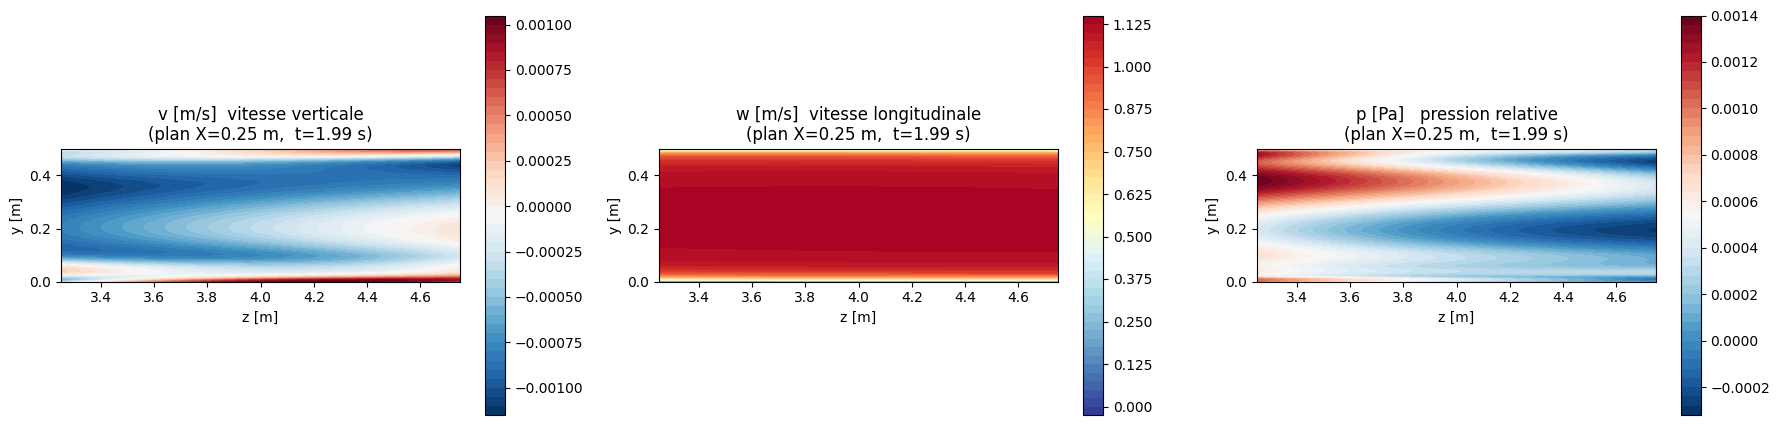

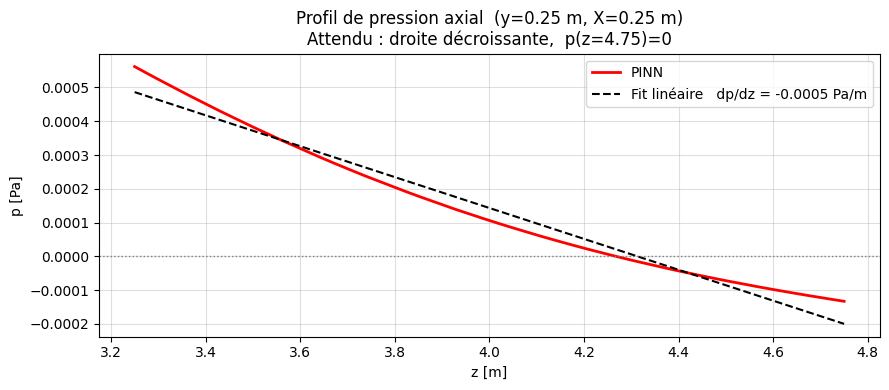

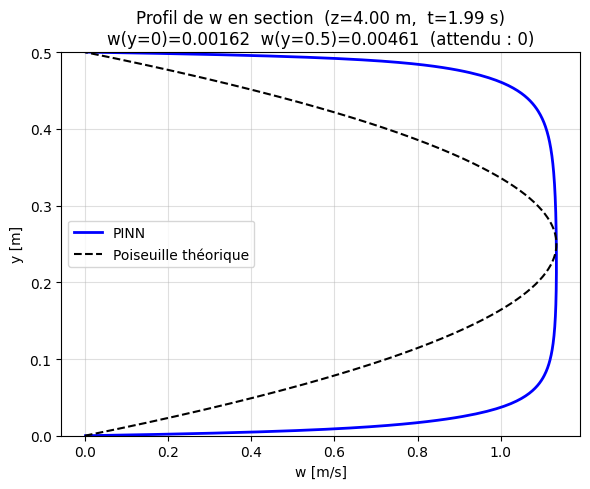

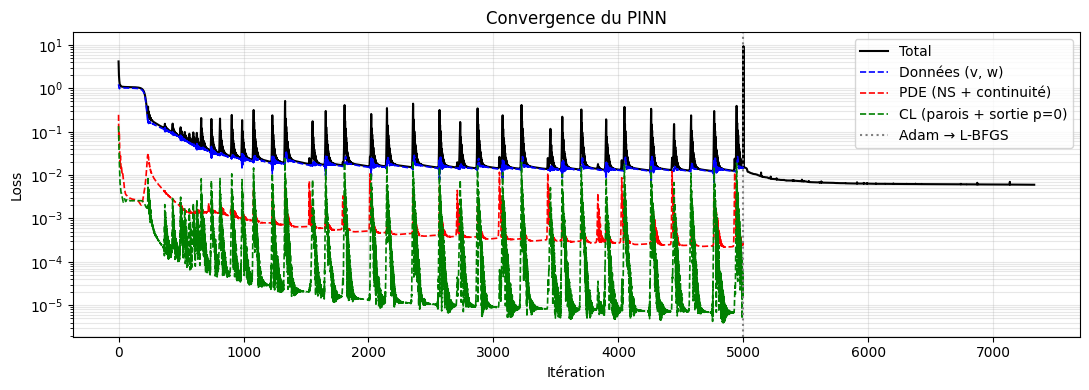


RÉCAPITULATIF
  λ1                 = 0.27587    (attendu 1.0)
  ν identifié        = 3.5947e-07 m²/s
  ν air 20°C         = 1.516e-05 m²/s
  dp/dz (fit)        = -0.00046 Pa/m  (doit être < 0)
  p(z=4.75, sortie)  = -0.00013 Pa   (attendu ≈ 0)
  w(y=0,   paroi)    = 0.00162 m/s  (attendu ≈ 0)
  w(y=0.5, paroi)    = 0.00461 m/s  (attendu ≈ 0)


In [62]:
# =============================================================================
# CELLULE 1 — Extraction de l'archive (à exécuter une seule fois)
# =============================================================================
# !mkdir -p /content/donnees_projet
# !7z x /content/ProjetIA.7z -o/content/donnees_projet/


# =============================================================================
# CELLULE 2 — Chargement et sauvegarde des données
# =============================================================================
import pandas as pd
import numpy as np
import glob
import os
import torch

DOSSIER   = '/content/donnees_projet/'
SAVE_PATH = '/content/dataset_pinn.pt'
DT        = 0.01   # pas de temps entre fichiers [s]

COL_Y = 'Y [ m ]'
COL_Z = 'Z [ m ]'
COL_V = 'Velocity v [ m s^-1 ]'
COL_W = 'Velocity w [ m s^-1 ]'
ALL_COLS = ['X [ m ]', COL_Y, COL_Z,
            'Velocity u [ m s^-1 ]', COL_V, COL_W]

liste = sorted(
    glob.glob(os.path.join(DOSSIER, 'Data_*.txt')),
    key=lambda p: int(os.path.basename(p).replace('Data_','').replace('.txt',''))
)
print(f"{len(liste)} fichiers trouvés.")

frames = []
for i, chemin in enumerate(liste):
    df = pd.read_csv(chemin, skiprows=5, header=None, names=ALL_COLS)
    for col in ALL_COLS:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df['t'] = i * DT
    frames.append(df)

df = pd.concat(frames, ignore_index=True)
df.dropna(subset=[COL_Y, COL_Z, COL_V, COL_W], inplace=True)
print(f"{len(df):,} points valides.")
print(f"Y ∈ [{df[COL_Y].min():.3f}, {df[COL_Y].max():.3f}]")
print(f"Z ∈ [{df[COL_Z].min():.3f}, {df[COL_Z].max():.3f}]")
print(f"t ∈ [{df['t'].min():.3f}, {df['t'].max():.3f}]")

torch.save({
    'y': torch.tensor(df[COL_Y].values[:,None], dtype=torch.float32),
    'z': torch.tensor(df[COL_Z].values[:,None], dtype=torch.float32),
    't': torch.tensor(df['t'].values[:,None],   dtype=torch.float32),
    'v': torch.tensor(df[COL_V].values[:,None], dtype=torch.float32),
    'w': torch.tensor(df[COL_W].values[:,None], dtype=torch.float32),
}, SAVE_PATH)
print(f"Sauvegardé : {SAVE_PATH}")


# =============================================================================
# CELLULE 3 — PINN complet
# =============================================================================
import torch
import torch.nn as nn
import torch.optim as optim
import torch.autograd as autograd
import matplotlib.pyplot as plt
import numpy as np
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

# ── Domaine physique (lu dans le mail) ────────────────────────────────────────
Y_MIN, Y_MAX = 0.0,  0.5    # hauteur conduite [m]
Z_MIN, Z_MAX = 3.25, 4.75   # portion longitudinale mesurée [m]

# ─────────────────────────────────────────────────────────────────────────────
# 1. CHARGEMENT
# ─────────────────────────────────────────────────────────────────────────────
data   = torch.load('/content/dataset_pinn.pt')
y_raw  = data['y'].numpy()   # (N,1)
z_raw  = data['z'].numpy()
t_raw  = data['t'].numpy()
v_raw  = data['v'].numpy()
w_raw  = data['w'].numpy()

T_MIN, T_MAX = float(t_raw.min()), float(t_raw.max())
print(f"N={y_raw.shape[0]:,}  t∈[{T_MIN:.3f},{T_MAX:.3f}]")

# ─────────────────────────────────────────────────────────────────────────────
# 2. NORMALISATION  →  [-1, 1]
#    Toutes les entrées du réseau seront normalisées.
#    Les sorties v, w, p restent en valeurs physiques.
# ─────────────────────────────────────────────────────────────────────────────
def norm(x, lo, hi):
    return 2.0*(x - lo)/(hi - lo) - 1.0

y_n = norm(y_raw, Y_MIN, Y_MAX)
z_n = norm(z_raw, Z_MIN, Z_MAX)
t_n = norm(t_raw, T_MIN, T_MAX)

# ─────────────────────────────────────────────────────────────────────────────
# 3. RÉSEAU DE NEURONES
#    Entrée  : (y, z, t) normalisés  →  3 neurones
#    Sortie  : (v, w, p)             →  3 neurones
#    Mêmes hyperparamètres que l'article Raissi (8 couches × 20)
# ─────────────────────────────────────────────────────────────────────────────
class PINN(nn.Module):
    """
    Prédit (v, w, p) depuis (y_norm, z_norm, t_norm).

    Deux paramètres scalaires appris en même temps :
      lambda_1  :  coefficient devant le terme convectif  (doit → 1)
      lambda_2  :  viscosité cinématique ν  [m²/s]        (doit → ~1.5e-5 pour l'air)
    """
    def __init__(self):
        super().__init__()
        # 8 couches cachées × 20 neurones, activation tanh (comme Raissi)
        sizes = [3, 20, 20, 20, 20, 20, 20, 20, 20, 3]
        layers = []
        for i in range(len(sizes)-2):
            layers += [nn.Linear(sizes[i], sizes[i+1]), nn.Tanh()]
        layers += [nn.Linear(sizes[-2], sizes[-1])]
        self.net = nn.Sequential(*layers)

        # Initialisation Xavier (stable pour tanh)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

        # Paramètres physiques à identifier — initialisés à 0 comme dans Raissi
        self.lambda_1 = nn.Parameter(torch.zeros(1))
        self.lambda_2 = nn.Parameter(torch.zeros(1))

    def forward(self, y, z, t):
        inp = torch.cat([y, z, t], dim=1)
        out = self.net(inp)
        v = out[:, 0:1]
        w = out[:, 1:2]
        p = out[:, 2:3]
        return v, w, p

# ─────────────────────────────────────────────────────────────────────────────
# 4. RÉSIDUS NAVIER-STOKES
#    Dans le plan médian X=0.25 m on a u≈0 et ∂/∂x≈0.
#    NS 2D instationnaire incompressible :
#
#      Continuité  :  ∂v/∂y + ∂w/∂z = 0
#
#      NS-y  :  ∂v/∂t + λ1(v·∂v/∂y + w·∂v/∂z) = -∂p/∂y + λ2(∂²v/∂y² + ∂²v/∂z²)
#      NS-z  :  ∂w/∂t + λ1(v·∂w/∂y + w·∂w/∂z) = -∂p/∂z + λ2(∂²w/∂y² + ∂²w/∂z²)
#
#    λ1 et λ2 sont les paramètres à identifier.
#    Attention : les dérivées sont calculées par rapport aux coordonnées
#    normalisées → on divise par le jacobien de la normalisation pour
#    retrouver les dérivées physiques.
#
#    dy_norm/dy = 2/(Y_MAX-Y_MIN),  dz_norm/dz = 2/(Z_MAX-Z_MIN),  etc.
# ─────────────────────────────────────────────────────────────────────────────
# Jacobiens (constantes)
Jy = 2.0 / (Y_MAX - Y_MIN)   # = 4.0
Jz = 2.0 / (Z_MAX - Z_MIN)   # ≈ 1.333
Jt = 2.0 / (T_MAX - T_MIN)

def G(f, x):
    """Dérivée automatique, graphe conservé."""
    return autograd.grad(f.sum(), x, create_graph=True)[0]

def pde_residuals(model, y_n, z_n, t_n):
    """
    Calcule les 3 résidus (continuité, NS-y, NS-z) en coordonnées physiques.
    Les entrées sont normalisées (grad auto en coordonnées normalisées),
    puis on repasse en physique via les jacobiens.
    """
    v, w, p = model(y_n, z_n, t_n)
    l1 = model.lambda_1
    l2 = model.lambda_2

    # Dérivées en coordonnées NORMALISÉES (ce que calcule autograd)
    v_yn = G(v, y_n);  v_zn = G(v, z_n);  v_tn = G(v, t_n)
    w_yn = G(w, y_n);  w_zn = G(w, z_n);  w_tn = G(w, t_n)
    p_yn = G(p, y_n);  p_zn = G(p, z_n)

    v_yynn = G(v_yn, y_n);  v_zznn = G(v_zn, z_n)
    w_yynn = G(w_yn, y_n);  w_zznn = G(w_zn, z_n)

    # Conversion en dérivées PHYSIQUES  (∂f/∂y = ∂f/∂y_n · Jy)
    v_y  = v_yn  * Jy;   v_z  = v_zn  * Jz;   v_t  = v_tn  * Jt
    w_y  = w_yn  * Jy;   w_z  = w_zn  * Jz;   w_t  = w_tn  * Jt
    p_y  = p_yn  * Jy;   p_z  = p_zn  * Jz

    v_yy = v_yynn * Jy**2;  v_zz = v_zznn * Jz**2
    w_yy = w_yynn * Jy**2;  w_zz = w_zznn * Jz**2

    # Résidus
    f_cont = v_y + w_z
    f_v    = v_t + l1*(v*v_y + w*v_z) + p_y - l2*(v_yy + v_zz)
    f_w    = w_t + l1*(v*w_y + w*w_z) + p_z - l2*(w_yy + w_zz)

    return f_cont, f_v, f_w

# ─────────────────────────────────────────────────────────────────────────────
# 5. LOSS TOTALE
#
#   Loss = w_dat * MSE(v,w données)
#        + w_pde * MSE(résidus NS)
#        + w_bc  * MSE(CL parois  : v=w=0 en y=0 et y=0.5)
#        + w_bc  * MSE(CL sortie  : p=0   en z=4.75)
#
#   Pourquoi ces CL ?
#     - Parois : condition no-slip physique. Les données CFD ont des valeurs
#       ~1e-5 aux parois (bruit numérique), pas exactement 0. Sans CL
#       explicite le réseau ne force pas v=w=0.
#     - Sortie p=0 : NS ne contraint que ∂p/∂z, pas la valeur absolue.
#       Sans ce point d'ancrage, p est reconstruit à une constante près.
# ─────────────────────────────────────────────────────────────────────────────
def compute_loss(model, batch, col, bc,
                 w_dat=1.0, w_pde=1.0, w_bc=20.0):

    # ── Données mesurées (v et w) ─────────────────────────────────────────
    vp, wp, _ = model(batch['y'], batch['z'], batch['t'])
    loss_dat  = ((batch['v'] - vp)**2).mean() + ((batch['w'] - wp)**2).mean()

    # ── Résidus PDE ───────────────────────────────────────────────────────
    fc, fv, fw = pde_residuals(model, col['y'], col['z'], col['t'])
    loss_pde   = (fc**2).mean() + (fv**2).mean() + (fw**2).mean()

    # ── CL parois (no-slip) : v=0 et w=0 en y=0 et y=Y_MAX ───────────────
    v_wall, w_wall, _ = model(bc['y_wall'], bc['z_wall'], bc['t_wall'])
    loss_wall = (v_wall**2) .mean() + (w_wall**2) .mean()

    # ── CL sortie : p=0 en z=Z_MAX ────────────────────────────────────────
    _, _, p_out = model(bc['y_out'], bc['z_out'], bc['t_out'])
    loss_pout  = (p_out**2) .mean()

    loss_bc = loss_wall + loss_pout
    total   = w_dat*loss_dat + w_pde*loss_pde + w_bc*loss_bc
    return total, loss_dat, loss_pde, loss_bc

# ─────────────────────────────────────────────────────────────────────────────
# 6. PRÉPARATION DES TENSEURS
# ─────────────────────────────────────────────────────────────────────────────
def T(arr, g=False):
    """numpy (N,1) → tenseur GPU float32."""
    return torch.tensor(arr, dtype=torch.float32,
                        requires_grad=g).to(device)

np.random.seed(42)
torch.manual_seed(42)

N_TRAIN  = 5000    # points de données pour l'entraînement
N_COLLOC = 10000   # points de collocation intérieur

# Échantillonnage aléatoire des données
idx = np.random.choice(y_raw.shape[0], min(N_TRAIN, y_raw.shape[0]), replace=False)
batch = {
    'y': T(y_n[idx],   True),
    'z': T(z_n[idx],   True),
    't': T(t_n[idx],   True),
    'v': T(v_raw[idx]),
    'w': T(w_raw[idx]),
}

# Points de collocation : distribution uniforme dans tout le domaine
col = {
    'y': T(norm(np.random.uniform(Y_MIN, Y_MAX, (N_COLLOC,1)), Y_MIN, Y_MAX), True),
    'z': T(norm(np.random.uniform(Z_MIN, Z_MAX, (N_COLLOC,1)), Z_MIN, Z_MAX), True),
    't': T(norm(np.random.uniform(T_MIN, T_MAX, (N_COLLOC,1)), T_MIN, T_MAX), True),
}

# Points de CL
N_WALL, N_OUT = 500, 300

def rnd(lo, hi, n): return np.random.uniform(lo, hi, (n,1))

# Paroi y=0
y_w0 = np.zeros((N_WALL,1))
z_w0 = rnd(Z_MIN, Z_MAX, N_WALL)
t_w0 = rnd(T_MIN, T_MAX, N_WALL)
# Paroi y=Y_MAX
y_w1 = np.full((N_WALL,1), Y_MAX)
z_w1 = rnd(Z_MIN, Z_MAX, N_WALL)
t_w1 = rnd(T_MIN, T_MAX, N_WALL)

y_wall_all = np.vstack([y_w0, y_w1])
z_wall_all = np.vstack([z_w0, z_w1])
t_wall_all = np.vstack([t_w0, t_w1])

# Sortie z=Z_MAX, p=0
y_out_arr = rnd(Y_MIN, Y_MAX, N_OUT)
z_out_arr = np.full((N_OUT,1), Z_MAX)
t_out_arr = rnd(T_MIN, T_MAX, N_OUT)

bc = {
    'y_wall': T(norm(y_wall_all, Y_MIN, Y_MAX), True),
    'z_wall': T(norm(z_wall_all, Z_MIN, Z_MAX), True),
    't_wall': T(norm(t_wall_all, T_MIN, T_MAX), True),
    'y_out':  T(norm(y_out_arr,  Y_MIN, Y_MAX), True),
    'z_out':  T(norm(z_out_arr,  Z_MIN, Z_MAX), True),
    't_out':  T(norm(t_out_arr,  T_MIN, T_MAX), True),
}

# ─────────────────────────────────────────────────────────────────────────────
# 7. ENTRAÎNEMENT
# ─────────────────────────────────────────────────────────────────────────────
model = PINN().to(device)
print(f"Paramètres réseau : {sum(p.numel() for p in model.parameters()):,}")

ADAM_ITERS  = 5000
LBFGS_ITERS = 50000
LOG         = 500

history = {k: [] for k in ['total','dat','pde','bc']}

# ── Phase 1 : Adam ────────────────────────────────────────────────────────────
print(f"\n{'='*60}\nAdam ({ADAM_ITERS} it.)\n{'='*60}")
opt_adam = optim.Adam(model.parameters(), lr=1e-3)
t0 = time.time()

for it in range(ADAM_ITERS):
    opt_adam.zero_grad()
    total, ld, lp, lb = compute_loss(model, batch, col, bc)
    total.backward()
    opt_adam.step()

    for k, v in zip(['total','dat','pde','bc'], [total,ld,lp,lb]):
        history[k].append(v.item())

    if it % LOG == 0:
        print(f"  {it:5d} | tot={total.item():.3e} dat={ld.item():.3e} "
              f"pde={lp.item():.3e} bc={lb.item():.3e} | "
              f"λ1={model.lambda_1.item():.4f} λ2={model.lambda_2.item():.3e} | "
              f"{time.time()-t0:.1f}s")
        t0 = time.time()

torch.save(model.state_dict(), '/content/pinn_adam.pt')
print("Checkpoint sauvegardé : /content/pinn_adam.pt")

# ── Phase 2 : L-BFGS ──────────────────────────────────────────────────────────
print(f"\n{'='*60}\nL-BFGS (max {LBFGS_ITERS} it.)\n{'='*60}")
opt_lb = optim.LBFGS(model.parameters(),
                     max_iter=LBFGS_ITERS,
                     tolerance_grad=1e-9, tolerance_change=1e-9,
                     history_size=50, line_search_fn="strong_wolfe")
cpt = [0]

def closure():
    opt_lb.zero_grad()
    total, ld, lp, lb = compute_loss(model, batch, col, bc)
    total.backward()
    history['total'].append(total.item())
    cpt[0] += 1
    if cpt[0] % 200 == 0:
        print(f"  {cpt[0]:5d} | tot={total.item():.3e} dat={ld.item():.3e} "
              f"pde={lp.item():.3e} bc={lb.item():.3e} | "
              f"λ1={model.lambda_1.item():.4f} λ2={model.lambda_2.item():.3e}")
    return total

opt_lb.step(closure)
torch.save(model.state_dict(), '/content/pinn_final.pt')
print("Modèle final sauvegardé : /content/pinn_final.pt")

# ─────────────────────────────────────────────────────────────────────────────
# 8. RÉSULTATS
# ─────────────────────────────────────────────────────────────────────────────
l1 = model.lambda_1.item()
l2 = model.lambda_2.item()

print(f"\n{'='*60}")
print("PARAMÈTRES IDENTIFIÉS")
print(f"{'='*60}")
print(f"  λ1 (terme convectif) = {l1:.6f}   ← attendu ≈ 1.0")
print(f"  λ2 = ν (viscosité)   = {l2:.4e} m²/s")
print(f"  Référence air 20°C   : ν = 1.516e-05 m²/s")
if l2 > 0:
    print(f"  Erreur relative      : {abs(l2-1.516e-5)/1.516e-5*100:.1f}%")

# ─────────────────────────────────────────────────────────────────────────────
# 9. VISUALISATION
# ─────────────────────────────────────────────────────────────────────────────
model.eval()

def predict(y_phys, z_phys, t_phys):
    """Prédit (v,w,p) depuis des tableaux en coordonnées physiques."""
    yn = T(norm(y_phys, Y_MIN, Y_MAX), True)
    zn = T(norm(z_phys, Z_MIN, Z_MAX), True)
    tn = T(norm(t_phys, T_MIN, T_MAX), True)
    with torch.no_grad():
        vp, wp, pp = model(yn, zn, tn)
    return (vp.cpu().numpy(), wp.cpu().numpy(), pp.cpu().numpy())

N_GRID = 100
yi     = np.linspace(Y_MIN, Y_MAX, N_GRID)
zi     = np.linspace(Z_MIN, Z_MAX, N_GRID)
Yi, Zi = np.meshgrid(yi, zi)          # (N_GRID, N_GRID)
t_last = np.full_like(Yi, T_MAX)

Vp, Wp, Pp = predict(Yi[:,:,None].reshape(-1,1),
                     Zi[:,:,None].reshape(-1,1),
                     t_last.reshape(-1,1))
Vp = Vp.reshape(N_GRID, N_GRID)
Wp = Wp.reshape(N_GRID, N_GRID)
Pp = Pp.reshape(N_GRID, N_GRID)

# ── Figure 1 : champs v, w, p dans le plan médian ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, field, title, cmap in zip(
        axes,
        [Vp, Wp, Pp],
        [f'v [m/s]  vitesse verticale',
         f'w [m/s]  vitesse longitudinale',
         f'p [Pa]   pression relative'],
        ['RdBu_r', 'RdYlBu_r', 'RdBu_r']):
    cf = ax.contourf(Zi, Yi, field, levels=50, cmap=cmap)
    plt.colorbar(cf, ax=ax, shrink=0.85)
    ax.set_xlabel('z [m]');  ax.set_ylabel('y [m]')
    ax.set_title(f'{title}\n(plan X=0.25 m,  t={T_MAX:.2f} s)')
    ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('/content/champs_plan_median.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2 : profil de pression axial (ligne y=0.25) ────────────────────
#    Physiquement attendu : droite décroissante, p=0 en z=4.75
zi_ax  = np.linspace(Z_MIN, Z_MAX, 300)
yc_ax  = np.full_like(zi_ax, 0.25)
tc_ax  = np.full_like(zi_ax, T_MAX)
_, _, p_ax = predict(yc_ax[:,None], zi_ax[:,None], tc_ax[:,None])
p_ax = p_ax.flatten()

# Fit linéaire → gradient de pression dp/dz
coef = np.polyfit(zi_ax, p_ax, 1)
p_fit = np.polyval(coef, zi_ax)

fig2, ax2 = plt.subplots(figsize=(9,4))
ax2.plot(zi_ax, p_ax,  'r-',  lw=2,   label='PINN')
ax2.plot(zi_ax, p_fit, 'k--', lw=1.5,
         label=f'Fit linéaire   dp/dz = {coef[0]:.4f} Pa/m')
ax2.axhline(0, color='gray', lw=1, linestyle=':')
ax2.set_xlabel('z [m]');  ax2.set_ylabel('p [Pa]')
ax2.set_title('Profil de pression axial  (y=0.25 m, X=0.25 m)\n'
              'Attendu : droite décroissante,  p(z=4.75)=0')
ax2.legend();  ax2.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('/content/profil_pression.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 3 : profil de w en section à mi-conduite ───────────────────────
#    Attendu : parabole, w=0 aux parois (y=0 et y=0.5)
z_mid  = (Z_MIN + Z_MAX) / 2.0
yi_s   = np.linspace(Y_MIN, Y_MAX, 300)
zc_s   = np.full_like(yi_s, z_mid)
tc_s   = np.full_like(yi_s, T_MAX)
_, w_s, _ = predict(yi_s[:,None], zc_s[:,None], tc_s[:,None])
w_s = w_s.flatten()

# Poiseuille théorique pour comparaison visuelle
w_max_pois = w_s.max()
w_pois = w_max_pois * 4 * yi_s*(Y_MAX - yi_s) / Y_MAX**2

fig3, ax3 = plt.subplots(figsize=(6,5))
ax3.plot(w_s,    yi_s, 'b-',  lw=2,   label='PINN')
ax3.plot(w_pois, yi_s, 'k--', lw=1.5, label='Poiseuille théorique')
ax3.set_xlabel('w [m/s]');  ax3.set_ylabel('y [m]')
ax3.set_title(f'Profil de w en section  (z={z_mid:.2f} m,  t={T_MAX:.2f} s)\n'
              f'w(y=0)={w_s[0]:.5f}  w(y=0.5)={w_s[-1]:.5f}  (attendu : 0)')
ax3.legend();  ax3.grid(True, alpha=0.4);  ax3.set_ylim([Y_MIN, Y_MAX])
plt.tight_layout()
plt.savefig('/content/profil_w_section.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 4 : courbes de convergence ─────────────────────────────────────
fig4, ax4 = plt.subplots(figsize=(11,4))
ax4.semilogy(history['total'], 'k-',  lw=1.5, label='Total')
ax4.semilogy(history['dat'],   'b--', lw=1.2, label='Données (v, w)')
ax4.semilogy(history['pde'],   'r--', lw=1.2, label='PDE (NS + continuité)')
ax4.semilogy(history['bc'],    'g--', lw=1.2, label='CL (parois + sortie p=0)')
ax4.axvline(ADAM_ITERS, color='gray', linestyle=':', lw=1.5, label='Adam → L-BFGS')
ax4.set_xlabel('Itération');  ax4.set_ylabel('Loss')
ax4.set_title('Convergence du PINN')
ax4.legend();  ax4.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/convergence.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Récapitulatif ──────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("RÉCAPITULATIF")
print(f"{'='*60}")
print(f"  λ1                 = {l1:.5f}    (attendu 1.0)")
print(f"  ν identifié        = {l2:.4e} m²/s")
print(f"  ν air 20°C         = 1.516e-05 m²/s")
print(f"  dp/dz (fit)        = {coef[0]:.5f} Pa/m  (doit être < 0)")
print(f"  p(z=4.75, sortie)  = {p_ax[-1]:.5f} Pa   (attendu ≈ 0)")
print(f"  w(y=0,   paroi)    = {w_s[0]:.5f} m/s  (attendu ≈ 0)")
print(f"  w(y=0.5, paroi)    = {w_s[-1]:.5f} m/s  (attendu ≈ 0)")

## 6e essai avec Normalisation

Device : cuda
N=1,000,000  t∈[0.000,1.990]
v ∈ [-0.0020, 0.0020] m/s
w ∈ [0.2657, 1.1502] m/s

Facteurs de normalisation des sorties :
  V_STD = 1.0832e-03 m/s
  W_STD = 1.7694e-01 m/s
  P_REF = 1.7694e-01 Pa

Paramètres réseau : 3,085

Adam (5000 it.)
      0 | tot=3.728e+01 dat=3.689e+01 pde=2.493e-01 bc=1.345e-01 | λ1=0.0010 λ2=-1.000e-03 | 0.2s
    500 | tot=4.905e-01 dat=3.711e-01 pde=1.097e-02 bc=1.085e-01 | λ1=0.0077 λ2=3.871e-06 | 26.7s
   1000 | tot=1.548e+00 dat=1.322e-01 pde=8.838e-01 bc=5.324e-01 | λ1=0.0098 λ2=-6.037e-05 | 25.5s
   1500 | tot=3.467e-01 dat=2.760e-01 pde=1.012e-02 bc=6.055e-02 | λ1=0.0251 λ2=-2.556e-06 | 25.6s
   2000 | tot=2.358e-01 dat=2.115e-01 pde=9.219e-03 bc=1.507e-02 | λ1=-0.0237 λ2=1.979e-07 | 26.1s
   2500 | tot=2.644e-01 dat=2.402e-01 pde=9.492e-03 bc=1.470e-02 | λ1=0.0121 λ2=5.003e-07 | 25.5s
   3000 | tot=2.331e-01 dat=2.119e-01 pde=1.928e-02 bc=1.971e-03 | λ1=0.0322 λ2=1.639e-05 | 26.6s
   3500 | tot=2.074e-01 dat=1.855e-01 pde=8.300e-03 bc=1.3

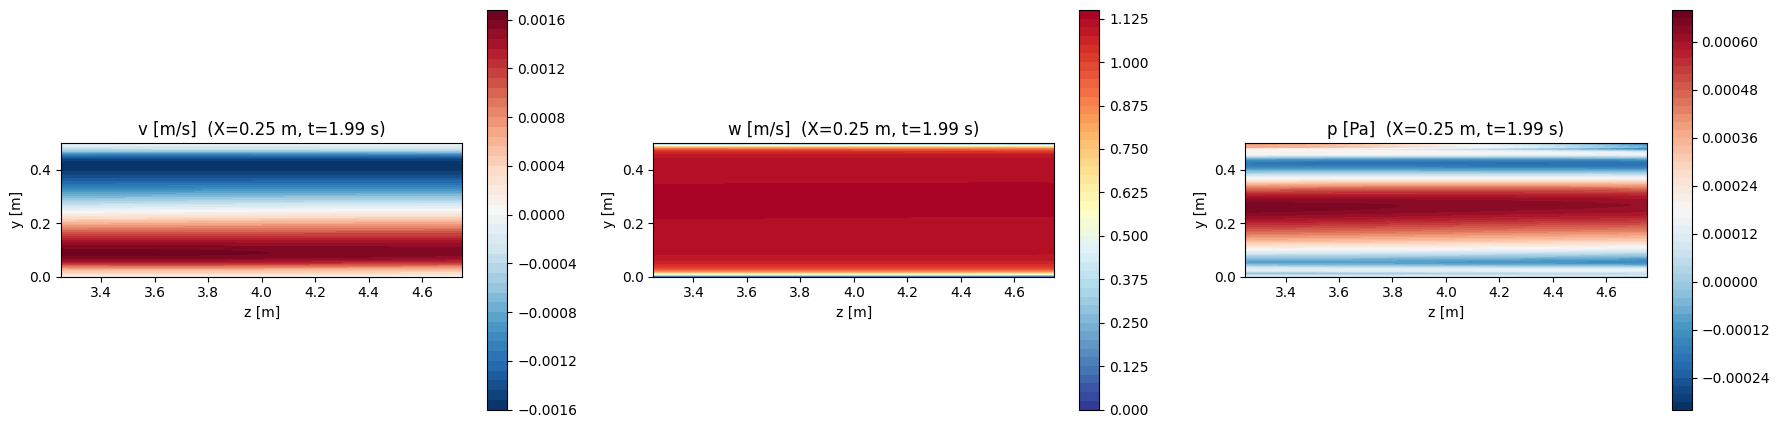

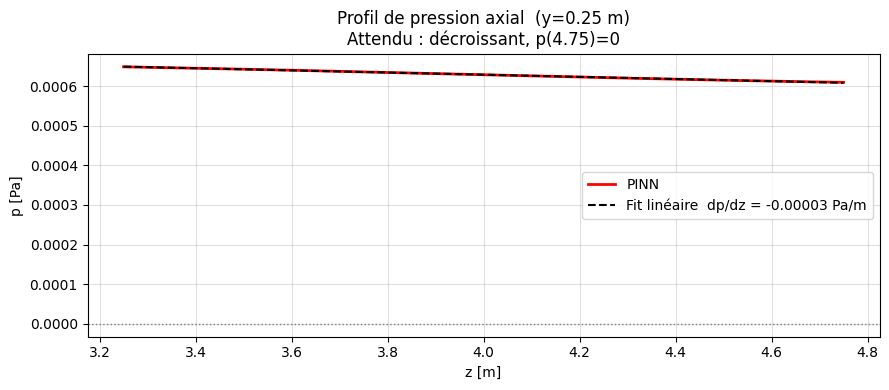

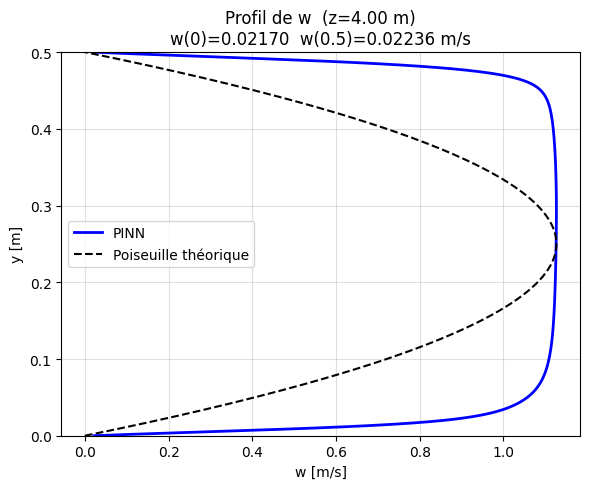

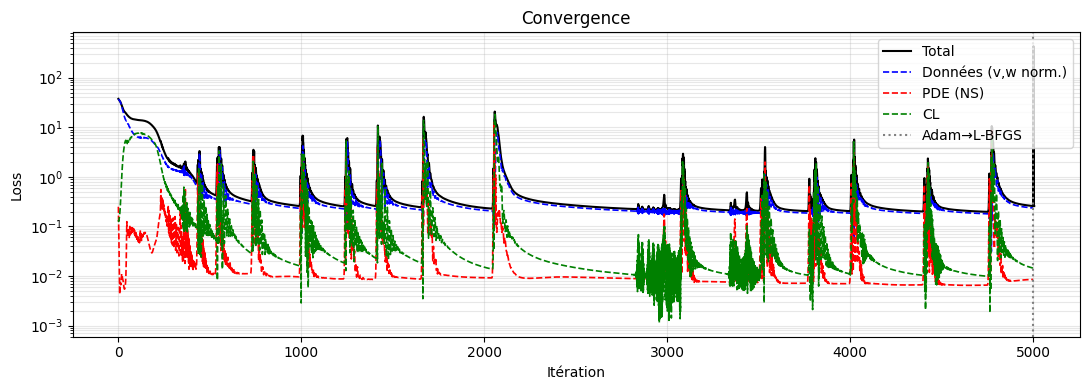


RÉCAPITULATIF
  λ1                 = 0.14217   (attendu 1.0)
  ν identifié        = -6.3354e-07 m²/s
  ν air 20°C         = 1.516e-05 m²/s
  dp/dz              = -0.00003 Pa/m  (doit être < 0)
  p(z=4.75)          = 0.00061 Pa   (attendu ≈ 0)
  w(y=0)             = 0.02170 m/s  (attendu ≈ 0)
  w(y=0.5)           = 0.02236 m/s  (attendu ≈ 0)


In [63]:
# =============================================================================
# PINN — Plan médian  (Y, Z, t) → (v, w, p)   VERSION ÉQUILIBRÉE
#
# Corrections par rapport à la version précédente :
#   1. Normalisation des SORTIES : v, w, p ramenés à l'ordre 1
#      avant d'entrer dans la loss (évite que w~1 m/s domine v~1e-3 m/s)
#   2. Pondérations équilibrées : w_dat=1, w_pde=1, w_bc=1
#      (w_bc=20 écrasait le fit des données)
#   3. lambda_1 et lambda_2 initialisés à des valeurs proches du physique
# =============================================================================

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.autograd as autograd
import matplotlib.pyplot as plt
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

# ── Domaine physique ───────────────────────────────────────────────────────────
Y_MIN, Y_MAX = 0.0,  0.5
Z_MIN, Z_MAX = 3.25, 4.75

# =============================================================================
# 1. CHARGEMENT
# =============================================================================
data  = torch.load('/content/dataset_pinn.pt')
y_raw = data['y'].numpy()
z_raw = data['z'].numpy()
t_raw = data['t'].numpy()
v_raw = data['v'].numpy()
w_raw = data['w'].numpy()

T_MIN, T_MAX = float(t_raw.min()), float(t_raw.max())
print(f"N={y_raw.shape[0]:,}  t∈[{T_MIN:.3f},{T_MAX:.3f}]")
print(f"v ∈ [{v_raw.min():.4f}, {v_raw.max():.4f}] m/s")
print(f"w ∈ [{w_raw.min():.4f}, {w_raw.max():.4f}] m/s")

# =============================================================================
# 2. NORMALISATION DES ENTRÉES  →  [-1, 1]
# =============================================================================
def norm(x, lo, hi):
    return 2.0*(x - lo)/(hi - lo) - 1.0

y_n = norm(y_raw, Y_MIN, Y_MAX)
z_n = norm(z_raw, Z_MIN, Z_MAX)
t_n = norm(t_raw, T_MIN, T_MAX)

# =============================================================================
# 3. NORMALISATION DES SORTIES
#    v et w ont des ordres de grandeur très différents (~1e-3 vs ~1 m/s).
#    On divise chaque sortie par son écart-type pour les ramener à l'ordre 1.
#    Le réseau apprend v/v_std, w/w_std, p/p_ref.
#    On dénormalise uniquement pour l'affichage et le calcul des résidus.
# =============================================================================
V_STD = float(np.std(v_raw)) if np.std(v_raw) > 1e-10 else 1.0
W_STD = float(np.std(w_raw)) if np.std(w_raw) > 1e-10 else 1.0
P_REF = W_STD   # ordre de grandeur de la pression (même ordre que w²~ρ)

print(f"\nFacteurs de normalisation des sorties :")
print(f"  V_STD = {V_STD:.4e} m/s")
print(f"  W_STD = {W_STD:.4e} m/s")
print(f"  P_REF = {P_REF:.4e} Pa")

# =============================================================================
# 4. RÉSEAU DE NEURONES
#    Entrée  : (y_n, z_n, t_n)  normalisées dans [-1,1]
#    Sortie  : (v̂, ŵ, p̂) = (v/V_STD, w/W_STD, p/P_REF)  → ordre 1
# =============================================================================
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        sizes = [3, 20, 20, 20, 20, 20, 20, 20, 20, 3]
        layers = []
        for i in range(len(sizes)-2):
            layers += [nn.Linear(sizes[i], sizes[i+1]), nn.Tanh()]
        layers += [nn.Linear(sizes[-2], sizes[-1])]
        self.net = nn.Sequential(*layers)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

        # Initialisations proches du physique pour aider la convergence
        self.lambda_1 = nn.Parameter(torch.tensor([0.0]))   # → 1.0
        self.lambda_2 = nn.Parameter(torch.tensor([0.0]))   # → log(ν)

    def forward(self, y, z, t):
        out = self.net(torch.cat([y, z, t], dim=1))
        v_hat = out[:, 0:1]   # v / V_STD
        w_hat = out[:, 1:2]   # w / W_STD
        p_hat = out[:, 2:3]   # p / P_REF
        return v_hat, w_hat, p_hat

    def get_physical(self, y, z, t):
        """Retourne v, w, p en unités physiques."""
        v_hat, w_hat, p_hat = self.forward(y, z, t)
        return v_hat * V_STD, w_hat * W_STD, p_hat * P_REF

# =============================================================================
# 5. RÉSIDUS NAVIER-STOKES (coordonnées physiques via jacobiens)
# =============================================================================
Jy = 2.0 / (Y_MAX - Y_MIN)
Jz = 2.0 / (Z_MAX - Z_MIN)
Jt = 2.0 / (T_MAX - T_MIN)

def G(f, x):
    return autograd.grad(f.sum(), x, create_graph=True)[0]

def pde_residuals(model, y_n, z_n, t_n):
    """
    Calcule les résidus en unités physiques.
    Le réseau sort des valeurs normalisées → on dénormalise avant d'écrire NS.
    """
    v_hat, w_hat, p_hat = model(y_n, z_n, t_n)

    # Dénormalisation pour les résidus physiques
    v = v_hat * V_STD
    w = w_hat * W_STD
    p = p_hat * P_REF

    l1 = model.lambda_1
    l2 = model.lambda_2

    # Dérivées en coords normalisées puis conversion physique
    v_yn = G(v, y_n);  v_zn = G(v, z_n);  v_tn = G(v, t_n)
    w_yn = G(w, y_n);  w_zn = G(w, z_n);  w_tn = G(w, t_n)
    p_yn = G(p, y_n);  p_zn = G(p, z_n)

    v_yynn = G(v_yn, y_n);  v_zznn = G(v_zn, z_n)
    w_yynn = G(w_yn, y_n);  w_zznn = G(w_zn, z_n)

    v_y = v_yn*Jy;  v_z = v_zn*Jz;  v_t = v_tn*Jt
    w_y = w_yn*Jy;  w_z = w_zn*Jz;  w_t = w_tn*Jt
    p_y = p_yn*Jy;  p_z = p_zn*Jz

    v_yy = v_yynn*Jy**2;  v_zz = v_zznn*Jz**2
    w_yy = w_yynn*Jy**2;  w_zz = w_zznn*Jz**2

    f_cont = v_y + w_z
    f_v    = v_t + l1*(v*v_y + w*v_z) + p_y - l2*(v_yy + v_zz)
    f_w    = w_t + l1*(v*w_y + w*w_z) + p_z - l2*(w_yy + w_zz)

    return f_cont, f_v, f_w

# =============================================================================
# 6. LOSS  —  tout en unités NORMALISÉES pour équilibrer les termes
#
#   Loss_données  : erreur sur v̂ = v/V_STD  et  ŵ = w/W_STD  (ordre ~1)
#   Loss_PDE      : résidus NS normalisés par W_STD/T  (ordre ~1)
#   Loss_CL       : même normalisation que données
#
#   Pondérations ÉGALES (1,1,1) — on laisse la physique équilibrer
# =============================================================================
def compute_loss(model, batch, col, bc,
                 w_dat=1.0, w_pde=1.0, w_bc=1.0):

    # ── Données : erreur sur les sorties normalisées ───────────────────────
    v_hat, w_hat, _ = model(batch['y'], batch['z'], batch['t'])
    loss_dat = ((batch['v_n'] - v_hat)**2).mean() + \
               ((batch['w_n'] - w_hat)**2).mean()

    # ── Résidus PDE (physiques, normalisés par W_STD pour ordre ~1) ───────
    fc, fv, fw = pde_residuals(model, col['y'], col['z'], col['t'])
    # Normalisation des résidus pour les rendre comparables à loss_dat
    loss_pde = ((fc/W_STD)**2).mean() + \
               ((fv/W_STD)**2).mean() + \
               ((fw/W_STD)**2).mean()

    # ── CL parois : v̂=0 et ŵ=0 en y=0 et y=Y_MAX ─────────────────────────
    v_w, w_w, _ = model(bc['y_wall'], bc['z_wall'], bc['t_wall'])
    loss_wall = (v_w**2).mean() + (w_w**2).mean()

    # ── CL sortie : p̂=0 en z=Z_MAX ──────────────────────────────────────
    _, _, p_out = model(bc['y_out'], bc['z_out'], bc['t_out'])
    loss_pout = (p_out**2).mean()

    loss_bc = loss_wall + loss_pout
    total   = w_dat*loss_dat + w_pde*loss_pde + w_bc*loss_bc
    return total, loss_dat, loss_pde, loss_bc

# =============================================================================
# 7. TENSEURS D'ENTRAÎNEMENT
# =============================================================================
def T(arr, g=False):
    return torch.tensor(arr, dtype=torch.float32,
                        requires_grad=g).to(device)

np.random.seed(42);  torch.manual_seed(42)

N_TRAIN  = 5000
N_COLLOC = 10000

idx = np.random.choice(y_raw.shape[0], min(N_TRAIN, y_raw.shape[0]), replace=False)
batch = {
    'y':   T(y_n[idx],            True),
    'z':   T(z_n[idx],            True),
    't':   T(t_n[idx],            True),
    'v_n': T(v_raw[idx] / V_STD),        # cible normalisée
    'w_n': T(w_raw[idx] / W_STD),
}

col = {
    'y': T(norm(np.random.uniform(Y_MIN, Y_MAX, (N_COLLOC,1)), Y_MIN, Y_MAX), True),
    'z': T(norm(np.random.uniform(Z_MIN, Z_MAX, (N_COLLOC,1)), Z_MIN, Z_MAX), True),
    't': T(norm(np.random.uniform(T_MIN, T_MAX, (N_COLLOC,1)), T_MIN, T_MAX), True),
}

N_WALL, N_OUT = 500, 300
def rnd(lo, hi, n): return np.random.uniform(lo, hi, (n,1))

y_wall = np.vstack([np.zeros((N_WALL,1)), np.full((N_WALL,1), Y_MAX)])
z_wall = np.vstack([rnd(Z_MIN, Z_MAX, N_WALL), rnd(Z_MIN, Z_MAX, N_WALL)])
t_wall = np.vstack([rnd(T_MIN, T_MAX, N_WALL), rnd(T_MIN, T_MAX, N_WALL)])

bc = {
    'y_wall': T(norm(y_wall, Y_MIN, Y_MAX), True),
    'z_wall': T(norm(z_wall, Z_MIN, Z_MAX), True),
    't_wall': T(norm(t_wall, T_MIN, T_MAX), True),
    'y_out':  T(norm(rnd(Y_MIN, Y_MAX, N_OUT), Y_MIN, Y_MAX), True),
    'z_out':  T(norm(np.full((N_OUT,1), Z_MAX), Z_MIN, Z_MAX), True),
    't_out':  T(norm(rnd(T_MIN, T_MAX, N_OUT), T_MIN, T_MAX), True),
}

# =============================================================================
# 8. ENTRAÎNEMENT
# =============================================================================
model = PINN().to(device)
print(f"\nParamètres réseau : {sum(p.numel() for p in model.parameters()):,}")

ADAM_ITERS  = 5000
LBFGS_ITERS = 50000
LOG         = 500

history = {k: [] for k in ['total','dat','pde','bc']}

# ── Adam ──────────────────────────────────────────────────────────────────────
print(f"\n{'='*60}\nAdam ({ADAM_ITERS} it.)\n{'='*60}")
opt_adam = optim.Adam(model.parameters(), lr=1e-3)
t0 = time.time()

for it in range(ADAM_ITERS):
    opt_adam.zero_grad()
    total, ld, lp, lb = compute_loss(model, batch, col, bc)
    total.backward()
    opt_adam.step()

    for k, val in zip(['total','dat','pde','bc'], [total,ld,lp,lb]):
        history[k].append(val.item())

    if it % LOG == 0:
        print(f"  {it:5d} | tot={total.item():.3e} dat={ld.item():.3e} "
              f"pde={lp.item():.3e} bc={lb.item():.3e} | "
              f"λ1={model.lambda_1.item():.4f} λ2={model.lambda_2.item():.3e} | "
              f"{time.time()-t0:.1f}s")
        t0 = time.time()

torch.save(model.state_dict(), '/content/pinn_adam.pt')

# ── L-BFGS ────────────────────────────────────────────────────────────────────
print(f"\n{'='*60}\nL-BFGS\n{'='*60}")
opt_lb = optim.LBFGS(model.parameters(),
                     max_iter=LBFGS_ITERS,
                     tolerance_grad=1e-9, tolerance_change=1e-9,
                     history_size=50, line_search_fn="strong_wolfe")
cpt = [0]

def closure():
    opt_lb.zero_grad()
    total, ld, lp, lb = compute_loss(model, batch, col, bc)
    total.backward()
    history['total'].append(total.item())
    cpt[0] += 1
    if cpt[0] % 200 == 0:
        print(f"  {cpt[0]:5d} | tot={total.item():.3e} dat={ld.item():.3e} "
              f"pde={lp.item():.3e} bc={lb.item():.3e} | "
              f"λ1={model.lambda_1.item():.4f} λ2={model.lambda_2.item():.3e}")
    return total

opt_lb.step(closure)
torch.save(model.state_dict(), '/content/pinn_final.pt')

# =============================================================================
# 9. RÉSULTATS
# =============================================================================
l1 = model.lambda_1.item()
l2 = model.lambda_2.item()

print(f"\n{'='*60}\nPARAMÈTRES IDENTIFIÉS\n{'='*60}")
print(f"  λ1                 = {l1:.6f}   (attendu ≈ 1.0)")
print(f"  λ2 = ν             = {l2:.4e} m²/s")
print(f"  ν air 20°C         = 1.516e-05 m²/s")
if l2 > 0:
    print(f"  Erreur relative    = {abs(l2-1.516e-5)/1.516e-5*100:.1f}%")

# =============================================================================
# 10. VISUALISATION
# =============================================================================
model.eval()

def predict_phys(y_phys, z_phys, t_phys):
    yn = T(norm(y_phys, Y_MIN, Y_MAX), True)
    zn = T(norm(z_phys, Z_MIN, Z_MAX), True)
    tn = T(norm(t_phys, T_MIN, T_MAX), True)
    with torch.no_grad():
        vp, wp, pp = model.get_physical(yn, zn, tn)
    return vp.cpu().numpy(), wp.cpu().numpy(), pp.cpu().numpy()

N_GRID = 100
yi = np.linspace(Y_MIN, Y_MAX, N_GRID)
zi = np.linspace(Z_MIN, Z_MAX, N_GRID)
Yi, Zi = np.meshgrid(yi, zi)
t_last = np.full_like(Yi, T_MAX)

Vp, Wp, Pp = predict_phys(Yi.reshape(-1,1), Zi.reshape(-1,1), t_last.reshape(-1,1))
Vp = Vp.reshape(N_GRID, N_GRID)
Wp = Wp.reshape(N_GRID, N_GRID)
Pp = Pp.reshape(N_GRID, N_GRID)

# Figure 1 : champs
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, field, title, cmap in zip(
        axes, [Vp, Wp, Pp],
        ['v [m/s]', 'w [m/s]', 'p [Pa]'],
        ['RdBu_r', 'RdYlBu_r', 'RdBu_r']):
    cf = ax.contourf(Zi, Yi, field, levels=50, cmap=cmap)
    plt.colorbar(cf, ax=ax, shrink=0.85)
    ax.set_xlabel('z [m]'); ax.set_ylabel('y [m]')
    ax.set_title(f'{title}  (X=0.25 m, t={T_MAX:.2f} s)')
    ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('/content/champs_plan_median.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 2 : profil de pression axial
zi_ax = np.linspace(Z_MIN, Z_MAX, 300)
_, _, p_ax = predict_phys(np.full((300,1), 0.25), zi_ax[:,None], np.full((300,1), T_MAX))
p_ax = p_ax.flatten()
coef = np.polyfit(zi_ax, p_ax, 1)

fig2, ax2 = plt.subplots(figsize=(9,4))
ax2.plot(zi_ax, p_ax, 'r-', lw=2, label='PINN')
ax2.plot(zi_ax, np.polyval(coef, zi_ax), 'k--', lw=1.5,
         label=f'Fit linéaire  dp/dz = {coef[0]:.5f} Pa/m')
ax2.axhline(0, color='gray', lw=1, ls=':')
ax2.set_xlabel('z [m]'); ax2.set_ylabel('p [Pa]')
ax2.set_title('Profil de pression axial  (y=0.25 m)\nAttendu : décroissant, p(4.75)=0')
ax2.legend(); ax2.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('/content/profil_pression.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 3 : profil w en section
z_mid = (Z_MIN + Z_MAX) / 2.0
yi_s  = np.linspace(Y_MIN, Y_MAX, 300)
_, w_s, _ = predict_phys(yi_s[:,None], np.full((300,1), z_mid), np.full((300,1), T_MAX))
w_s = w_s.flatten()
w_pois = w_s.max() * 4*yi_s*(Y_MAX-yi_s)/Y_MAX**2

fig3, ax3 = plt.subplots(figsize=(6,5))
ax3.plot(w_s,    yi_s, 'b-',  lw=2,   label='PINN')
ax3.plot(w_pois, yi_s, 'k--', lw=1.5, label='Poiseuille théorique')
ax3.set_xlabel('w [m/s]'); ax3.set_ylabel('y [m]')
ax3.set_title(f'Profil de w  (z={z_mid:.2f} m)\n'
              f'w(0)={w_s[0]:.5f}  w(0.5)={w_s[-1]:.5f} m/s')
ax3.legend(); ax3.grid(True, alpha=0.4); ax3.set_ylim([Y_MIN, Y_MAX])
plt.tight_layout()
plt.savefig('/content/profil_w_section.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 4 : convergence
fig4, ax4 = plt.subplots(figsize=(11,4))
ax4.semilogy(history['total'], 'k-',  lw=1.5, label='Total')
ax4.semilogy(history['dat'],   'b--', lw=1.2, label='Données (v,w norm.)')
ax4.semilogy(history['pde'],   'r--', lw=1.2, label='PDE (NS)')
ax4.semilogy(history['bc'],    'g--', lw=1.2, label='CL')
ax4.axvline(ADAM_ITERS, color='gray', ls=':', lw=1.5, label='Adam→L-BFGS')
ax4.set_xlabel('Itération'); ax4.set_ylabel('Loss')
ax4.set_title('Convergence'); ax4.legend(); ax4.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/convergence.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*60}\nRÉCAPITULATIF\n{'='*60}")
print(f"  λ1                 = {l1:.5f}   (attendu 1.0)")
print(f"  ν identifié        = {l2:.4e} m²/s")
print(f"  ν air 20°C         = 1.516e-05 m²/s")
print(f"  dp/dz              = {coef[0]:.5f} Pa/m  (doit être < 0)")
print(f"  p(z=4.75)          = {p_ax[-1]:.5f} Pa   (attendu ≈ 0)")
print(f"  w(y=0)             = {w_s[0]:.5f} m/s  (attendu ≈ 0)")
print(f"  w(y=0.5)           = {w_s[-1]:.5f} m/s  (attendu ≈ 0)")

## 7e essai : on force λ_2 à être positif  & Points de collocation et CL fixes, on les fixe avant l'entrainement

de plus le code affiche maintenant W_SCALE, V_SCALE et la valeur initiale de λ2 pour vérifier que les ordres de grandeur sont cohérents avant même de commencer l'entraînement.

In [ ]:
# =============================================================================
# PINN — Plan médian  (Y, Z, t) → (v, w, p)   VERSION STABLE
#
# Corrections fondamentales :
#   1. λ2 = exp(log_λ2) → toujours positif (viscosité physique)
#   2. Points de collocation et CL FIXES (pas de re-tirage aléatoire)
#   3. Normalisation cohérente : résidus PDE ramenés à l'ordre de loss_dat
#   4. Diagnostic détaillé pour comprendre ce qui se passe
# =============================================================================

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.autograd as autograd
import matplotlib.pyplot as plt
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

Y_MIN, Y_MAX = 0.0,  0.5
Z_MIN, Z_MAX = 3.25, 4.75

# =============================================================================
# 1. CHARGEMENT
# =============================================================================
data  = torch.load('/content/dataset_pinn.pt')
y_raw = data['y'].numpy()
z_raw = data['z'].numpy()
t_raw = data['t'].numpy()
v_raw = data['v'].numpy()
w_raw = data['w'].numpy()

T_MIN, T_MAX = float(t_raw.min()), float(t_raw.max())

print(f"N={y_raw.shape[0]:,}")
print(f"v ∈ [{v_raw.min():.4e}, {v_raw.max():.4e}] m/s   std={np.std(v_raw):.4e}")
print(f"w ∈ [{w_raw.min():.4e}, {w_raw.max():.4e}] m/s   std={np.std(w_raw):.4e}")
print(f"t ∈ [{T_MIN:.3f}, {T_MAX:.3f}] s")

# =============================================================================
# 2. NORMALISATION
# =============================================================================
def norm(x, lo, hi):
    return 2.0*(x - lo)/(hi - lo) - 1.0

y_n = norm(y_raw, Y_MIN, Y_MAX)
z_n = norm(z_raw, Z_MIN, Z_MAX)
t_n = norm(t_raw, T_MIN, T_MAX)

# Échelles caractéristiques des sorties
W_SCALE = float(np.std(w_raw))   # échelle de w  (~0.2 m/s typiquement)
V_SCALE = float(np.std(v_raw))   # échelle de v
if V_SCALE < 1e-10: V_SCALE = W_SCALE * 0.01

print(f"\nÉchelles : W_SCALE={W_SCALE:.4e}  V_SCALE={V_SCALE:.4e}")

# Jacobiens pour la conversion dérivées normalisées → physiques
Jy = 2.0 / (Y_MAX - Y_MIN)   # 4.0
Jz = 2.0 / (Z_MAX - Z_MIN)   # ~1.33
Jt = 2.0 / (T_MAX - T_MIN)

# =============================================================================
# 3. RÉSEAU
#    Sortie : (v/W_SCALE,  w/W_SCALE,  p/W_SCALE²)  → ordre 1
#    λ1  : paramètre libre  (→ 1.0)
#    λ2  : exp(log_λ2) pour garantir λ2 > 0  (→ ~1.5e-5)
# =============================================================================
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        sizes = [3, 20, 20, 20, 20, 20, 20, 20, 20, 3]
        layers = []
        for i in range(len(sizes)-2):
            layers += [nn.Linear(sizes[i], sizes[i+1]), nn.Tanh()]
        layers += [nn.Linear(sizes[-2], sizes[-1])]
        self.net = nn.Sequential(*layers)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

        # λ1 : direct (peut être positif ou négatif initialement)
        self.lambda_1 = nn.Parameter(torch.tensor([0.0]))

        # λ2 = exp(log_λ2) → TOUJOURS POSITIF
        # Initialisation : log(1e-4) ≈ -9.2  (ordre de grandeur raisonnable)
        self.log_lambda_2 = nn.Parameter(torch.tensor([-9.2]))

    @property
    def lambda_2(self):
        """Viscosité cinématique : toujours > 0."""
        return torch.exp(self.log_lambda_2)

    def forward(self, y, z, t):
        out = self.net(torch.cat([y, z, t], dim=1))
        return out[:, 0:1], out[:, 1:2], out[:, 2:3]  # v̂, ŵ, p̂

    def get_physical(self, y, z, t):
        v_hat, w_hat, p_hat = self.forward(y, z, t)
        v = v_hat * V_SCALE
        w = w_hat * W_SCALE
        p = p_hat * W_SCALE**2
        return v, w, p

# =============================================================================
# 4. RÉSIDUS PDE
# =============================================================================
def G(f, x):
    return autograd.grad(f.sum(), x, create_graph=True)[0]

def pde_residuals(model, y_n, z_n, t_n):
    v_hat, w_hat, p_hat = model(y_n, z_n, t_n)

    # Grandeurs physiques
    v = v_hat * V_SCALE
    w = w_hat * W_SCALE
    p = p_hat * W_SCALE**2

    l1 = model.lambda_1
    l2 = model.lambda_2   # toujours > 0 grâce à exp()

    # Dérivées en coords normalisées
    v_yn=G(v,y_n); v_zn=G(v,z_n); v_tn=G(v,t_n)
    w_yn=G(w,y_n); w_zn=G(w,z_n); w_tn=G(w,t_n)
    p_yn=G(p,y_n); p_zn=G(p,z_n)
    v_yy=G(v_yn,y_n); v_zz=G(v_zn,z_n)
    w_yy=G(w_yn,y_n); w_zz=G(w_zn,z_n)

    # Conversion physique
    v_y=v_yn*Jy; v_z=v_zn*Jz; v_t=v_tn*Jt
    w_y=w_yn*Jy; w_z=w_zn*Jz; w_t=w_tn*Jt
    p_y=p_yn*Jy; p_z=p_zn*Jz
    v_yy=v_yy*Jy**2; v_zz=v_zz*Jz**2
    w_yy=w_yy*Jy**2; w_zz=w_zz*Jz**2

    f_cont = v_y + w_z
    f_v    = v_t + l1*(v*v_y + w*v_z) + p_y - l2*(v_yy + v_zz)
    f_w    = w_t + l1*(v*w_y + w*w_z) + p_z - l2*(w_yy + w_zz)

    return f_cont, f_v, f_w

# =============================================================================
# 5. LOSS
# =============================================================================
def compute_loss(model, batch, col, bc, w_dat=1.0, w_pde=1.0, w_bc=1.0):

    # Données (sorties normalisées)
    v_hat, w_hat, _ = model(batch['y'], batch['z'], batch['t'])
    loss_dat = ((batch['v_n'] - v_hat)**2).mean() + \
               ((batch['w_n'] - w_hat)**2).mean()

    # PDE — normalisés par W_SCALE pour être comparables à loss_dat
    fc, fv, fw = pde_residuals(model, col['y'], col['z'], col['t'])
    loss_pde = ((fc / W_SCALE)**2).mean() + \
               ((fv / W_SCALE)**2).mean() + \
               ((fw / W_SCALE)**2).mean()

    # CL parois : ŵ=0, v̂=0
    v_w, w_w, _ = model(bc['y_wall'], bc['z_wall'], bc['t_wall'])
    loss_wall = (v_w**2).mean() + (w_w**2).mean()

    # CL sortie : p̂=0
    _, _, p_out = model(bc['y_out'], bc['z_out'], bc['t_out'])
    loss_pout = (p_out**2).mean()

    loss_bc = loss_wall + loss_pout
    total   = w_dat*loss_dat + w_pde*loss_pde + w_bc*loss_bc
    return total, loss_dat, loss_pde, loss_bc

# =============================================================================
# 6. PRÉPARATION DES TENSEURS (UNE SEULE FOIS — fixes pendant tout l'entraînement)
# =============================================================================
def T(arr, g=False):
    return torch.tensor(arr, dtype=torch.float32, requires_grad=g).to(device)

np.random.seed(42); torch.manual_seed(42)

N_TRAIN  = 5000
N_COLLOC = 10000
N_WALL   = 500
N_OUT    = 300

# Données
idx = np.random.choice(y_raw.shape[0], min(N_TRAIN, y_raw.shape[0]), replace=False)
batch = {
    'y':   T(y_n[idx],              True),
    'z':   T(z_n[idx],              True),
    't':   T(t_n[idx],              True),
    'v_n': T(v_raw[idx] / V_SCALE),
    'w_n': T(w_raw[idx] / W_SCALE),
}

# Collocation — FIXE
col = {
    'y': T(norm(np.random.uniform(Y_MIN, Y_MAX, (N_COLLOC,1)), Y_MIN, Y_MAX), True),
    'z': T(norm(np.random.uniform(Z_MIN, Z_MAX, (N_COLLOC,1)), Z_MIN, Z_MAX), True),
    't': T(norm(np.random.uniform(T_MIN, T_MAX, (N_COLLOC,1)), T_MIN, T_MAX), True),
}

# CL — FIXES
def rnd(lo, hi, n): return np.random.uniform(lo, hi, (n,1))

y_wall = np.vstack([np.zeros((N_WALL,1)), np.full((N_WALL,1), Y_MAX)])
z_wall = np.vstack([rnd(Z_MIN, Z_MAX, N_WALL), rnd(Z_MIN, Z_MAX, N_WALL)])
t_wall = np.vstack([rnd(T_MIN, T_MAX, N_WALL), rnd(T_MIN, T_MAX, N_WALL)])

bc = {
    'y_wall': T(norm(y_wall, Y_MIN, Y_MAX), True),
    'z_wall': T(norm(z_wall, Z_MIN, Z_MAX), True),
    't_wall': T(norm(t_wall, T_MIN, T_MAX), True),
    'y_out':  T(norm(rnd(Y_MIN, Y_MAX, N_OUT), Y_MIN, Y_MAX), True),
    'z_out':  T(norm(np.full((N_OUT,1), Z_MAX), Z_MIN, Z_MAX), True),
    't_out':  T(norm(rnd(T_MIN, T_MAX, N_OUT), T_MIN, T_MAX), True),
}

print(f"\nTenseurs préparés et FIXES pour tout l'entraînement.")
print(f"  batch     : {N_TRAIN} points")
print(f"  colloc    : {N_COLLOC} points")
print(f"  parois    : {2*N_WALL} points")
print(f"  sortie    : {N_OUT} points")

# =============================================================================
# 7. ENTRAÎNEMENT
# =============================================================================
model = PINN().to(device)
n_p = sum(p.numel() for p in model.parameters())
print(f"\nParamètres réseau : {n_p:,}")
print(f"λ2 initial = exp({model.log_lambda_2.item():.2f}) = {model.lambda_2.item():.3e} m²/s")

ADAM_ITERS  = 5000
LBFGS_ITERS = 50000
LOG         = 500

history = {k: [] for k in ['total','dat','pde','bc']}

# ── Adam ──────────────────────────────────────────────────────────────────────
print(f"\n{'='*65}\nAdam ({ADAM_ITERS} it.)\n{'='*65}")
opt_adam = optim.Adam(model.parameters(), lr=1e-3)
t0 = time.time()

for it in range(ADAM_ITERS):
    opt_adam.zero_grad()
    total, ld, lp, lb = compute_loss(model, batch, col, bc)
    total.backward()
    opt_adam.step()

    for k, val in zip(['total','dat','pde','bc'], [total,ld,lp,lb]):
        history[k].append(val.item())

    if it % LOG == 0:
        l2_val = model.lambda_2.item()
        print(f"  {it:5d} | tot={total.item():.3e} dat={ld.item():.3e} "
              f"pde={lp.item():.3e} bc={lb.item():.3e} | "
              f"λ1={model.lambda_1.item():.4f}  λ2={l2_val:.3e} | "
              f"{time.time()-t0:.1f}s")
        t0 = time.time()

torch.save(model.state_dict(), '/content/pinn_adam.pt')
print(f"\nCheckpoint Adam sauvegardé.")
print(f"λ1={model.lambda_1.item():.5f}  λ2={model.lambda_2.item():.4e} m²/s")

# ── L-BFGS ────────────────────────────────────────────────────────────────────
print(f"\n{'='*65}\nL-BFGS\n{'='*65}")
opt_lb = optim.LBFGS(model.parameters(),
                     max_iter=LBFGS_ITERS,
                     tolerance_grad=1e-9, tolerance_change=1e-9,
                     history_size=50, line_search_fn="strong_wolfe")
cpt = [0]

def closure():
    opt_lb.zero_grad()
    total, ld, lp, lb = compute_loss(model, batch, col, bc)
    total.backward()
    history['total'].append(total.item())
    cpt[0] += 1
    if cpt[0] % 200 == 0:
        print(f"  {cpt[0]:5d} | tot={total.item():.3e} dat={ld.item():.3e} "
              f"pde={lp.item():.3e} bc={lb.item():.3e} | "
              f"λ1={model.lambda_1.item():.4f}  λ2={model.lambda_2.item():.3e}")
    return total

opt_lb.step(closure)
torch.save(model.state_dict(), '/content/pinn_final.pt')

# =============================================================================
# 8. RÉSULTATS
# =============================================================================
l1   = model.lambda_1.item()
l2   = model.lambda_2.item()
nu_air = 1.516e-5

print(f"\n{'='*65}\nPARAMÈTRES IDENTIFIÉS\n{'='*65}")
print(f"  λ1           = {l1:.6f}   (attendu ≈ 1.0)")
print(f"  λ2 = ν       = {l2:.4e} m²/s   (toujours > 0 ✓)")
print(f"  ν air 20°C   = {nu_air:.3e} m²/s")
if l2 > 0:
    err = abs(l2 - nu_air) / nu_air * 100
    print(f"  Erreur rel.  = {err:.1f}%")

# =============================================================================
# 9. VISUALISATION
# =============================================================================
model.eval()

def predict_phys(y_phys, z_phys, t_phys):
    yn = T(norm(np.atleast_2d(y_phys).reshape(-1,1), Y_MIN, Y_MAX), True)
    zn = T(norm(np.atleast_2d(z_phys).reshape(-1,1), Z_MIN, Z_MAX), True)
    tn = T(norm(np.atleast_2d(t_phys).reshape(-1,1), T_MIN, T_MAX), True)
    with torch.no_grad():
        vp, wp, pp = model.get_physical(yn, zn, tn)
    return vp.cpu().numpy().flatten(), wp.cpu().numpy().flatten(), pp.cpu().numpy().flatten()

N_GRID = 100
yi = np.linspace(Y_MIN, Y_MAX, N_GRID)
zi = np.linspace(Z_MIN, Z_MAX, N_GRID)
Yi, Zi = np.meshgrid(yi, zi)

Vp, Wp, Pp = predict_phys(Yi.flatten(), Zi.flatten(), np.full(N_GRID**2, T_MAX))
Vp = Vp.reshape(N_GRID, N_GRID)
Wp = Wp.reshape(N_GRID, N_GRID)
Pp = Pp.reshape(N_GRID, N_GRID)

# Figure 1 : champs v, w, p
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, field, title, cmap in zip(
        axes, [Vp, Wp, Pp],
        ['v [m/s]', 'w [m/s]', 'p [Pa]'],
        ['RdBu_r', 'RdYlBu_r', 'RdBu_r']):
    cf = ax.contourf(Zi, Yi, field, levels=50, cmap=cmap)
    plt.colorbar(cf, ax=ax, shrink=0.85)
    ax.set_xlabel('z [m]'); ax.set_ylabel('y [m]')
    ax.set_title(f'{title}  (X=0.25 m, t={T_MAX:.2f} s)')
    ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('/content/champs_plan_median.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 2 : profil de pression axial
zi_ax = np.linspace(Z_MIN, Z_MAX, 300)
_, _, p_ax = predict_phys(np.full(300, 0.25), zi_ax, np.full(300, T_MAX))
coef = np.polyfit(zi_ax, p_ax, 1)

fig2, ax2 = plt.subplots(figsize=(9, 4))
ax2.plot(zi_ax, p_ax, 'r-', lw=2, label='PINN')
ax2.plot(zi_ax, np.polyval(coef, zi_ax), 'k--', lw=1.5,
         label=f'Fit linéaire  dp/dz = {coef[0]:.5f} Pa/m')
ax2.axhline(0, color='gray', lw=1, ls=':')
ax2.set_xlabel('z [m]'); ax2.set_ylabel('p [Pa]')
ax2.set_title('Profil de pression axial  (y=0.25 m)\nAttendu : décroissant, p(4.75)≈0')
ax2.legend(); ax2.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('/content/profil_pression.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 3 : profil de w en section
z_mid = (Z_MIN + Z_MAX) / 2.0
yi_s  = np.linspace(Y_MIN, Y_MAX, 300)
_, w_s, _ = predict_phys(yi_s, np.full(300, z_mid), np.full(300, T_MAX))
w_pois = w_s.max() * 4*yi_s*(Y_MAX - yi_s) / Y_MAX**2

fig3, ax3 = plt.subplots(figsize=(6, 5))
ax3.plot(w_s,    yi_s, 'b-',  lw=2,   label='PINN')
ax3.plot(w_pois, yi_s, 'k--', lw=1.5, label='Poiseuille théorique')
ax3.set_xlabel('w [m/s]'); ax3.set_ylabel('y [m]')
ax3.set_title(f'Profil de w  (z={z_mid:.2f} m)\n'
              f'w(0)={w_s[0]:.5f}  w(0.5)={w_s[-1]:.5f} m/s')
ax3.legend(); ax3.grid(True, alpha=0.4); ax3.set_ylim([Y_MIN, Y_MAX])
plt.tight_layout()
plt.savefig('/content/profil_w_section.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 4 : convergence
fig4, ax4 = plt.subplots(figsize=(11, 4))
ax4.semilogy(history['total'], 'k-',  lw=1.5, label='Total')
ax4.semilogy(history['dat'],   'b--', lw=1.2, label='Données (v,w)')
ax4.semilogy(history['pde'],   'r--', lw=1.2, label='PDE (NS)')
ax4.semilogy(history['bc'],    'g--', lw=1.2, label='CL (parois+sortie)')
ax4.axvline(ADAM_ITERS, color='gray', ls=':', lw=1.5, label='Adam→L-BFGS')
ax4.set_xlabel('Itération'); ax4.set_ylabel('Loss')
ax4.set_title('Convergence'); ax4.legend(); ax4.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/convergence.png', dpi=150, bbox_inches='tight')
plt.show()

# Récapitulatif
print(f"\n{'='*65}\nRÉCAPITULATIF\n{'='*65}")
print(f"  λ1             = {l1:.5f}    (attendu 1.0)")
print(f"  ν identifié    = {l2:.4e} m²/s")
print(f"  ν air 20°C     = {nu_air:.4e} m²/s")
if l2 > 0:
    print(f"  Erreur rel.    = {abs(l2-nu_air)/nu_air*100:.1f}%")
print(f"  dp/dz          = {coef[0]:.5f} Pa/m   (< 0 ✓ si négatif)")
print(f"  p(z=4.75)      = {p_ax[-1]:.5f} Pa    (attendu ≈ 0)")
print(f"  w(y=0)         = {w_s[0]:.5f} m/s   (attendu 0)")
print(f"  w(y=0.5)       = {w_s[-1]:.5f} m/s   (attendu 0)")

Device : cuda
N=1,000,000
v ∈ [-2.0321e-03, 2.0033e-03] m/s   std=1.0832e-03
w ∈ [2.6573e-01, 1.1502e+00] m/s   std=1.7694e-01
t ∈ [0.000, 1.990] s

Échelles : W_SCALE=1.7694e-01  V_SCALE=1.0832e-03

Tenseurs préparés et FIXES pour tout l'entraînement.
  batch     : 5000 points
  colloc    : 10000 points
  parois    : 1000 points
  sortie    : 300 points

Paramètres réseau : 3,085
λ2 initial = exp(-9.20) = 1.010e-04 m²/s

Adam (5000 it.)
      0 | tot=3.724e+01 dat=3.689e+01 pde=2.076e-01 bc=1.345e-01 | λ1=-0.0010  λ2=1.009e-04 | 0.2s
    500 | tot=4.953e-01 dat=3.958e-01 pde=5.826e-02 bc=4.122e-02 | λ1=-0.0482  λ2=4.898e-05 | 28.5s
   1000 | tot=2.686e-01 dat=2.153e-01 pde=3.525e-02 bc=1.803e-02 | λ1=-0.1613  λ2=3.104e-05 | 28.3s
   1500 | tot=2.283e-01 dat=1.775e-01 pde=2.385e-02 bc=2.694e-02 | λ1=-0.1932  λ2=2.305e-05 | 25.9s
   2000 | tot=2.134e-01 dat=1.724e-01 pde=1.918e-02 bc=2.185e-02 | λ1=-0.1855  λ2=1.770e-05 | 25.5s
   2500 | tot=1.982e-01 dat=1.564e-01 pde=1.384e-02 bc=2.79